In [2604]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLagRegression_strategy.backtest_class import BacktestLL
from Strategies.LeadLagRegression_strategy.strategy_class import StrategyLL, VolumeClass
tol=(1e-1)/2

In [2605]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2606]:
import warnings
warnings.filterwarnings('ignore')

In [2607]:
#5	17	0.1	1.00	-0.75	

In [2608]:
#1.2	60	0.3	0.6	1.0	-1.0	

In [2609]:
#0.200	0.200	120	0.5	0.6	2.0	-1.0

In [2610]:
MACD_long_threshold = 0.075
MACD_short_threshold = -0.050
price_diff_long_threshold = 0.150
price_diff_short_threshold = -0.100

combined_long_threshold = 0.275
combined_short_threshold = 0.275

combined_mode=True

burnout_period=60
stop_profit = 0.3
makeagg_ratio = 0.6
trail_stop=0

take_profit=2
stop_loss=-1


br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

# OOT part - Jan, Feb 

## Data preparation

In [2611]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_jan_feb.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_jan_feb.csv',
                    parse_dates=['datetime']).reset_index()

In [2612]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [2613]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [2614]:
#data_lag=data_lag.drop(index=177223).reset_index()
#del data_lag['level_0']

In [2615]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
55,55,2024-01-02 09:00:16.470627785,78.01,1.0,78.01,79.50,78.755,-1.0,106.470628
56,56,2024-01-02 09:00:18.000000000,NaN,NaN,78.03,79.49,78.760,NaN,1.529372
57,57,2024-01-02 09:00:21.000000000,NaN,NaN,78.04,79.49,78.765,NaN,3.000000
58,58,2024-01-02 09:00:24.000000000,NaN,NaN,78.05,79.49,78.770,NaN,3.000000
59,59,2024-01-02 09:00:26.000000000,NaN,NaN,78.05,79.24,78.645,NaN,2.000000


In [2616]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
1,1,2024-01-02 09:00:00.907744884,91.97,2.0,91.97,92.50,92.235,0
2,2,2024-01-02 09:00:40.962116718,92.00,3.0,91.96,92.49,92.225,0
3,3,2024-01-02 09:00:41.104269743,91.97,1.0,91.96,92.49,92.225,0
4,4,2024-01-02 09:00:41.159442425,92.00,1.0,91.96,92.49,92.225,0
5,5,2024-01-02 09:00:50.746176004,91.96,3.0,91.96,92.00,91.980,0


## Parameters and calculations

In [2617]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [2618]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

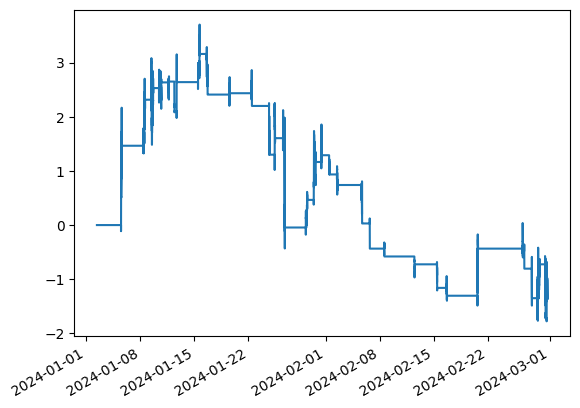

In [2619]:
xx.plot()

In [2620]:
#df[0:50]

In [2621]:
xx[-1:]

2024-02-29 17:59:46.962404490   -1.355
dtype: float64

# OOT part - Mar,Apr

## Data preparation

In [2622]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_mar_apr.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_mar_apr.csv',
                    parse_dates=['datetime']).reset_index()

In [2623]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [2624]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [2625]:
#data_lag=data_lag.drop(index=177223).reset_index()
#del data_lag['level_0']

In [2626]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
729,729,2024-03-01 09:00:00,NaN,NaN,56.25,56.70,56.475,NaN,1.0
730,730,2024-03-01 09:00:01,NaN,NaN,56.23,56.70,56.465,NaN,1.0
731,731,2024-03-01 09:00:03,NaN,NaN,56.23,56.55,56.390,NaN,2.0
732,732,2024-03-01 09:00:05,NaN,NaN,56.37,56.55,56.460,NaN,2.0
733,733,2024-03-01 09:00:06,NaN,NaN,56.49,56.55,56.520,NaN,1.0


In [2627]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
15,15,2024-03-01 09:00:09.338750124,56.41,2.0,56.41,56.61,56.510,0
16,16,2024-03-01 09:03:07.821218967,56.65,1.0,56.47,56.65,56.560,1
17,17,2024-03-01 09:03:07.821283579,56.70,5.0,56.47,56.65,56.560,1
18,18,2024-03-01 09:03:08.110189915,56.73,1.0,56.49,56.65,56.570,1
19,19,2024-03-01 09:03:14.834126711,56.90,1.0,56.72,56.89,56.805,1


## Parameters and calculations

In [2628]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [2629]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])
# df['price_level']=df['price_level']-df['position']*br_fee

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

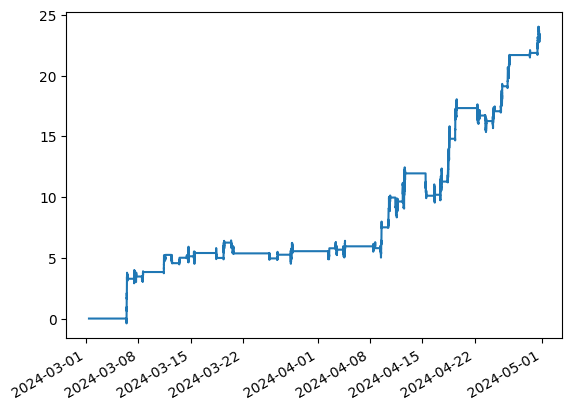

In [2630]:
xx.plot()

In [2631]:
#df[0:50]

In [2632]:
xx[-1:]

2024-04-30 17:59:58    23.305
dtype: float64

# OOT part - May, Jun

## Data preparation

In [2633]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_may_june.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_may_june.csv',
                    parse_dates=['datetime']).reset_index()

In [2634]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [2635]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [2636]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [2637]:
#data_lag=data_lag.drop(index=49887).reset_index()
#del data_lag['level_0']

In [2638]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
0,0,2024-05-01 09:29:25,NaN,NaN,NaN,73.0,73.0,1,0.0
1,1,2024-05-01 09:29:26,NaN,NaN,NaN,73.0,73.0,1,1.0
2,2,2024-05-01 09:29:27,NaN,NaN,NaN,73.0,73.0,1,1.0
3,3,2024-05-01 09:29:28,NaN,NaN,NaN,73.0,73.0,1,1.0
4,4,2024-05-01 09:29:29,NaN,NaN,NaN,73.0,73.0,1,1.0


In [2639]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
35,35,2024-05-02 09:02:02.465197325,65.81,2.0,65.81,66.15,65.980,0
36,36,2024-05-02 09:03:31.473956823,66.00,1.0,65.75,65.99,65.870,1
37,37,2024-05-02 09:03:31.575801849,66.00,1.0,65.75,65.99,65.870,1
38,38,2024-05-02 09:03:32.014014244,65.99,1.0,65.75,65.99,65.870,1
39,39,2024-05-02 09:04:00.009787560,65.99,1.0,65.76,65.95,65.855,1


## Parameters and calculations

In [2640]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [2641]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

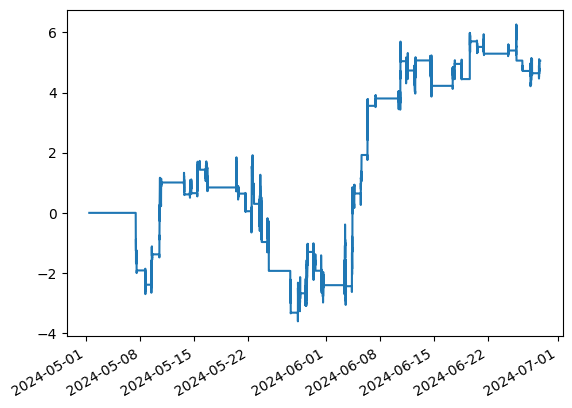

In [2642]:
xx.plot()

In [2643]:
#df[0:50]

In [2644]:
xx[-1:]

2024-06-28 17:59:46    5.06
dtype: float64

# OOT part - July, Aug

## Data preparation

In [2645]:
data_lead =pd.concat([pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_july.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_aug.csv',
                    parse_dates=['datetime']).reset_index()])

data_lag=pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_july_aug.csv',
                    parse_dates=['datetime']).reset_index()

In [2646]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [2647]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [2648]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [2649]:
#data_lag=data_lag.drop(index=177223).reset_index()
#del data_lag['level_0']

In [2650]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
614,614,2024-07-01 09:00:08,NaN,NaN,94.15,94.92,94.535,NaN,13.0
615,615,2024-07-01 09:00:15,NaN,NaN,94.15,94.97,94.560,NaN,7.0
616,616,2024-07-01 09:00:42,NaN,NaN,94.15,94.85,94.500,NaN,27.0
617,617,2024-07-01 09:00:43,NaN,NaN,94.15,94.80,94.475,NaN,1.0
618,618,2024-07-01 09:00:44,NaN,NaN,94.21,94.75,94.480,NaN,1.0


In [2651]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
123,123,2024-07-01 09:00:05.687479496,77.78,1.0,76.90,77.78,77.34,1.0
124,124,2024-07-01 09:00:10.607145071,77.78,1.0,77.00,77.78,77.39,1.0
125,125,2024-07-01 09:00:21.248078108,77.87,8.0,77.17,77.87,77.52,1.0
126,126,2024-07-01 09:01:07.907927752,77.93,6.0,77.51,77.93,77.72,1.0
127,127,2024-07-01 09:01:07.907927752,77.95,1.0,77.51,77.93,77.72,1.0


## Parameters and calculations

In [2652]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [2653]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

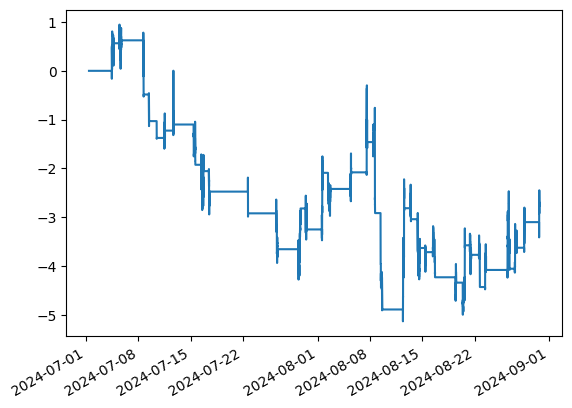

In [2654]:
xx.plot()

In [2655]:
#df[0:50]

In [2656]:
xx[-1:]

2024-08-30 17:59:50.029918909   -2.715
dtype: float64

# OOT part - Sep, Oct

## Data preparation

In [2657]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_sep_oct.csv',
                    parse_dates=['datetime']).reset_index()

data_lag=pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_sep_oct.csv',
                    parse_dates=['datetime']).reset_index()

In [2658]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [2659]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [2660]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [2661]:
#data_lag=data_lag.drop(index=177223).reset_index()
#del data_lag['level_0']

In [2662]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
639,639,2024-09-02 09:00:00,NaN,NaN,97.11,97.47,97.290,NaN,4.0
640,640,2024-09-02 09:00:01,NaN,NaN,97.12,97.47,97.295,NaN,1.0
641,641,2024-09-02 09:00:03,NaN,NaN,97.14,97.47,97.305,NaN,2.0
642,642,2024-09-02 09:00:04,NaN,NaN,97.09,97.45,97.270,NaN,1.0
643,643,2024-09-02 09:00:05,NaN,NaN,97.09,97.30,97.195,NaN,1.0


In [2663]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
356,356,2024-09-02 09:00:00.374863148,91.10,1.0,91.01,91.09,91.050,1.0
357,357,2024-09-02 09:00:00.396098137,91.10,2.0,91.01,91.09,91.050,1.0
358,358,2024-09-02 09:00:00.475012779,91.09,1.0,91.01,91.09,91.050,1.0
359,359,2024-09-02 09:00:00.475463152,91.10,2.0,91.01,91.09,91.050,1.0
360,360,2024-09-02 09:01:00.238040686,91.10,1.0,91.01,91.10,91.055,1.0


## Parameters and calculations

In [2664]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [2665]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

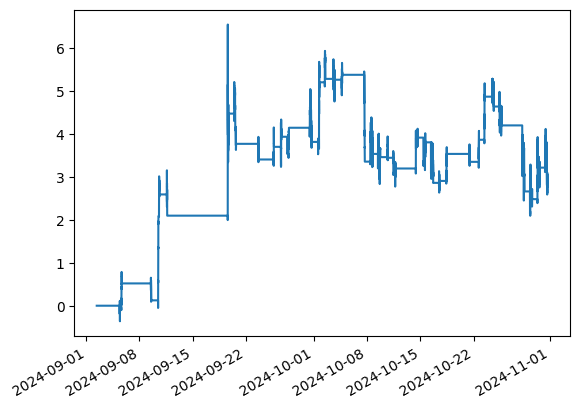

In [2666]:
xx.plot()

In [2667]:
#df[0:50]

In [2668]:
xx[-1:]

2024-10-31 17:59:58    2.785
dtype: float64

# Production check

## Data preparation

In [2669]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_production_sample.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_production_sample.csv',
                    parse_dates=['datetime']).reset_index()

In [2670]:
data_lead['datetime'] = pd.to_datetime(data_lead['datetime'], errors='coerce')
data_lag['datetime'] = pd.to_datetime(data_lag['datetime'], errors='coerce')

In [2671]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [2672]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [2673]:
# data_lag=data_lag.drop(index=177223).reset_index()
# del data_lag['level_0']

In [2674]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
717,717,2024-10-25 09:00:09.000000000,NaN,NaN,91.00,91.15,91.075,NaN,27.827928
718,718,2024-10-25 09:00:09.934926987,91.23,1.0,91.00,91.15,91.075,1.0,0.934927
719,719,2024-10-25 09:00:24.000000000,NaN,NaN,91.11,91.15,91.130,NaN,14.065073
720,720,2024-10-25 09:00:41.311402082,91.22,1.0,91.11,91.15,91.130,1.0,17.311402
721,721,2024-10-25 09:00:42.338101149,91.22,1.0,91.11,91.15,91.130,1.0,1.026699


In [2675]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
188,188,2024-10-25 09:00:47.387298822,97.06,1.0,96.88,97.06,96.970,1.0
189,189,2024-10-25 09:01:05.780653238,97.20,1.0,96.96,97.21,97.085,1.0
190,190,2024-10-25 09:01:06.691666842,97.21,1.0,96.96,97.20,97.080,1.0
191,191,2024-10-25 09:01:07.572153330,97.22,1.0,96.96,97.22,97.090,1.0
192,192,2024-10-25 09:01:08.770913124,97.22,1.0,96.96,97.28,97.120,1.0


## Parameters and calculations

In [2676]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [2677]:
from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
import pandas as pd

# As

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
df['price_level']=df['price_level']-df['position']*br_fee

# Create ColumnDataSources
source_df = ColumnDataSource(df)
source_lead = ColumnDataSource(data_lead)
source_lag = ColumnDataSource(data_lag)

# Create a figure with dynamic sizing
p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# Adjust y-axes ranges
p.extra_y_ranges = {
   "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
   "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
}

# Add left and right y-axes
p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# Plotting with hover tools
lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# Define hover tools for each glyph
hover_position = HoverTool(renderers=[position_circles], tooltips=[
    ("Timestamp", "@timestamp{%F %T}"),
    ("Price Level", "@price_level"),
    ("Position", "@position"),
    ("Color", "@color"),
], formatters={'@timestamp': 'datetime'})

hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lead Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lag Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

# Add hover tools to the plot
p.add_tools(hover_position, hover_lead, hover_lag)

# Customize plot
p.legend.location = "top_left"
p.xaxis.axis_label = "Datetime"
p.yaxis.axis_label = "Price Level"

# Show the plot
show(p)

<Axes: >

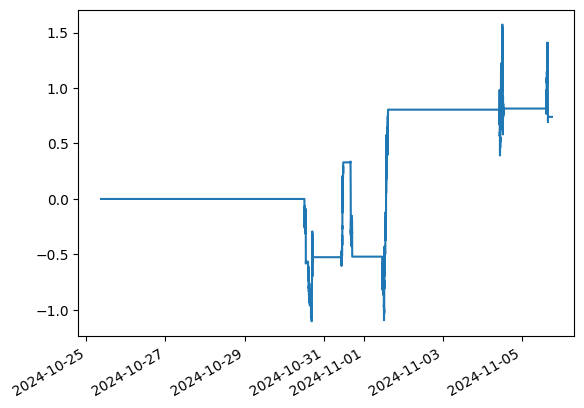

In [2678]:
xx.plot()

In [2679]:
#df[0:50]

In [2680]:
xx[-1:]

2024-11-05 17:59:59    0.74
dtype: float64

In [2681]:
# xx

In [2682]:

# xx1.reset_index()

In [2683]:
# start_time = '2024-06-20 10:27:04'
# end_time = '2024-06-20 10:27:09'

# a=df_ba_data1.reset_index()

# a[(a['timestamp'] >= start_time) & (a['timestamp'] <= end_time)]

In [2684]:
# df=data_class.get_orders_data(mkt, tenor, venue_list, start_date1,
#                                           bT, eT, prod, start_date2)

In [2685]:
# start_time = '2024-06-19 16:52:00'
# end_time = '2024-06-19 16:54:00'

# a=df.reset_index()

# type(a[(a['timestamp'] >= start_time) & (a['timestamp'] <= end_time)]['bids'][31920][0])

In [2686]:
# start_time = '2024-06-19 16:52:00'
# end_time = '2024-06-19 16:54:00'

# ob_class.LoB_dict[130000].bids[1].po_id

# All periods

## Data preparation

In [2687]:
data_lead =pd.concat([pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_jan_feb.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_mar_apr.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_may_june.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_july.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_aug.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_sep_oct.csv',
                    parse_dates=['datetime']).reset_index()])


data_lag =pd.concat([pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_jan_feb.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_mar_apr.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_may_june.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_july_aug.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_sep_oct.csv',
                    parse_dates=['datetime']).reset_index()])

In [2688]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [2689]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [2690]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [2691]:
# data_lag=data_lag.drop(index=49887).reset_index()
# del data_lag['level_0']

In [2692]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
55,55,2024-01-02 09:00:16.470627785,78.01,1.0,78.01,79.50,78.755,-1.0,106.470628
56,56,2024-01-02 09:00:18.000000000,NaN,NaN,78.03,79.49,78.760,NaN,1.529372
57,57,2024-01-02 09:00:21.000000000,NaN,NaN,78.04,79.49,78.765,NaN,3.000000
58,58,2024-01-02 09:00:24.000000000,NaN,NaN,78.05,79.49,78.770,NaN,3.000000
59,59,2024-01-02 09:00:26.000000000,NaN,NaN,78.05,79.24,78.645,NaN,2.000000


In [2693]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
1,1,2024-01-02 09:00:00.907744884,91.97,2.0,91.97,92.50,92.235,0.0
2,2,2024-01-02 09:00:40.962116718,92.00,3.0,91.96,92.49,92.225,0.0
3,3,2024-01-02 09:00:41.104269743,91.97,1.0,91.96,92.49,92.225,0.0
4,4,2024-01-02 09:00:41.159442425,92.00,1.0,91.96,92.49,92.225,0.0
5,5,2024-01-02 09:00:50.746176004,91.96,3.0,91.96,92.00,91.980,0.0


## Parameters and calculations

In [2694]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [2695]:
# Convert 'timestamp' to datetime if not already
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
df['price_level']=df['price_level']-df['position']*br_fee


In [2696]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context


# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

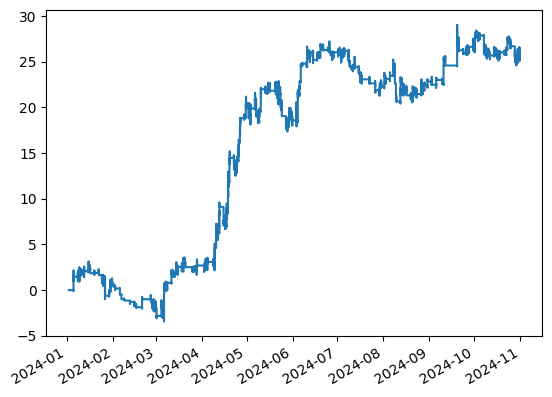

In [2697]:
xx.plot()

In [2698]:
#df[0:50]

In [2699]:
xx[-1:]

2024-10-31 17:59:58    25.265
dtype: float64

In [2700]:
df['date']=df['timestamp'].apply(lambda x: x.date())

In [2701]:
# # Ensure that the index is a DatetimeIndex if not already
# xx.index = pd.to_datetime(xx.index)

# # Filter for dates in 2024
# dates_2024 = xx[xx.index.year == 2024].index.normalize().unique()

# # Iterate over each unique date in 2024 and plot
# for date in dates_2024:
#     daily_data = xx[(xx.index >= date) & (xx.index < date + pd.Timedelta(days=1))]
#     daily_data = daily_data-daily_data[0]
    
#     # Plot the data for the current date
#     plt.figure(figsize=(10, 6))
#     daily_data.plot()
#     plt.title(f"Data for {date.date()}")
#     plt.xlabel("Time")
#     plt.ylabel("Values")
#     plt.grid(True)
#     plt.show()

In [2702]:
df['revenue']=-1*df['position']*df['price_level']

In [2703]:
a=df.groupby('date')['revenue'].sum()

In [2704]:
sum(a)

41.1899999999983

In [2705]:
(a>0).value_counts()

revenue
True     96
False    82
Name: count, dtype: int64

In [2706]:
len(df)

910

In [2707]:
sum(a)/len(df)

0.045263736263734394

In [2708]:
reutrn_df=pd.DataFrame(xx, columns=['returns'])

reutrn_df['returns']=reutrn_df['returns'].diff()
reutrn_df=reutrn_df[reutrn_df['returns']!=0]

In [2709]:
# Select odd and even indexed rows
even_index = df.iloc[1::2]['revenue'].reset_index(drop=True)  # Rows 1, 3, 5, ...
odd_index = df.iloc[0::2]['revenue'].reset_index(drop=True)   # Rows 0, 2, 4, ...

# Subtract odd-indexed rows from even-indexed rows
difference = even_index + odd_index
reutrn_df=pd.DataFrame(difference)
reutrn_df.columns=['returns']
reutrn_df

,returns
0,1.54
1,-0.39
2,0.42
3,0.28
4,-0.53
...,...
450,0.36
451,0.30
452,-0.51
453,-0.40


Accuracy: 0.47912087912087914


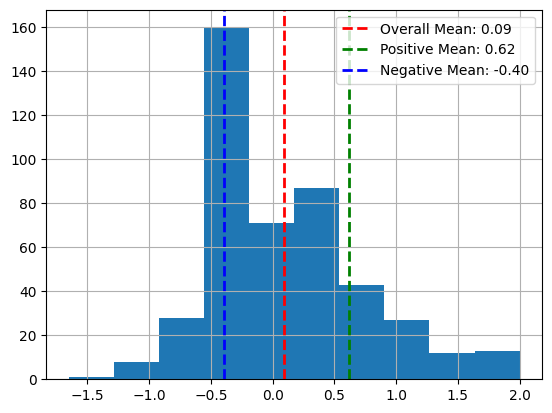

In [2710]:
# Assuming 'reutrn_df' is a DataFrame and 'returns' is a column in it
overall_mean = reutrn_df['returns'].mean()
positive_mean = reutrn_df[reutrn_df['returns'] > 0]['returns'].mean()
negative_mean = reutrn_df[reutrn_df['returns'] < 0]['returns'].mean()
 
# Print accuracy
accuracy = sum(reutrn_df['returns'] > 0) / len(reutrn_df)
print('Accuracy:', accuracy)
 
# Plot histogram
reutrn_df[abs(reutrn_df['returns']) >= 0.01]['returns'].hist()
 
# Add vertical lines
plt.axvline(overall_mean, color='r', linestyle='dashed', linewidth=2, label=f'Overall Mean: {overall_mean:.2f}')
plt.axvline(positive_mean, color='g', linestyle='dashed', linewidth=2, label=f'Positive Mean: {positive_mean:.2f}')
plt.axvline(negative_mean, color='b', linestyle='dashed', linewidth=2, label=f'Negative Mean: {negative_mean:.2f}')
 
# Add a legend
plt.legend()
 
# Show plot
plt.show()

In [2711]:

# Initialize variables
counts = []
current_value = None
current_count = 0

# Loop through the data
for value in pd.DataFrame(a>0)['revenue'].apply(int):
    if value == current_value:
        current_count += 1
    else:
        if current_value is not None:
            counts.append((current_value, current_count))
        current_value = value
        current_count = 1

# Append the last sequence
counts.append((current_value, current_count))

# Display the result
counts_df = pd.DataFrame(counts, columns=['Value', 'Count'])

counts_df[counts_df['Value']==1].value_counts()

Value  Count
1      1        23
       2        10
       3         6
       4         3
       5         2
       6         1
       7         1
Name: count, dtype: int64

In [2712]:
result=[]
for date in sorted(list(set(df['timestamp'].apply(lambda x: x.date())))):
    df_day = df[df['timestamp'].apply(lambda x: x.date()) == date]
    even_index = df_day.iloc[1::2]['revenue'].reset_index(drop=True)  # Rows 1, 3, 5, ...
    odd_index = df_day.iloc[0::2]['revenue'].reset_index(drop=True)   # Rows 0, 2, 4, ...
    
    # Calculate the difference
    difference = even_index + odd_index
    
    # Create the DataFrame
    return_df = pd.DataFrame(difference)
    return_df.columns = ['returns']
    
    # Identify the first occurrence of 'returns' < -1
    mask = return_df['returns'] < -1.2
    row_index = mask.idxmax()  # Get the index of the first occurrence
    
    # If a value < -1 is found, slice the DataFrame to remove all subsequent rows
    if mask.any():
        return_df = return_df.iloc[:row_index+1]
        
    #print(return_df)
    result.append(return_df)
    
    
sum(pd.concat(result)['returns'])

40.949999999998305

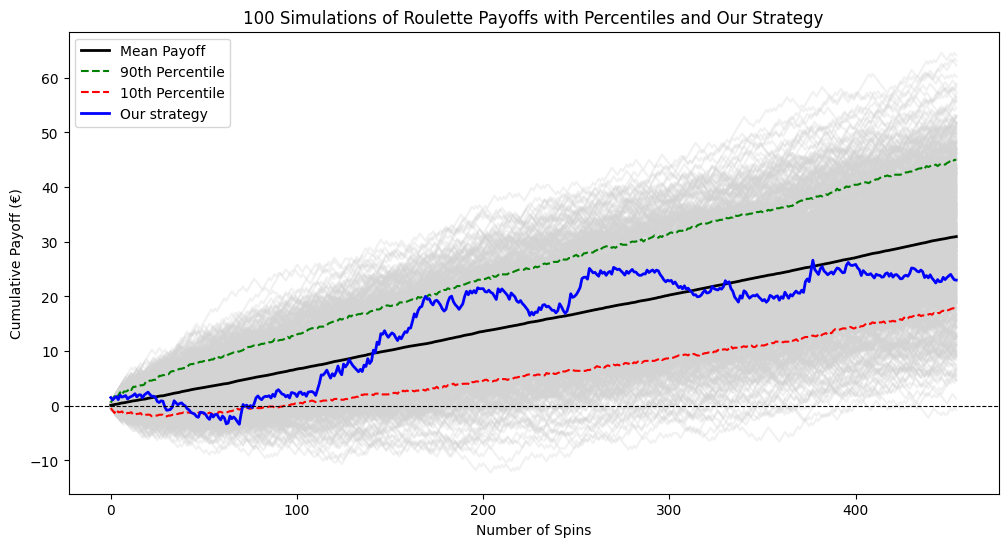

In [2713]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_spins = int(len(df) / 2)  # Number of spins per simulation
num_simulations = 1000  # Number of simulations
payoff_red = positive_mean - 0.04  # Payoff for red
payoff_black = negative_mean - 0.04  # Loss for black

# Roulette wheel setup
colors = ['red'] * 18 + ['black'] * 18 + ['green']

# Run simulations
all_simulations = []
np.random.seed(22)  # For reproducibility

for _ in range(num_simulations):
    results = np.random.choice(colors, num_spins)
    payoffs = [payoff_red if color == 'red' else payoff_black if color == 'black' else 0 for color in results]
    cumulative_payoffs = np.cumsum(payoffs)
    all_simulations.append(cumulative_payoffs)

# Convert to array for easier calculations
all_simulations = np.array(all_simulations)

# Calculate the mean, 75th percentile, and 25th percentile of cumulative payoffs
mean_payoff = all_simulations.mean(axis=0)
percentile_90 = np.percentile(all_simulations, 90, axis=0)
percentile_10 = np.percentile(all_simulations, 10, axis=0)

# Plot each simulation in one graph
plt.figure(figsize=(12, 6))
for i in range(num_simulations):
    plt.plot(all_simulations[i], color="lightgrey", alpha=0.3)

# Plot the mean of all simulations in black
plt.plot(mean_payoff, color="black", label="Mean Payoff", linewidth=2)

# Plot the 75th and 25th percentiles
plt.plot(percentile_90, color="green", linestyle="--", label="90th Percentile")
plt.plot(percentile_10, color="red", linestyle="--", label="10th Percentile")

# Plot the cumulative payoff of "Our strategy" if defined
plt.plot((reutrn_df['returns'] - 0.04).cumsum(), label="Our strategy", color="blue", linewidth=2)

# Plot formatting
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Zero line
plt.xlabel("Number of Spins")
plt.ylabel("Cumulative Payoff (€)")
plt.title("100 Simulations of Roulette Payoffs with Percentiles and Our Strategy")
plt.legend()
plt.show()

# Misc

In [2714]:
# lag_price_tick=93.99923076923076
# coef1=0
# coef2=0.8661
# lead_price_tick=92.0
# lead_price=92.1

# lag_price_tick*np.exp((coef1+coef2*np.log(lead_price/lead_price_tick)))

In [2715]:
# public_lead_trade_list=[(89.75, 1.0, 'Eurex T7/DEBM092024-20240822/2485/1', 1724323584.6690397), (89.75, 2.0, 'Eurex T7/DEBM092024-20240822/2480/2', 1724323559.7314084), (89.85, 1.0, 'Eurex T7/DEBM092024-20240822/2475/1', 1724323501.7010565), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/2454/1', 1724323439.289843), (89.94, 1.0, 'Eurex T7/DEBM092024-20240822/2392/1', 1724322914.0422606), (89.93, 1.0, 'Eurex T7/DEBM092024-20240822/2386/1', 1724322889.804086), (89.93, 1.0, 'Eurex T7/DEBM092024-20240822/2385/1', 1724322889.4707313), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/2384/1', 1724322888.9664116), (89.93, 1.0, 'Eurex T7/DEBM092024-20240822/2383/1', 1724322884.925085), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/2381/1', 1724322884.381066), (89.93, 1.0, 'Eurex T7/DEBM092024-20240822/2378/1', 1724322878.332864), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/2377/1', 1724322871.267875), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/2373/1', 1724322864.9656823), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/2370/1', 1724322864.143631), (89.94, 1.0, 'Eurex T7/DEBM092024-20240822/2368/1', 1724322862.936288), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/2357/1', 1724322814.2470136), (90.01, 1.0, 'Eurex T7/DEBM092024-20240822/2350/1', 1724322764.182361), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2348/1', 1724322764.0795631), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2347/1', 1724322759.9789553), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2346/1', 1724322758.2885172), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2345/1', 1724322752.0831337), (90.0, 3.0, 'Eurex T7/DEBM092024-20240822/2344/3', 1724322751.7735305), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2343/1', 1724322751.769698), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2342/1', 1724322751.758822), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2334/1', 1724322732.7743735), (90.0, 4.0, 'Eurex T7/DEBM092024-20240822/2333/4', 1724322732.7735443), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2331/1', 1724322720.0171447), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/2329/1', 1724322699.3170757), (90.01, 1.0, 'Eurex T7/DEBM092024-20240822/2326/1', 1724322675.822574), (90.01, 1.0, 'Eurex T7/DEBM092024-20240822/2323/1', 1724322665.801591), (90.01, 1.0, 'Eurex T7/DEBM092024-20240822/2322/1', 1724322660.7819748), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2310/1', 1724322638.2830148), (90.0, 4.0, 'Eurex T7/DEBM092024-20240822/2309/4', 1724322638.2698717), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/2308/1', 1724322638.25533), (90.0, 3.0, 'Eurex T7/DEBM092024-20240822/2305/3', 1724322635.9359868), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2303/1', 1724322635.8894951), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2301/1', 1724322635.8775277), (90.0, 2.0, 'Eurex T7/DEBM092024-20240822/2300/2', 1724322635.875678), (90.0, 3.0, 'Eurex T7/DEBM092024-20240822/2299/3', 1724322635.8755999), (90.0, 3.0, 'Eurex T7/DEBM092024-20240822/2295/3', 1724322635.8687346), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2294/1', 1724322635.86869), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2291/1', 1724322635.867508), (90.0, 2.0, 'Eurex T7/DEBM092024-20240822/2290/2', 1724322635.7464259), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2289/1', 1724322635.7326744), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2288/1', 1724322635.732644), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2287/1', 1724322635.7326035), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2286/1', 1724322635.732501), (90.01, 2.0, 'Eurex T7/DEBM092024-20240822/2285/2', 1724322635.7211576), (90.01, 1.0, 'Eurex T7/DEBM092024-20240822/2284/1', 1724322635.7211225), (90.05, 3.0, 'Eurex T7/DEBM092024-20240822/2252/3', 1724322541.964349), (90.06, 1.0, 'Eurex T7/DEBM092024-20240822/2249/1', 1724322541.9541392), (90.1, 2.0, 'Eurex T7/DEBM092024-20240822/2234/2', 1724322428.2971294), (90.15, 2.0, 'Eurex T7/DEBM092024-20240822/2197/2', 1724321848.1932032), (90.15, 2.0, 'Eurex T7/DEBM092024-20240822/2189/2', 1724321827.6285326), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/2186/1', 1724321803.7072403), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/2184/1', 1724321803.6965804), (90.2, 3.0, 'Eurex T7/DEBM092024-20240822/2183/3', 1724321803.6858444), (90.25, 2.0, 'Eurex T7/DEBM092024-20240822/2140/2', 1724321382.4579003), (90.18, 1.0, 'Eurex T7/DEBM092024-20240822/2110/1', 1724321241.7975068), (90.17, 1.0, 'Eurex T7/DEBM092024-20240822/2109/1', 1724321241.7355912), (90.17, 2.0, 'Eurex T7/DEBM092024-20240822/2108/2', 1724321235.0889227), (90.15, 2.0, 'Eurex T7/DEBM092024-20240822/2104/2', 1724321225.557166), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/2102/1', 1724321223.4257717), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/2101/1', 1724321223.413177), (90.07, 1.0, 'Eurex T7/DEBM092024-20240822/2100/1', 1724321222.5468307), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/2096/1', 1724321216.6300557), (90.11, 3.0, 'Eurex T7/DEBM092024-20240822/2095/3', 1724321216.6299334), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/2088/1', 1724321210.0640044), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/2087/1', 1724321210.0639153), (90.15, 2.0, 'Eurex T7/DEBM092024-20240822/2083/2', 1724321097.8110332), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/2075/1', 1724321062.9818103), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/2071/1', 1724321059.0045133), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/2069/1', 1724321039.487842), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/2068/1', 1724321038.7834573), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/2067/1', 1724321038.5129883), (90.11, 2.0, 'Eurex T7/DEBM092024-20240822/2066/2', 1724321036.1058688), (90.11, 2.0, 'Eurex T7/DEBM092024-20240822/2060/2', 1724320968.1240356), (90.11, 1.0, 'Eurex T7/DEBM092024-20240822/2049/1', 1724320795.0470867), (90.11, 1.0, 'Eurex T7/DEBM092024-20240822/2048/1', 1724320795.0304368), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/2045/1', 1724320783.860824), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/2038/1', 1724320687.6638448), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/2037/1', 1724320687.6365929), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/2036/1', 1724320686.885352), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/2035/1', 1724320686.1036448), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/2034/1', 1724320686.0845134), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/2015/1', 1724320577.2968938), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/2012/1', 1724320577.2967677), (90.24, 1.0, 'Eurex T7/DEBM092024-20240822/1998/1', 1724320422.063694), (90.15, 3.0, 'Eurex T7/DEBM092024-20240822/1996/3', 1724320422.050002), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/1994/1', 1724320422.0498495), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1993/1', 1724320422.0498495), (90.24, 1.0, 'Eurex T7/DEBM092024-20240822/1988/1', 1724320410.2199693), (90.27, 1.0, 'Eurex T7/DEBM092024-20240822/1972/1', 1724320401.1404748), (90.33, 1.0, 'Eurex T7/DEBM092024-20240822/1943/1', 1724320246.60792), (90.35, 1.0, 'Eurex T7/DEBM092024-20240822/1942/1', 1724320246.6066291), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1916/1', 1724320035.7177026), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1915/1', 1724320035.704738), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1913/1', 1724320035.693319), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1911/1', 1724320035.6204538), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1910/1', 1724320035.6063516), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1909/1', 1724320035.6062608), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1905/1', 1724319990.3541467), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1904/1', 1724319990.3399336), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1903/1', 1724319990.3399003), (90.44, 1.0, 'Eurex T7/DEBM092024-20240822/1902/1', 1724319990.260911), (90.34, 2.0, 'Eurex T7/DEBM092024-20240822/1880/2', 1724319958.2520556), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1878/1', 1724319941.6093488), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1873/1', 1724319925.5459907), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1857/1', 1724319897.956918), (90.49, 1.0, 'Eurex T7/DEBM092024-20240822/1856/1', 1724319896.8039272), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1855/1', 1724319896.636464), (90.49, 1.0, 'Eurex T7/DEBM092024-20240822/1854/1', 1724319896.6217148), (90.42, 1.0, 'Eurex T7/DEBM092024-20240822/1853/1', 1724319895.0198953), (90.42, 1.0, 'Eurex T7/DEBM092024-20240822/1852/1', 1724319895.0198545), (90.42, 1.0, 'Eurex T7/DEBM092024-20240822/1837/1', 1724319873.4197235), (90.44, 1.0, 'Eurex T7/DEBM092024-20240822/1836/1', 1724319873.4192967), (90.44, 1.0, 'Eurex T7/DEBM092024-20240822/1823/1', 1724319786.9176896), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1804/1', 1724319601.4754653), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1790/1', 1724319537.901009), (90.49, 1.0, 'Eurex T7/DEBM092024-20240822/1789/1', 1724319537.8996992), (90.49, 1.0, 'Eurex T7/DEBM092024-20240822/1770/1', 1724319435.3499398), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1763/1', 1724319356.3868525), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1761/1', 1724319354.4957492), (90.5, 2.0, 'Eurex T7/DEBM092024-20240822/1760/2', 1724319354.4810712), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1734/1', 1724319143.6556723), (90.44, 1.0, 'Eurex T7/DEBM092024-20240822/1726/1', 1724319143.4353316), (90.44, 1.0, 'Eurex T7/DEBM092024-20240822/1724/1', 1724319143.4331963), (90.4, 1.0, 'Eurex T7/DEBM092024-20240822/1720/1', 1724319143.4254236), (90.26, 1.0, 'Eurex T7/DEBM092024-20240822/1705/1', 1724319034.4221044), (90.26, 1.0, 'Eurex T7/DEBM092024-20240822/1704/1', 1724319034.4212987), (90.3, 4.0, 'Eurex T7/DEBM092024-20240822/1692/4', 1724318917.9666836), (90.29, 1.0, 'Eurex T7/DEBM092024-20240822/1601/1', 1724318419.2089596), (90.29, 1.0, 'Eurex T7/DEBM092024-20240822/1600/1', 1724318412.8888073), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/1598/1', 1724318412.7772825), (90.24, 2.0, 'Eurex T7/DEBM092024-20240822/1581/2', 1724318359.2311199), (90.24, 1.0, 'Eurex T7/DEBM092024-20240822/1558/1', 1724318181.4386687), (90.24, 1.0, 'Eurex T7/DEBM092024-20240822/1557/1', 1724318180.830302), (90.24, 2.0, 'Eurex T7/DEBM092024-20240822/1556/2', 1724318180.62851), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1550/1', 1724318166.4436169), (90.11, 1.0, 'Eurex T7/DEBM092024-20240822/1543/1', 1724318106.0028267), (90.19, 1.0, 'Eurex T7/DEBM092024-20240822/1541/1', 1724318100.0732207), (90.3, 2.0, 'Eurex T7/DEBM092024-20240822/1506/2', 1724317951.9891336), (90.29, 1.0, 'Eurex T7/DEBM092024-20240822/1505/1', 1724317951.9890788), (90.25, 2.0, 'Eurex T7/DEBM092024-20240822/1492/2', 1724317928.6891723), (90.06, 2.0, 'Eurex T7/DEBM092024-20240822/1449/2', 1724317609.7334461), (90.3, 1.0, 'Eurex T7/DEBM092024-20240822/1435/1', 1724317454.173226), (90.28, 1.0, 'Eurex T7/DEBM092024-20240822/1433/1', 1724317451.1715555), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1424/1', 1724317402.7598703), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1422/1', 1724317402.3868475), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/1421/1', 1724317356.598112), (90.06, 1.0, 'Eurex T7/DEBM092024-20240822/1419/1', 1724317356.598112), (90.33, 2.0, 'Eurex T7/DEBM092024-20240822/1409/2', 1724317285.8655791), (90.22, 1.0, 'Eurex T7/DEBM092024-20240822/1406/1', 1724317281.7007003), (90.22, 1.0, 'Eurex T7/DEBM092024-20240822/1405/1', 1724317281.5933814), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/1403/1', 1724317281.539542), (90.22, 1.0, 'Eurex T7/DEBM092024-20240822/1402/1', 1724317281.5394857), (90.22, 1.0, 'Eurex T7/DEBM092024-20240822/1401/1', 1724317281.5062497), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/1397/1', 1724317226.2090259), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1387/1', 1724317185.553646), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/1378/1', 1724317115.0133877), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/1376/1', 1724317106.328941), (90.06, 1.0, 'Eurex T7/DEBM092024-20240822/1375/1', 1724317106.328941), (90.11, 1.0, 'Eurex T7/DEBM092024-20240822/1357/1', 1724317022.1678813), (90.05, 4.0, 'Eurex T7/DEBM092024-20240822/1356/4', 1724317022.153823), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/1355/1', 1724317022.1538005), (90.05, 4.0, 'Eurex T7/DEBM092024-20240822/1354/4', 1724317022.1536963), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1349/1', 1724316957.865848), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1333/1', 1724316832.1054995), (90.1, 4.0, 'Eurex T7/DEBM092024-20240822/1332/4', 1724316831.888408), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1331/1', 1724316831.8883245), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1329/1', 1724316831.659161), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/1324/1', 1724316813.627568), (90.14, 1.0, 'Eurex T7/DEBM092024-20240822/1322/1', 1724316800.4907196), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1318/1', 1724316798.7221324), (90.12, 2.0, 'Eurex T7/DEBM092024-20240822/1302/2', 1724316755.4930477), (90.15, 3.0, 'Eurex T7/DEBM092024-20240822/1295/3', 1724316741.4602492), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/1292/1', 1724316716.3892038), (90.16, 3.0, 'Eurex T7/DEBM092024-20240822/1290/3', 1724316693.3911674), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1287/1', 1724316672.23878), (90.2, 6.0, 'Eurex T7/DEBM092024-20240822/1280/6', 1724316635.5652854), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1279/1', 1724316632.839723), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1277/1', 1724316632.0207603), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1276/1', 1724316631.2046995), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1275/1', 1724316630.4206505), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1274/1', 1724316629.5322905), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1273/1', 1724316628.3817768), (90.21, 2.0, 'Eurex T7/DEBM092024-20240822/1272/2', 1724316627.3249743), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1259/1', 1724316523.6255226), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1245/1', 1724316480.100555), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1244/1', 1724316480.1005208), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1234/1', 1724316464.3291733), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1229/1', 1724316347.540898), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/1227/1', 1724316343.523936), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1226/1', 1724316343.5100172), (90.24, 2.0, 'Eurex T7/DEBM092024-20240822/1219/2', 1724316320.129714), (90.24, 1.0, 'Eurex T7/DEBM092024-20240822/1217/1', 1724316320.107968), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/1209/1', 1724316319.30882), (90.31, 3.0, 'Eurex T7/DEBM092024-20240822/1205/3', 1724316317.682334), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/1202/1', 1724316311.0710485), (90.35, 1.0, 'Eurex T7/DEBM092024-20240822/1180/1', 1724316240.9643228), (90.52, 1.0, 'Eurex T7/DEBM092024-20240822/1159/1', 1724316004.8431573), (90.52, 1.0, 'Eurex T7/DEBM092024-20240822/1158/1', 1724316004.8002436), (90.53, 1.0, 'Eurex T7/DEBM092024-20240822/1152/1', 1724315987.9153233), (90.53, 1.0, 'Eurex T7/DEBM092024-20240822/1151/1', 1724315987.9049737), (90.54, 1.0, 'Eurex T7/DEBM092024-20240822/1149/1', 1724315987.891716), (90.54, 1.0, 'Eurex T7/DEBM092024-20240822/1148/1', 1724315987.8916855), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/1145/1', 1724315987.7117484), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/1140/1', 1724315959.702072), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/1069/1', 1724315370.0572128), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1057/1', 1724315243.460674), (90.28, 1.0, 'Eurex T7/DEBM092024-20240822/997/1', 1724314753.175198), (90.4, 1.0, 'Eurex T7/DEBM092024-20240822/990/1', 1724314624.7983763), (90.54, 1.0, 'Eurex T7/DEBM092024-20240822/986/1', 1724314550.3570404), (90.54, 1.0, 'Eurex T7/DEBM092024-20240822/985/1', 1724314550.3569732), (90.62, 1.0, 'Eurex T7/DEBM092024-20240822/982/1', 1724314422.8114336), (90.78, 1.0, 'Eurex T7/DEBM092024-20240822/969/1', 1724314339.55248), (90.78, 1.0, 'Eurex T7/DEBM092024-20240822/968/1', 1724314334.3446524), (90.78, 1.0, 'Eurex T7/DEBM092024-20240822/967/1', 1724314334.3427045), (90.73, 1.0, 'Eurex T7/DEBM092024-20240822/961/1', 1724314325.7252033), (90.7, 6.0, 'Eurex T7/DEBM092024-20240822/957/6', 1724314301.3723724), (90.7, 1.0, 'Eurex T7/DEBM092024-20240822/956/1', 1724314301.357726), (90.62, 1.0, 'Eurex T7/DEBM092024-20240822/954/1', 1724314232.538169), (90.61, 1.0, 'Eurex T7/DEBM092024-20240822/953/1', 1724314229.562926), (90.62, 3.0, 'Eurex T7/DEBM092024-20240822/951/3', 1724314218.641083), (90.63, 3.0, 'Eurex T7/DEBM092024-20240822/947/3', 1724314174.6748688), (90.68, 3.0, 'Eurex T7/DEBM092024-20240822/946/3', 1724314168.2444692), (90.7, 3.0, 'Eurex T7/DEBM092024-20240822/945/3', 1724314162.5991292), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/944/1', 1724314144.4011118), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/943/1', 1724314144.4010804), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/942/1', 1724314144.4010298), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/941/1', 1724314140.0150821), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/940/1', 1724314138.9744575), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/939/1', 1724314138.89471), (90.68, 1.0, 'Eurex T7/DEBM092024-20240822/932/1', 1724314052.4135036), (90.7, 2.0, 'Eurex T7/DEBM092024-20240822/931/2', 1724314052.21352), (90.7, 1.0, 'Eurex T7/DEBM092024-20240822/930/1', 1724314052.213479), (90.73, 1.0, 'Eurex T7/DEBM092024-20240822/929/1', 1724314045.907944), (90.7, 3.0, 'Eurex T7/DEBM092024-20240822/928/3', 1724314045.3432565), (90.65, 2.0, 'Eurex T7/DEBM092024-20240822/912/2', 1724313908.6212993), (90.65, 1.0, 'Eurex T7/DEBM092024-20240822/911/1', 1724313908.621264), (90.65, 1.0, 'Eurex T7/DEBM092024-20240822/898/1', 1724313651.5306897), (90.73, 1.0, 'Eurex T7/DEBM092024-20240822/894/1', 1724313622.3722167), (90.76, 1.0, 'Eurex T7/DEBM092024-20240822/892/1', 1724313608.4087949), (90.76, 1.0, 'Eurex T7/DEBM092024-20240822/888/1', 1724313608.3323762), (90.75, 1.0, 'Eurex T7/DEBM092024-20240822/887/1', 1724313607.4128115), (90.7, 5.0, 'Eurex T7/DEBM092024-20240822/886/5', 1724313605.4046094), (90.7, 1.0, 'Eurex T7/DEBM092024-20240822/885/1', 1724313605.4045496), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/878/1', 1724313572.538332), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/877/1', 1724313572.5382793), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/876/1', 1724313572.5382283), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/875/1', 1724313572.53452), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/874/1', 1724313572.5340242), (90.6, 2.0, 'Eurex T7/DEBM092024-20240822/853/2', 1724313470.2874308), (90.69, 1.0, 'Eurex T7/DEBM092024-20240822/847/1', 1724313376.4839187), (90.74, 1.0, 'Eurex T7/DEBM092024-20240822/842/1', 1724313328.7846925), (90.75, 1.0, 'Eurex T7/DEBM092024-20240822/841/1', 1724313328.6770878), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/840/1', 1724313328.1433537), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/839/1', 1724313327.7862072), (90.71, 1.0, 'Eurex T7/DEBM092024-20240822/838/1', 1724313327.550946), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/837/1', 1724313327.5419867), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/836/1', 1724313327.5402982), (90.63, 1.0, 'Eurex T7/DEBM092024-20240822/828/1', 1724313288.4343708), (90.63, 1.0, 'Eurex T7/DEBM092024-20240822/827/1', 1724313286.9023333), (90.64, 2.0, 'Eurex T7/DEBM092024-20240822/823/2', 1724313244.6769211), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/820/1', 1724313233.9626637), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/819/1', 1724313233.425249), (90.5, 3.0, 'Eurex T7/DEBM092024-20240822/818/3', 1724313230.846643), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/817/1', 1724313230.283558), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/816/1', 1724313230.0752983), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/815/1', 1724313227.2732337), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/814/1', 1724313226.7387185), (90.49, 1.0, 'Eurex T7/DEBM092024-20240822/813/1', 1724313221.584046), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/812/1', 1724313214.853865), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/811/1', 1724313214.068796), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/810/1', 1724313213.891255), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/809/1', 1724313213.4579668), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/808/1', 1724313213.1862864), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/807/1', 1724313212.9036229), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/806/1', 1724313212.6620128), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/805/1', 1724313212.4443069), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/803/1', 1724313212.185825), (90.51, 1.0, 'Eurex T7/DEBM092024-20240822/802/1', 1724313210.7732327), (90.51, 1.0, 'Eurex T7/DEBM092024-20240822/801/1', 1724313210.7731824), (90.51, 3.0, 'Eurex T7/DEBM092024-20240822/800/3', 1724313210.537782), (90.64, 1.0, 'Eurex T7/DEBM092024-20240822/792/1', 1724313191.4650595), (90.64, 1.0, 'Eurex T7/DEBM092024-20240822/789/1', 1724313191.2234528), (90.74, 1.0, 'Eurex T7/DEBM092024-20240822/781/1', 1724313172.7977111), (90.7, 1.0, 'Eurex T7/DEBM092024-20240822/780/1', 1724313156.4188406), (90.8, 1.0, 'Eurex T7/DEBM092024-20240822/762/1', 1724313103.1174984), (90.8, 1.0, 'Eurex T7/DEBM092024-20240822/761/1', 1724313102.492908), (90.93, 1.0, 'Eurex T7/DEBM092024-20240822/754/1', 1724313076.4623723), (90.9, 1.0, 'Eurex T7/DEBM092024-20240822/753/1', 1724313076.22621), (90.9, 1.0, 'Eurex T7/DEBM092024-20240822/752/1', 1724313076.1930268), (90.87, 1.0, 'Eurex T7/DEBM092024-20240822/751/1', 1724313076.0836473), (90.89, 1.0, 'Eurex T7/DEBM092024-20240822/750/1', 1724313076.0836473), (90.9, 2.0, 'Eurex T7/DEBM092024-20240822/749/2', 1724313076.0836473), (90.93, 2.0, 'Eurex T7/DEBM092024-20240822/748/2', 1724313076.0836473), (90.9, 1.0, 'Eurex T7/DEBM092024-20240822/747/1', 1724313072.778052), (90.9, 1.0, 'Eurex T7/DEBM092024-20240822/746/1', 1724313068.1299727), (90.9, 2.0, 'Eurex T7/DEBM092024-20240822/745/2', 1724313066.721953), (90.9, 1.0, 'Eurex T7/DEBM092024-20240822/744/1', 1724313065.8397756), (90.99, 1.0, 'Eurex T7/DEBM092024-20240822/741/1', 1724313062.9201868), (90.99, 2.0, 'Eurex T7/DEBM092024-20240822/740/2', 1724313062.7119522), (90.99, 2.0, 'Eurex T7/DEBM092024-20240822/739/2', 1724313061.3138807), (90.99, 1.0, 'Eurex T7/DEBM092024-20240822/738/1', 1724313059.0862186), (90.99, 1.0, 'Eurex T7/DEBM092024-20240822/737/1', 1724313059.0861423), (90.97, 1.0, 'Eurex T7/DEBM092024-20240822/736/1', 1724313058.995385), (90.97, 1.0, 'Eurex T7/DEBM092024-20240822/734/1', 1724313058.8878937), (90.98, 2.0, 'Eurex T7/DEBM092024-20240822/733/2', 1724313058.887765), (91.05, 1.0, 'Eurex T7/DEBM092024-20240822/731/1', 1724313040.3918269), (91.04, 1.0, 'Eurex T7/DEBM092024-20240822/728/1', 1724313037.8115046), (91.13, 2.0, 'Eurex T7/DEBM092024-20240822/727/2', 1724313037.5437384), (91.05, 3.0, 'Eurex T7/DEBM092024-20240822/726/3', 1724313036.3122308), (91.0, 8.0, 'Eurex T7/DEBM092024-20240822/725/8', 1724313026.4034786), (91.01, 2.0, 'Eurex T7/DEBM092024-20240822/724/2', 1724313026.4034786), (91.2, 5.0, 'Eurex T7/DEBM092024-20240822/715/5', 1724312988.6604123), (91.19, 1.0, 'Eurex T7/DEBM092024-20240822/714/1', 1724312988.6604123), (91.13, 1.0, 'Eurex T7/DEBM092024-20240822/710/1', 1724312987.8000195), (91.12, 1.0, 'Eurex T7/DEBM092024-20240822/708/1', 1724312987.1760936), (91.18, 1.0, 'Eurex T7/DEBM092024-20240822/702/1', 1724312986.6963537), (90.9, 5.0, 'Eurex T7/DEBM092024-20240822/686/5', 1724312941.6969185), (90.9, 1.0, 'Eurex T7/DEBM092024-20240822/682/1', 1724312929.874989), (90.87, 2.0, 'Eurex T7/DEBM092024-20240822/677/2', 1724312907.2507265), (90.79, 1.0, 'Eurex T7/DEBM092024-20240822/676/1', 1724312901.795318), (90.65, 1.0, 'Eurex T7/DEBM092024-20240822/675/1', 1724312889.8726304), (90.65, 1.0, 'Eurex T7/DEBM092024-20240822/673/1', 1724312868.5054967), (90.6, 5.0, 'Eurex T7/DEBM092024-20240822/670/5', 1724312845.8998044), (90.68, 3.0, 'Eurex T7/DEBM092024-20240822/664/3', 1724312787.1193557), (90.6, 1.0, 'Eurex T7/DEBM092024-20240822/661/1', 1724312719.172742), (90.47, 2.0, 'Eurex T7/DEBM092024-20240822/660/2', 1724312711.2968173), (90.47, 2.0, 'Eurex T7/DEBM092024-20240822/659/2', 1724312711.2967172), (90.48, 1.0, 'Eurex T7/DEBM092024-20240822/658/1', 1724312711.2967172), (90.49, 2.0, 'Eurex T7/DEBM092024-20240822/656/2', 1724312666.5518208), (90.49, 1.0, 'Eurex T7/DEBM092024-20240822/655/1', 1724312666.5517902), (90.5, 3.0, 'Eurex T7/DEBM092024-20240822/653/3', 1724312666.4638405), (90.61, 1.0, 'Eurex T7/DEBM092024-20240822/651/1', 1724312666.292862), (90.46, 1.0, 'Eurex T7/DEBM092024-20240822/644/1', 1724312640.6052353), (90.5, 5.0, 'Eurex T7/DEBM092024-20240822/642/5', 1724312627.2470632), (90.51, 2.0, 'Eurex T7/DEBM092024-20240822/641/2', 1724312626.884677), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/638/1', 1724312615.8524363), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/637/1', 1724312615.8523848), (90.58, 1.0, 'Eurex T7/DEBM092024-20240822/632/1', 1724312496.731616), (90.58, 2.0, 'Eurex T7/DEBM092024-20240822/631/2', 1724312496.6239111), (90.59, 2.0, 'Eurex T7/DEBM092024-20240822/629/2', 1724312438.0352187), (90.59, 1.0, 'Eurex T7/DEBM092024-20240822/628/1', 1724312438.0351365), (90.59, 2.0, 'Eurex T7/DEBM092024-20240822/627/2', 1724312437.9032228), (90.59, 1.0, 'Eurex T7/DEBM092024-20240822/626/1', 1724312437.9031343), (90.59, 3.0, 'Eurex T7/DEBM092024-20240822/625/3', 1724312436.2868557), (90.56, 1.0, 'Eurex T7/DEBM092024-20240822/620/1', 1724312396.65112), (90.52, 1.0, 'Eurex T7/DEBM092024-20240822/618/1', 1724312385.8073153), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/617/1', 1724312385.7425811), (90.44, 2.0, 'Eurex T7/DEBM092024-20240822/606/2', 1724312351.131683), (90.4, 3.0, 'Eurex T7/DEBM092024-20240822/604/3', 1724312348.991707), (90.4, 2.0, 'Eurex T7/DEBM092024-20240822/603/2', 1724312348.9916644), (90.35, 1.0, 'Eurex T7/DEBM092024-20240822/602/1', 1724312348.0411608), (90.35, 1.0, 'Eurex T7/DEBM092024-20240822/594/1', 1724312319.0838766), (90.35, 1.0, 'Eurex T7/DEBM092024-20240822/593/1', 1724312318.8944812), (90.35, 2.0, 'Eurex T7/DEBM092024-20240822/593/2', 1724312318.8944812), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/587/1', 1724312303.1176603), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/585/1', 1724312302.7339804), (90.42, 1.0, 'Eurex T7/DEBM092024-20240822/579/1', 1724312247.4645126), (90.43, 1.0, 'Eurex T7/DEBM092024-20240822/570/1', 1724312149.547256), (90.51, 1.0, 'Eurex T7/DEBM092024-20240822/560/1', 1724312111.2571812), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/558/1', 1724312111.1691132), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/557/1', 1724312111.1551764), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/555/1', 1724312106.521176), (90.39, 1.0, 'Eurex T7/DEBM092024-20240822/554/1', 1724312103.8268387), (90.39, 1.0, 'Eurex T7/DEBM092024-20240822/553/1', 1724312103.046635), (90.39, 1.0, 'Eurex T7/DEBM092024-20240822/552/1', 1724312101.0099647), (90.39, 1.0, 'Eurex T7/DEBM092024-20240822/551/1', 1724312100.8675601), (90.39, 1.0, 'Eurex T7/DEBM092024-20240822/550/1', 1724312100.2869985), (90.4, 1.0, 'Eurex T7/DEBM092024-20240822/549/1', 1724312100.2280526), (90.39, 1.0, 'Eurex T7/DEBM092024-20240822/548/1', 1724312100.2108808), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/547/1', 1724312100.0154066), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/545/1', 1724312088.6211734), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/543/1', 1724312085.4724908), (90.41, 1.0, 'Eurex T7/DEBM092024-20240822/542/1', 1724312085.4436316), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/539/1', 1724312084.404693), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/537/1', 1724312084.2672856), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/531/1', 1724312072.325666), (90.33, 1.0, 'Eurex T7/DEBM092024-20240822/524/1', 1724312032.2868328), (90.3, 1.0, 'Eurex T7/DEBM092024-20240822/523/1', 1724312032.2717023), (90.3, 1.0, 'Eurex T7/DEBM092024-20240822/495/1', 1724311846.885989), (90.28, 1.0, 'Eurex T7/DEBM092024-20240822/485/1', 1724311825.1691587), (90.28, 2.0, 'Eurex T7/DEBM092024-20240822/479/2', 1724311803.1779013), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/457/1', 1724311506.03327), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/455/1', 1724311505.543336), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/453/1', 1724311505.1617832), (90.18, 1.0, 'Eurex T7/DEBM092024-20240822/450/1', 1724311501.5201457), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/449/1', 1724311501.4546008), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/448/1', 1724311501.4545383), (90.15, 2.0, 'Eurex T7/DEBM092024-20240822/447/2', 1724311501.4544983), (90.14, 2.0, 'Eurex T7/DEBM092024-20240822/446/2', 1724311501.4544425), (90.02, 6.0, 'Eurex T7/DEBM092024-20240822/364/6', 1724310989.5952454), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/361/1', 1724310929.6132355), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/360/1', 1724310929.3519912), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/359/1', 1724310929.214472), (89.7, 1.0, 'Eurex T7/DEBM092024-20240822/358/1', 1724310915.236), (89.7, 1.0, 'Eurex T7/DEBM092024-20240822/355/1', 1724310870.2522893), (89.72, 5.0, 'Eurex T7/DEBM092024-20240822/354/5', 1724310869.1081583), (89.72, 1.0, 'Eurex T7/DEBM092024-20240822/353/1', 1724310855.9576497), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/351/1', 1724310838.9949777), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/350/1', 1724310838.8898876), (89.73, 1.0, 'Eurex T7/DEBM092024-20240822/349/1', 1724310826.1745887), (89.73, 1.0, 'Eurex T7/DEBM092024-20240822/348/1', 1724310826.0702088), (89.73, 1.0, 'Eurex T7/DEBM092024-20240822/347/1', 1724310826.0573807), (89.73, 2.0, 'Eurex T7/DEBM092024-20240822/346/2', 1724310826.0243237), (89.72, 1.0, 'Eurex T7/DEBM092024-20240822/345/1', 1724310819.7230349), (89.77, 1.0, 'Eurex T7/DEBM092024-20240822/338/1', 1724310816.588315), (89.73, 1.0, 'Eurex T7/DEBM092024-20240822/331/1', 1724310762.5711384), (89.8, 1.0, 'Eurex T7/DEBM092024-20240822/321/1', 1724310601.8698583), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/308/1', 1724310593.155781), (90.0, 2.0, 'Eurex T7/DEBM092024-20240822/280/2', 1724310388.9064784), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/279/1', 1724310386.223662), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/278/1', 1724310384.8626685), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/277/1', 1724310384.8605804), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/275/1', 1724310384.7769737), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/273/1', 1724310384.688986), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/268/1', 1724310360.2854674), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/267/1', 1724310360.2326145), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/266/1', 1724310355.554044), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/265/1', 1724310355.4747448), (90.1, 2.0, 'Eurex T7/DEBM092024-20240822/264/2', 1724310343.9097536), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/258/1', 1724310312.5667489), (90.06, 1.0, 'Eurex T7/DEBM092024-20240822/257/1', 1724310312.5667489), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/256/1', 1724310243.946018), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/255/1', 1724310243.8454757), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/254/1', 1724310206.0017161), (90.11, 2.0, 'Eurex T7/DEBM092024-20240822/253/2', 1724310204.7485049), (90.14, 1.0, 'Eurex T7/DEBM092024-20240822/251/1', 1724310181.656366), (90.12, 1.0, 'Eurex T7/DEBM092024-20240822/249/1', 1724310175.587924), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/248/1', 1724310170.0022564), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/245/1', 1724310103.47456), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/244/1', 1724310100.120732), (90.1, 5.0, 'Eurex T7/DEBM092024-20240822/243/5', 1724310086.4319265), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/240/1', 1724310065.2860217), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/238/1', 1724310063.3558557), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/237/1', 1724310062.2810955), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/231/1', 1724310033.8511124), (90.04, 2.0, 'Eurex T7/DEBM092024-20240822/226/2', 1724310005.4722004), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/224/1', 1724310000.328297), (89.99, 2.0, 'Eurex T7/DEBM092024-20240822/223/2', 1724310000.328297), (89.89, 5.0, 'Eurex T7/DEBM092024-20240822/220/5', 1724309835.8115532), (89.9, 7.0, 'Eurex T7/DEBM092024-20240822/216/7', 1724309790.166789), (89.9, 2.0, 'Eurex T7/DEBM092024-20240822/215/2', 1724309789.83091), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/211/1', 1724309776.113027), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/207/1', 1724309757.5831256), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/206/1', 1724309756.4233139), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/201/1', 1724309730.1642284), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/200/1', 1724309723.8828812), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/199/1', 1724309720.9878085), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/198/1', 1724309720.9870718), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/193/1', 1724309709.997769), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/191/1', 1724309682.1489964), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/189/1', 1724309682.0293715), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/184/1', 1724309667.07036), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/182/1', 1724309659.8789022), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/180/1', 1724309629.10755), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/179/1', 1724309629.1069896), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/178/1', 1724309629.1062171), (89.91, 3.0, 'Eurex T7/DEBM092024-20240822/177/3', 1724309628.2317712), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/176/1', 1724309628.231708), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/175/1', 1724309623.51605), (89.9, 5.0, 'Eurex T7/DEBM092024-20240822/174/5', 1724309623.1392248), (89.9, 4.0, 'Eurex T7/DEBM092024-20240822/173/4', 1724309623.1056707), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/172/1', 1724309623.0730057), (89.9, 5.0, 'Eurex T7/DEBM092024-20240822/171/5', 1724309623.0722446), (89.91, 2.0, 'Eurex T7/DEBM092024-20240822/170/2', 1724309623.0721614), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/169/1', 1724309616.3741205), (89.9, 5.0, 'Eurex T7/DEBM092024-20240822/168/5', 1724309616.3733392), (90.08, 1.0, 'Eurex T7/DEBM092024-20240822/161/1', 1724309546.0422711), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/157/1', 1724309510.7677777), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/156/1', 1724309510.7538888), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/155/1', 1724309510.5795038), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/154/1', 1724309506.9986928), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/151/1', 1724309499.9772575), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/150/1', 1724309499.9740047), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/149/1', 1724309499.9636595), (90.0, 3.0, 'Eurex T7/DEBM092024-20240822/148/3', 1724309498.1455767), (89.89, 1.0, 'Eurex T7/DEBM092024-20240822/128/1', 1724309219.2094903), (89.98, 1.0, 'Eurex T7/DEBM092024-20240822/125/1', 1724309142.5979505), (89.94, 1.0, 'Eurex T7/DEBM092024-20240822/123/1', 1724309133.887172), (89.9, 2.0, 'Eurex T7/DEBM092024-20240822/121/2', 1724309133.8771243), (89.9, 3.0, 'Eurex T7/DEBM092024-20240822/120/3', 1724309133.8770928), (89.8, 4.0, 'Eurex T7/DEBM092024-20240822/99/4', 1724308752.064205), (89.8, 2.0, 'Eurex T7/DEBM092024-20240822/98/2', 1724308705.2163212), (89.38, 1.0, 'Eurex T7/DEBM092024-20240822/90/1', 1724308558.4140668), (89.64, 2.0, 'Eurex T7/DEBM092024-20240822/88/2', 1724308497.434343), (89.64, 2.0, 'Eurex T7/DEBM092024-20240822/87/2', 1724308492.4149659), (89.64, 2.0, 'Eurex T7/DEBM092024-20240822/86/2', 1724308487.3960445), (89.52, 1.0, 'Eurex T7/DEBM092024-20240822/85/1', 1724308486.6142216), (89.52, 1.0, 'Eurex T7/DEBM092024-20240822/84/1', 1724308485.8142185), (89.6, 1.0, 'Eurex T7/DEBM092024-20240822/83/1', 1724308485.342009), (89.61, 5.0, 'Eurex T7/DEBM092024-20240822/82/5', 1724308485.3419852), (89.62, 1.0, 'Eurex T7/DEBM092024-20240822/80/1', 1724308485.3379831), (89.65, 2.0, 'Eurex T7/DEBM092024-20240822/79/2', 1724308485.1328983), (89.65, 2.0, 'Eurex T7/DEBM092024-20240822/78/2', 1724308482.350674), (89.68, 5.0, 'Eurex T7/DEBM092024-20240822/77/5', 1724308473.7273452), (89.7, 1.0, 'Eurex T7/DEBM092024-20240822/69/1', 1724308383.6153364), (89.71, 2.0, 'Eurex T7/DEBM092024-20240822/68/2', 1724308380.0152783), (89.71, 1.0, 'Eurex T7/DEBM092024-20240822/63/1', 1724308320.8672493), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/62/1', 1724308320.8398485), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/61/1', 1724308320.8347523), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/60/1', 1724308320.793697), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/59/1', 1724308320.7878113), (89.77, 1.0, 'Eurex T7/DEBM092024-20240822/58/1', 1724308272.068467), (89.78, 1.0, 'Eurex T7/DEBM092024-20240822/51/1', 1724308252.66252), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/49/1', 1724308149.710172), (89.87, 2.0, 'Eurex T7/DEBM092024-20240822/48/2', 1724308140.0733852), (89.8, 5.0, 'Eurex T7/DEBM092024-20240822/41/5', 1724308033.665103), (89.86, 1.0, 'Eurex T7/DEBM092024-20240822/40/1', 1724308012.6004214), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/39/1', 1724308012.5359755), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/38/1', 1724308012.521078), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/36/1', 1724307994.0736327), (89.89, 1.0, 'Eurex T7/DEBM092024-20240822/31/1', 1724307887.751231), (89.81, 1.0, 'Eurex T7/DEBM092024-20240822/30/1', 1724307829.7744524), (89.81, 1.0, 'Eurex T7/DEBM092024-20240822/29/1', 1724307829.537316), (89.82, 1.0, 'Eurex T7/DEBM092024-20240822/28/1', 1724307829.5359993), (89.82, 1.0, 'Eurex T7/DEBM092024-20240822/27/1', 1724307829.1120715), (89.82, 1.0, 'Eurex T7/DEBM092024-20240822/26/1', 1724307828.8668523), (89.82, 1.0, 'Eurex T7/DEBM092024-20240822/25/1', 1724307828.5655742), (89.82, 1.0, 'Eurex T7/DEBM092024-20240822/24/1', 1724307828.3657467), (89.81, 1.0, 'Eurex T7/DEBM092024-20240822/23/1', 1724307828.1181793), (89.9, 3.0, 'Eurex T7/DEBM092024-20240822/22/3', 1724307763.853368), (89.92, 1.0, 'Eurex T7/DEBM092024-20240822/20/1', 1724307646.6080775), (89.92, 2.0, 'Eurex T7/DEBM092024-20240822/19/2', 1724307643.314752), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/18/1', 1724307637.8534052), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/17/1', 1724307637.815487), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/16/1', 1724307637.814086), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/15/1', 1724307637.814002), (89.8, 2.0, 'Eurex T7/DEBM092024-20240822/14/2', 1724307549.9824705), (89.8, 3.0, 'Eurex T7/DEBM092024-20240822/12/3', 1724307339.1703608), (89.8, 2.0, 'Eurex T7/DEBM092024-20240822/11/2', 1724307332.1066935), (89.7, 1.0, 'Eurex T7/DEBM092024-20240822/7/1', 1724307236.06749), (89.7, 1.0, 'Eurex T7/DEBM092024-20240822/6/1', 1724307236.0570045), (89.7, 1.0, 'Eurex T7/DEBM092024-20240822/5/1', 1724307236.0465364), (89.3, 1.0, 'Eurex T7/DEBM092024-20240822/4/1', 1724307161.7017753), (89.31, 1.0, 'Eurex T7/DEBM092024-20240822/3/1', 1724307160.702554), (89.23, 2.0, 'Eurex T7/DEBM092024-20240822/2/2', 1724307008.2592883), (89.22, 2.0, 'Eurex T7/DEBM092024-20240822/1/2', 1724306897.5436828), (90.25, 1.0, 'Eurex T7/DEBM092024-20240821/8324/1', 1724255936.7855563), (90.24, 1.0, 'Eurex T7/DEBM092024-20240821/8323/1', 1724255936.7854784), (90.13, 1.0, 'Eurex T7/DEBM092024-20240821/8319/1', 1724255924.4278436), (90.18, 1.0, 'Eurex T7/DEBM092024-20240821/8316/1', 1724255862.1909611), (90.21, 1.0, 'Eurex T7/DEBM092024-20240821/8308/1', 1724255752.0667663), (90.06, 1.0, 'Eurex T7/DEBM092024-20240821/8285/1', 1724255572.7463403), (90.1, 1.0, 'Eurex T7/DEBM092024-20240821/8284/1', 1724255534.748784), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8283/1', 1724255534.7471433), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8282/1', 1724255534.747008), (90.1, 2.0, 'Eurex T7/DEBM092024-20240821/8278/2', 1724255534.541846), (90.1, 2.0, 'Eurex T7/DEBM092024-20240821/8269/2', 1724255444.5701644), (90.24, 1.0, 'Eurex T7/DEBM092024-20240821/8248/1', 1724254916.329058), (90.24, 2.0, 'Eurex T7/DEBM092024-20240821/8226/2', 1724254835.4670465), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8224/1', 1724254809.1732428), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8223/1', 1724254808.6585171), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8222/1', 1724254808.0688777), (90.2, 5.0, 'Eurex T7/DEBM092024-20240821/8222/5', 1724254808.0688777), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8221/1', 1724254808.045462), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8220/1', 1724254808.0441532), (90.17, 1.0, 'Eurex T7/DEBM092024-20240821/8219/1', 1724254801.2721152), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8181/1', 1724254542.1504188), (90.22, 1.0, 'Eurex T7/DEBM092024-20240821/8176/1', 1724254542.14226), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8174/1', 1724254542.1392791), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8170/1', 1724254526.9867685), (90.14, 1.0, 'Eurex T7/DEBM092024-20240821/8169/1', 1724254526.986724), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8168/1', 1724254526.8356967), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8167/1', 1724254526.665379), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8166/1', 1724254526.586864), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8165/1', 1724254525.4053752), (90.1, 1.0, 'Eurex T7/DEBM092024-20240821/8160/1', 1724254462.8022137), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8159/1', 1724254460.3690836), (90.11, 1.0, 'Eurex T7/DEBM092024-20240821/8158/1', 1724254455.2107575), (90.1, 1.0, 'Eurex T7/DEBM092024-20240821/8157/1', 1724254452.0562108), (90.02, 1.0, 'Eurex T7/DEBM092024-20240821/8156/1', 1724254449.4504073), (90.02, 2.0, 'Eurex T7/DEBM092024-20240821/8155/2', 1724254449.450338), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/8154/1', 1724254447.3360035), (90.0, 3.0, 'Eurex T7/DEBM092024-20240821/8153/3', 1724254441.4152253), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/8152/1', 1724254418.475004), (89.93, 1.0, 'Eurex T7/DEBM092024-20240821/8150/1', 1724254392.3915346), (89.93, 1.0, 'Eurex T7/DEBM092024-20240821/8149/1', 1724254386.453961), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/8148/1', 1724254386.2903628), (89.93, 3.0, 'Eurex T7/DEBM092024-20240821/8140/3', 1724254321.3859217), (89.9, 1.0, 'Eurex T7/DEBM092024-20240821/8135/1', 1724254289.4734602), (89.9, 1.0, 'Eurex T7/DEBM092024-20240821/8134/1', 1724254280.5569596), (89.92, 1.0, 'Eurex T7/DEBM092024-20240821/8133/1', 1724254258.2161064), (89.92, 1.0, 'Eurex T7/DEBM092024-20240821/8132/1', 1724254255.1034367), (89.92, 1.0, 'Eurex T7/DEBM092024-20240821/8131/1', 1724254251.4084141), (89.93, 2.0, 'Eurex T7/DEBM092024-20240821/8130/2', 1724254250.1272547), (89.92, 1.0, 'Eurex T7/DEBM092024-20240821/8129/1', 1724254242.8436236), (89.91, 1.0, 'Eurex T7/DEBM092024-20240821/8125/1', 1724254234.331185), (89.91, 1.0, 'Eurex T7/DEBM092024-20240821/8124/1', 1724254232.5696635), (89.91, 1.0, 'Eurex T7/DEBM092024-20240821/8123/1', 1724254229.735822), (89.91, 1.0, 'Eurex T7/DEBM092024-20240821/8122/1', 1724254225.4657283), (89.91, 2.0, 'Eurex T7/DEBM092024-20240821/8120/2', 1724254222.8101292), (89.91, 1.0, 'Eurex T7/DEBM092024-20240821/8119/1', 1724254219.7598372), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/8111/1', 1724254216.615788), (89.84, 1.0, 'Eurex T7/DEBM092024-20240821/8110/1', 1724254213.0794427), (89.84, 1.0, 'Eurex T7/DEBM092024-20240821/8107/1', 1724254207.9481924), (89.84, 2.0, 'Eurex T7/DEBM092024-20240821/8104/2', 1724254206.5948453), (89.84, 2.0, 'Eurex T7/DEBM092024-20240821/8100/2', 1724254203.4227223), (89.81, 7.0, 'Eurex T7/DEBM092024-20240821/8098/7', 1724254200.1909215), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/8097/1', 1724254200.1684697), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/8096/1', 1724254197.563824), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/8092/1', 1724254182.2402053), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/8088/1', 1724254175.6781332), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/8086/1', 1724254172.8773887), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/8085/1', 1724254172.8037384), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/8084/1', 1724254172.7323565), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/8083/1', 1724254172.7255733), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/8082/1', 1724254172.7247243), (89.75, 1.0, 'Eurex T7/DEBM092024-20240821/8080/1', 1724254159.803522), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8068/1', 1724254119.9485748), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8066/1', 1724254118.886124), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8064/1', 1724254118.172719), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8062/1', 1724254117.4551392), (89.66, 1.0, 'Eurex T7/DEBM092024-20240821/8060/1', 1724254116.1920063), (89.67, 1.0, 'Eurex T7/DEBM092024-20240821/8058/1', 1724254114.7402894), (89.81, 2.0, 'Eurex T7/DEBM092024-20240821/8042/2', 1724254029.8869033), (89.8, 2.0, 'Eurex T7/DEBM092024-20240821/8034/2', 1724253956.2786775), (89.68, 1.0, 'Eurex T7/DEBM092024-20240821/8029/1', 1724253892.3151057), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8028/1', 1724253892.1492057), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8027/1', 1724253892.1483705), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8026/1', 1724253885.6642), (89.72, 1.0, 'Eurex T7/DEBM092024-20240821/8025/1', 1724253869.5046532), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/8011/1', 1724253704.4235349), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/8006/1', 1724253703.9422023), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/8005/1', 1724253703.9410107), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/8002/1', 1724253703.9397728), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7985/1', 1724253633.4019873), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7984/1', 1724253633.2951765), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/7981/1', 1724253631.024541), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7975/1', 1724253618.4156969), (89.83, 5.0, 'Eurex T7/DEBM092024-20240821/7971/5', 1724253617.638158), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7970/1', 1724253617.6381269), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7969/1', 1724253617.5351186), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7968/1', 1724253617.3613796), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7967/1', 1724253617.35955), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7966/1', 1724253617.3582106), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7965/1', 1724253617.3581493), (89.81, 2.0, 'Eurex T7/DEBM092024-20240821/7957/2', 1724253609.8435853), (89.81, 4.0, 'Eurex T7/DEBM092024-20240821/7952/4', 1724253592.3591988), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7951/1', 1724253592.3591695), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7948/1', 1724253592.3514109), (89.74, 5.0, 'Eurex T7/DEBM092024-20240821/7931/5', 1724253556.8059697), (89.73, 1.0, 'Eurex T7/DEBM092024-20240821/7926/1', 1724253551.5134556), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7925/1', 1724253545.0472977), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7924/1', 1724253544.945635), (89.68, 4.0, 'Eurex T7/DEBM092024-20240821/7923/4', 1724253543.929432), (89.68, 2.0, 'Eurex T7/DEBM092024-20240821/7922/2', 1724253540.733732), (89.68, 1.0, 'Eurex T7/DEBM092024-20240821/7921/1', 1724253539.2788017), (89.68, 1.0, 'Eurex T7/DEBM092024-20240821/7920/1', 1724253532.553462), (89.68, 1.0, 'Eurex T7/DEBM092024-20240821/7919/1', 1724253529.984339), (89.68, 1.0, 'Eurex T7/DEBM092024-20240821/7917/1', 1724253519.169822), (89.66, 1.0, 'Eurex T7/DEBM092024-20240821/7911/1', 1724253504.835255), (89.66, 1.0, 'Eurex T7/DEBM092024-20240821/7910/1', 1724253503.5069945), (89.66, 1.0, 'Eurex T7/DEBM092024-20240821/7909/1', 1724253497.8841214), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7906/1', 1724253494.370652), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7905/1', 1724253494.2705076), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7904/1', 1724253494.1702225), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7903/1', 1724253493.755751), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7901/1', 1724253484.649446), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7900/1', 1724253480.347667), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7898/1', 1724253480.3428), (89.66, 1.0, 'Eurex T7/DEBM092024-20240821/7889/1', 1724253441.690344), (89.66, 2.0, 'Eurex T7/DEBM092024-20240821/7888/2', 1724253441.690234), (89.74, 1.0, 'Eurex T7/DEBM092024-20240821/7880/1', 1724253417.5316796), (89.74, 1.0, 'Eurex T7/DEBM092024-20240821/7879/1', 1724253417.5316503), (89.74, 1.0, 'Eurex T7/DEBM092024-20240821/7878/1', 1724253417.407238), (89.74, 1.0, 'Eurex T7/DEBM092024-20240821/7877/1', 1724253417.4071681), (89.66, 2.0, 'Eurex T7/DEBM092024-20240821/7872/2', 1724253395.4301608), (89.73, 1.0, 'Eurex T7/DEBM092024-20240821/7865/1', 1724253338.3465123), (89.73, 2.0, 'Eurex T7/DEBM092024-20240821/7865/2', 1724253338.3465123), (89.76, 2.0, 'Eurex T7/DEBM092024-20240821/7834/2', 1724253245.1629283), (89.69, 1.0, 'Eurex T7/DEBM092024-20240821/7833/1', 1724253242.1420336), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7825/1', 1724253225.148484), (89.62, 1.0, 'Eurex T7/DEBM092024-20240821/7818/1', 1724253203.9037752), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7804/1', 1724253115.4176471), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7796/1', 1724253101.3239484), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7795/1', 1724253101.3239176), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7794/1', 1724253098.4915233), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7793/1', 1724253091.6489894), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7752/1', 1724252886.6729288), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7751/1', 1724252886.6728349), (89.81, 2.0, 'Eurex T7/DEBM092024-20240821/7748/2', 1724252884.2541947), (89.71, 2.0, 'Eurex T7/DEBM092024-20240821/7734/2', 1724252855.4410205), (89.71, 1.0, 'Eurex T7/DEBM092024-20240821/7733/1', 1724252850.2374284), (89.71, 1.0, 'Eurex T7/DEBM092024-20240821/7732/1', 1724252849.900133), (89.71, 1.0, 'Eurex T7/DEBM092024-20240821/7731/1', 1724252846.386057), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7727/1', 1724252835.6384223), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7724/1', 1724252811.0196333), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7723/1', 1724252811.0094805), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/7722/1', 1724252810.99931), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7721/1', 1724252810.9888537), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/7720/1', 1724252810.9784913), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/7719/1', 1724252810.9678211), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/7718/1', 1724252810.9570832), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/7717/1', 1724252810.9456859), (89.79, 1.0, 'Eurex T7/DEBM092024-20240821/7716/1', 1724252810.9353046), (89.79, 1.0, 'Eurex T7/DEBM092024-20240821/7715/1', 1724252810.905694), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7704/1', 1724252800.3784456), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7703/1', 1724252800.1285481), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7702/1', 1724252799.9561925), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7698/1', 1724252799.6021168), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7692/1', 1724252794.110679), (89.67, 1.0, 'Eurex T7/DEBM092024-20240821/7686/1', 1724252794.0029416), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7683/1', 1724252793.539915), (89.59, 1.0, 'Eurex T7/DEBM092024-20240821/7668/1', 1724252749.2516882), (89.63, 1.0, 'Eurex T7/DEBM092024-20240821/7664/1', 1724252738.8934276), (89.6, 1.0, 'Eurex T7/DEBM092024-20240821/7663/1', 1724252737.028669), (89.6, 1.0, 'Eurex T7/DEBM092024-20240821/7662/1', 1724252737.02081), (89.6, 1.0, 'Eurex T7/DEBM092024-20240821/7661/1', 1724252736.9398408), (89.6, 1.0, 'Eurex T7/DEBM092024-20240821/7660/1', 1724252736.9392233), (89.6, 1.0, 'Eurex T7/DEBM092024-20240821/7659/1', 1724252736.9391541), (89.55, 2.0, 'Eurex T7/DEBM092024-20240821/7646/2', 1724252701.0657833), (89.56, 1.0, 'Eurex T7/DEBM092024-20240821/7645/1', 1724252701.0657833), (89.55, 1.0, 'Eurex T7/DEBM092024-20240821/7641/1', 1724252687.347231), (89.46, 1.0, 'Eurex T7/DEBM092024-20240821/7623/1', 1724252638.882749), (89.45, 2.0, 'Eurex T7/DEBM092024-20240821/7622/2', 1724252638.4725952), (89.45, 1.0, 'Eurex T7/DEBM092024-20240821/7621/1', 1724252635.8756168), (89.45, 1.0, 'Eurex T7/DEBM092024-20240821/7620/1', 1724252635.6774948), (89.45, 1.0, 'Eurex T7/DEBM092024-20240821/7619/1', 1724252635.3500657), (89.5, 4.0, 'Eurex T7/DEBM092024-20240821/7604/4', 1724252591.38971), (89.49, 1.0, 'Eurex T7/DEBM092024-20240821/7603/1', 1724252591.38971), (89.46, 1.0, 'Eurex T7/DEBM092024-20240821/7600/1', 1724252580.1796813), (89.46, 1.0, 'Eurex T7/DEBM092024-20240821/7599/1', 1724252578.713395), (89.46, 1.0, 'Eurex T7/DEBM092024-20240821/7586/1', 1724252533.0597925), (89.47, 1.0, 'Eurex T7/DEBM092024-20240821/7585/1', 1724252533.0597925), (89.47, 1.0, 'Eurex T7/DEBM092024-20240821/7584/1', 1724252532.9278648), (89.47, 1.0, 'Eurex T7/DEBM092024-20240821/7583/1', 1724252532.9216652), (89.47, 1.0, 'Eurex T7/DEBM092024-20240821/7582/1', 1724252532.9112475), (89.47, 1.0, 'Eurex T7/DEBM092024-20240821/7581/1', 1724252532.9000013), (89.47, 1.0, 'Eurex T7/DEBM092024-20240821/7580/1', 1724252532.8854263), (89.39, 1.0, 'Eurex T7/DEBM092024-20240821/7570/1', 1724252509.3045316), (89.38, 1.0, 'Eurex T7/DEBM092024-20240821/7569/1', 1724252509.3044584), (89.32, 1.0, 'Eurex T7/DEBM092024-20240821/7568/1', 1724252488.8607457), (89.32, 1.0, 'Eurex T7/DEBM092024-20240821/7567/1', 1724252488.8606696), (89.37, 1.0, 'Eurex T7/DEBM092024-20240821/7551/1', 1724252450.3625915), (89.35, 1.0, 'Eurex T7/DEBM092024-20240821/7547/1', 1724252449.247861), (89.35, 2.0, 'Eurex T7/DEBM092024-20240821/7542/2', 1724252443.1041317), (89.31, 1.0, 'Eurex T7/DEBM092024-20240821/7538/1', 1724252437.5715811), (89.35, 1.0, 'Eurex T7/DEBM092024-20240821/7535/1', 1724252436.749051), (89.35, 1.0, 'Eurex T7/DEBM092024-20240821/7534/1', 1724252436.672629), (89.34, 1.0, 'Eurex T7/DEBM092024-20240821/7527/1', 1724252433.1015236), (89.35, 1.0, 'Eurex T7/DEBM092024-20240821/7526/1', 1724252433.1014612), (89.35, 1.0, 'Eurex T7/DEBM092024-20240821/7525/1', 1724252433.1014016), (89.41, 1.0, 'Eurex T7/DEBM092024-20240821/7514/1', 1724252396.3246896), (89.41, 3.0, 'Eurex T7/DEBM092024-20240821/7513/3', 1724252396.2513368), (89.4, 2.0, 'Eurex T7/DEBM092024-20240821/7512/2', 1724252396.2512493), (89.34, 1.0, 'Eurex T7/DEBM092024-20240821/7503/1', 1724252340.2265165), (89.34, 1.0, 'Eurex T7/DEBM092024-20240821/7502/1', 1724252340.2264624), (89.34, 1.0, 'Eurex T7/DEBM092024-20240821/7501/1', 1724252340.1498888), (89.37, 1.0, 'Eurex T7/DEBM092024-20240821/7465/1', 1724252159.1518571), (89.38, 1.0, 'Eurex T7/DEBM092024-20240821/7464/1', 1724252158.3401828), (89.35, 1.0, 'Eurex T7/DEBM092024-20240821/7416/1', 1724252028.4930537), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7405/1', 1724252021.1794643), (89.53, 1.0, 'Eurex T7/DEBM092024-20240821/7396/1', 1724251948.5608764), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7374/1', 1724251911.9139564), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7373/1', 1724251911.9033515), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7364/1', 1724251898.6685407), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7357/1', 1724251874.272109), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7355/1', 1724251871.442093), (89.5, 5.0, 'Eurex T7/DEBM092024-20240821/7354/5', 1724251870.679122), (89.5, 4.0, 'Eurex T7/DEBM092024-20240821/7352/4', 1724251864.4790883), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7346/1', 1724251852.7680247), (89.51, 1.0, 'Eurex T7/DEBM092024-20240821/7345/1', 1724251852.5572677), (89.55, 1.0, 'Eurex T7/DEBM092024-20240821/7339/1', 1724251798.3202057), (89.55, 1.0, 'Eurex T7/DEBM092024-20240821/7338/1', 1724251798.2316132), (89.5, 2.0, 'Eurex T7/DEBM092024-20240821/7328/2', 1724251745.7628176), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7327/1', 1724251745.7628176), (89.63, 1.0, 'Eurex T7/DEBM092024-20240821/7289/1', 1724251689.075552), (89.69, 1.0, 'Eurex T7/DEBM092024-20240821/7277/1', 1724251666.53352), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7235/1', 1724251580.4941127), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7234/1', 1724251580.0290189), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7233/1', 1724251579.7682252), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7232/1', 1724251579.5043173), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7231/1', 1724251579.2524428), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7230/1', 1724251578.9991317), (89.69, 1.0, 'Eurex T7/DEBM092024-20240821/7229/1', 1724251578.8002777), (89.63, 1.0, 'Eurex T7/DEBM092024-20240821/7224/1', 1724251568.2990327), (89.64, 1.0, 'Eurex T7/DEBM092024-20240821/7223/1', 1724251568.2990327), (89.75, 1.0, 'Eurex T7/DEBM092024-20240821/7218/1', 1724251552.294834), (89.75, 3.0, 'Eurex T7/DEBM092024-20240821/7217/3', 1724251551.97692), (89.75, 1.0, 'Eurex T7/DEBM092024-20240821/7213/1', 1724251523.874462), (89.75, 1.0, 'Eurex T7/DEBM092024-20240821/7212/1', 1724251523.4087532), (89.74, 1.0, 'Eurex T7/DEBM092024-20240821/7211/1', 1724251523.2087536), (89.73, 2.0, 'Eurex T7/DEBM092024-20240821/7203/2', 1724251506.0542276), (89.75, 1.0, 'Eurex T7/DEBM092024-20240821/7172/1', 1724251389.6908484), (89.78, 1.0, 'Eurex T7/DEBM092024-20240821/7166/1', 1724251364.9577684), (89.78, 1.0, 'Eurex T7/DEBM092024-20240821/7155/1', 1724251353.3248017), (89.78, 1.0, 'Eurex T7/DEBM092024-20240821/7154/1', 1724251353.32196), (89.78, 1.0, 'Eurex T7/DEBM092024-20240821/7153/1', 1724251353.3218944), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7146/1', 1724251332.3190937), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7145/1', 1724251332.3190615), (89.9, 1.0, 'Eurex T7/DEBM092024-20240821/7104/1', 1724251282.848184), (89.9, 1.0, 'Eurex T7/DEBM092024-20240821/7103/1', 1724251282.847978), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7087/1', 1724251275.3332222), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7085/1', 1724251271.399542), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7084/1', 1724251271.066352), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7083/1', 1724251270.8526964), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7082/1', 1724251270.6007652), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7081/1', 1724251270.1863997), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7080/1', 1724251269.5380259), (89.95, 2.0, 'Eurex T7/DEBM092024-20240821/7076/2', 1724251268.5954428), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7075/1', 1724251268.580086), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7074/1', 1724251268.1868465), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7064/1', 1724251240.8110824), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7062/1', 1724251240.6362224), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7061/1', 1724251240.3205156), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7060/1', 1724251239.8868814), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7059/1', 1724251239.6936476), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7057/1', 1724251238.9771216), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7051/1', 1724251237.7704253), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7049/1', 1724251234.1560898), (90.01, 1.0, 'Eurex T7/DEBM092024-20240821/7047/1', 1724251212.2379265), (90.01, 1.0, 'Eurex T7/DEBM092024-20240821/7046/1', 1724251212.2101772), (90.0, 4.0, 'Eurex T7/DEBM092024-20240821/7044/4', 1724251196.3143687), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7043/1', 1724251195.9393315), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7027/1', 1724251029.597442), (89.97, 1.0, 'Eurex T7/DEBM092024-20240821/7026/1', 1724251029.2797933), (90.1, 1.0, 'Eurex T7/DEBM092024-20240821/6988/1', 1724250839.0673416), (90.1, 1.0, 'Eurex T7/DEBM092024-20240821/6986/1', 1724250839.0498636), (90.05, 6.0, 'Eurex T7/DEBM092024-20240821/6980/6', 1724250828.749158), (90.11, 1.0, 'Eurex T7/DEBM092024-20240821/6939/1', 1724250717.172406), (90.11, 1.0, 'Eurex T7/DEBM092024-20240821/6938/1', 1724250717.1723397), (90.06, 1.0, 'Eurex T7/DEBM092024-20240821/6937/1', 1724250716.7987993), (90.06, 1.0, 'Eurex T7/DEBM092024-20240821/6936/1', 1724250716.7985969), (90.06, 1.0, 'Eurex T7/DEBM092024-20240821/6935/1', 1724250716.7985108), (90.07, 1.0, 'Eurex T7/DEBM092024-20240821/6934/1', 1724250716.7985108), (90.09, 1.0, 'Eurex T7/DEBM092024-20240821/6921/1', 1724250656.5570295), (90.03, 1.0, 'Eurex T7/DEBM092024-20240821/6901/1', 1724250571.700302), (90.02, 1.0, 'Eurex T7/DEBM092024-20240821/6900/1', 1724250571.6841924), (89.91, 2.0, 'Eurex T7/DEBM092024-20240821/6880/2', 1724250549.8716764), (89.91, 2.0, 'Eurex T7/DEBM092024-20240821/6862/2', 1724250526.2625344), (89.98, 1.0, 'Eurex T7/DEBM092024-20240821/6861/1', 1724250525.576821), (89.95, 1.0, 'Eurex T7/DEBM092024-20240821/6860/1', 1724250525.5764384), (89.95, 1.0, 'Eurex T7/DEBM092024-20240821/6859/1', 1724250525.5763826), (89.95, 1.0, 'Eurex T7/DEBM092024-20240821/6845/1', 1724250458.9393868), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6844/1', 1724250456.6224031), (90.0, 2.0, 'Eurex T7/DEBM092024-20240821/6843/2', 1724250456.0339708), (89.99, 1.0, 'Eurex T7/DEBM092024-20240821/6842/1', 1724250455.8123093), (89.99, 1.0, 'Eurex T7/DEBM092024-20240821/6841/1', 1724250455.5817204), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6839/1', 1724250455.0785708), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6824/1', 1724250349.338925), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6823/1', 1724250349.3388572), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6822/1', 1724250349.3387918), (90.01, 1.0, 'Eurex T7/DEBM092024-20240821/6819/1', 1724250345.422204), (90.0, 3.0, 'Eurex T7/DEBM092024-20240821/6806/3', 1724250309.4998302), (90.01, 1.0, 'Eurex T7/DEBM092024-20240821/6805/1', 1724250309.4998302), (90.0, 2.0, 'Eurex T7/DEBM092024-20240821/6804/2', 1724250309.1949453), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6793/1', 1724250258.973808), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6792/1', 1724250256.2585015), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6791/1', 1724250255.9662156), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6790/1', 1724250254.955497), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6789/1', 1724250254.9544845), (89.85, 2.0, 'Eurex T7/DEBM092024-20240821/6788/2', 1724250254.8974264), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6781/1', 1724250242.522035), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6779/1', 1724250240.8884115), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6778/1', 1724250240.56294), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6777/1', 1724250240.550568), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6776/1', 1724250240.538231), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6775/1', 1724250240.5259356), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6774/1', 1724250240.5136633), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6773/1', 1724250240.487723), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6772/1', 1724250240.4753468), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6771/1', 1724250240.4631453), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6770/1', 1724250240.4511373), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6769/1', 1724250240.2511935), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6768/1', 1724250240.235783), (89.89, 1.0, 'Eurex T7/DEBM092024-20240821/6752/1', 1724250164.2385972), (89.89, 1.0, 'Eurex T7/DEBM092024-20240821/6751/1', 1724250164.2341049), (89.9, 1.0, 'Eurex T7/DEBM092024-20240821/6749/1', 1724250164.2319243), (89.89, 1.0, 'Eurex T7/DEBM092024-20240821/6746/1', 1724250164.223754), (89.89, 1.0, 'Eurex T7/DEBM092024-20240821/6744/1', 1724250164.2236562), (89.89, 1.0, 'Eurex T7/DEBM092024-20240821/6743/1', 1724250164.2235973), (89.9, 1.0, 'Eurex T7/DEBM092024-20240821/6738/1', 1724250164.2214968), (89.91, 1.0, 'Eurex T7/DEBM092024-20240821/6733/1', 1724250158.8409805), (89.95, 1.0, 'Eurex T7/DEBM092024-20240821/6732/1', 1724250158.8409193), (89.95, 1.0, 'Eurex T7/DEBM092024-20240821/6731/1', 1724250158.8408687), (89.93, 1.0, 'Eurex T7/DEBM092024-20240821/6728/1', 1724250143.2612076), (89.99, 2.0, 'Eurex T7/DEBM092024-20240821/6726/2', 1724250138.7615523), (89.98, 1.0, 'Eurex T7/DEBM092024-20240821/6725/1', 1724250138.7615523), (89.95, 2.0, 'Eurex T7/DEBM092024-20240821/6721/2', 1724250120.251865), (89.96, 1.0, 'Eurex T7/DEBM092024-20240821/6720/1', 1724250120.2517896), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6718/1', 1724250114.983906), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6717/1', 1724250114.9719036), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6715/1', 1724250114.9593997), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6714/1', 1724250114.948465), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6713/1', 1724250114.9381068), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6712/1', 1724250114.927672), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6711/1', 1724250114.9173334), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6710/1', 1724250114.9021556), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6709/1', 1724250114.8919632), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6708/1', 1724250114.8816388), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6705/1', 1724250088.227972), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6704/1', 1724250082.1702971), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6701/1', 1724250077.4242804), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6700/1', 1724250077.412361), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6698/1', 1724250077.3949907), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6697/1', 1724250077.394894), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6696/1', 1724250077.38184), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6695/1', 1724250077.277979), (90.02, 1.0, 'Eurex T7/DEBM092024-20240821/6691/1', 1724250064.9585555), (89.95, 1.0, 'Eurex T7/DEBM092024-20240821/6668/1', 1724250022.968348), (89.95, 2.0, 'Eurex T7/DEBM092024-20240821/6667/2', 1724250022.9683175), (89.96, 1.0, 'Eurex T7/DEBM092024-20240821/6657/1', 1724250022.9368842), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6648/1', 1724250008.8757048), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6647/1', 1724250008.6183064), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6646/1', 1724250008.2849696), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6644/1', 1724250008.0241942), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6643/1', 1724250007.9233396), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6642/1', 1724250007.7788503), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6641/1', 1724250007.7210884), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6640/1', 1724250007.7006063), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6639/1', 1724250005.4733915), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6633/1', 1724250004.5180137), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6629/1', 1724250003.1550736), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6620/1', 1724249989.4069855), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6619/1', 1724249989.3671613), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6618/1', 1724249989.336518), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6617/1', 1724249989.3018312), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6616/1', 1724249987.8871589), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6615/1', 1724249987.8441489), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6614/1', 1724249987.8149793), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6613/1', 1724249987.7988489), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6612/1', 1724249987.5858743), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6611/1', 1724249987.5458338), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6610/1', 1724249987.3397803), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6609/1', 1724249986.0442517), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6608/1', 1724249986.028258), (90.0, 3.0, 'Eurex T7/DEBM092024-20240821/6602/3', 1724249980.2651129), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6598/1', 1724249953.8204195), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6597/1', 1724249953.8078697), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6596/1', 1724249953.736029), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6595/1', 1724249953.685158), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6594/1', 1724249953.5970256), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6593/1', 1724249953.5850952), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6592/1', 1724249953.5730808), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6591/1', 1724249953.5593543), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6590/1', 1724249953.5473008), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6589/1', 1724249953.5352256), (90.12, 1.0, 'Eurex T7/DEBM092024-20240821/6588/1', 1724249950.9527988), (90.23, 1.0, 'Eurex T7/DEBM092024-20240821/6518/1', 1724249754.2069504), (90.24, 1.0, 'Eurex T7/DEBM092024-20240821/6504/1', 1724249704.941834), (90.22, 1.0, 'Eurex T7/DEBM092024-20240821/6503/1', 1724249704.8684144), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/6502/1', 1724249704.868346), (90.25, 1.0, 'Eurex T7/DEBM092024-20240821/6475/1', 1724249642.6105385), (90.26, 1.0, 'Eurex T7/DEBM092024-20240821/6473/1', 1724249642.6043108), (90.35, 1.0, 'Eurex T7/DEBM092024-20240821/6460/1', 1724249617.8621902), (90.35, 1.0, 'Eurex T7/DEBM092024-20240821/6455/1', 1724249613.1355891), (90.35, 1.0, 'Eurex T7/DEBM092024-20240821/6454/1', 1724249608.37896), (90.35, 1.0, 'Eurex T7/DEBM092024-20240821/6453/1', 1724249606.5347793), (90.35, 1.0, 'Eurex T7/DEBM092024-20240821/6427/1', 1724249586.3397799), (90.36, 1.0, 'Eurex T7/DEBM092024-20240821/6425/1', 1724249586.3396745), (90.49, 1.0, 'Eurex T7/DEBM092024-20240821/6404/1', 1724249511.3774323), (90.42, 1.0, 'Eurex T7/DEBM092024-20240821/6395/1', 1724249492.4207747), (90.42, 1.0, 'Eurex T7/DEBM092024-20240821/6394/1', 1724249492.4206936), (90.5, 1.0, 'Eurex T7/DEBM092024-20240821/6387/1', 1724249450.5404363), (90.5, 1.0, 'Eurex T7/DEBM092024-20240821/6386/1', 1724249431.2223885), (90.5, 1.0, 'Eurex T7/DEBM092024-20240821/6384/1', 1724249414.6564584), (90.52, 1.0, 'Eurex T7/DEBM092024-20240821/6359/1', 1724249378.3110783), (90.53, 1.0, 'Eurex T7/DEBM092024-20240821/6343/1', 1724249249.0057113), (90.6, 1.0, 'Eurex T7/DEBM092024-20240821/6298/1', 1724249069.5181422), (90.53, 1.0, 'Eurex T7/DEBM092024-20240821/6293/1', 1724249041.1027353), (90.52, 1.0, 'Eurex T7/DEBM092024-20240821/6291/1', 1724248994.0264518), (90.52, 2.0, 'Eurex T7/DEBM092024-20240821/6289/2', 1724248988.5726352), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6288/1', 1724248983.0328398), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6283/1', 1724248980.0154757), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6282/1', 1724248978.9848726), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6278/1', 1724248972.725502), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6274/1', 1724248970.3780737), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6271/1', 1724248969.3726814), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6267/1', 1724248968.4536), (90.55, 1.0, 'Eurex T7/DEBM092024-20240821/6255/1', 1724248961.0463974), (90.6, 2.0, 'Eurex T7/DEBM092024-20240821/6237/2', 1724248874.7524242), (90.6, 1.0, 'Eurex T7/DEBM092024-20240821/6235/1', 1724248858.6090481), (90.7, 3.0, 'Eurex T7/DEBM092024-20240821/6228/3', 1724248767.3431847), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6227/1', 1724248767.3428624), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6226/1', 1724248767.3377812), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6225/1', 1724248767.3359113), (90.69, 1.0, 'Eurex T7/DEBM092024-20240821/6220/1', 1724248721.5411596), (90.69, 1.0, 'Eurex T7/DEBM092024-20240821/6219/1', 1724248721.5405104), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6210/1', 1724248680.023412), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6209/1', 1724248680.0228963), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6208/1', 1724248680.022235), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6205/1', 1724248655.3686452), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6204/1', 1724248636.0847423), (90.69, 1.0, 'Eurex T7/DEBM092024-20240821/6203/1', 1724248634.259359), (90.7, 6.0, 'Eurex T7/DEBM092024-20240821/6200/6', 1724248589.0275247), (90.69, 1.0, 'Eurex T7/DEBM092024-20240821/6199/1', 1724248586.5452032), (90.65, 4.0, 'Eurex T7/DEBM092024-20240821/6193/4', 1724248547.4002001), (90.65, 1.0, 'Eurex T7/DEBM092024-20240821/6192/1', 1724248547.400169), (90.75, 1.0, 'Eurex T7/DEBM092024-20240821/6191/1', 1724248545.8723655), (90.74, 1.0, 'Eurex T7/DEBM092024-20240821/6190/1', 1724248531.3163888), (90.72, 2.0, 'Eurex T7/DEBM092024-20240821/6184/2', 1724248515.240318), (90.6, 1.0, 'Eurex T7/DEBM092024-20240821/6175/1', 1724248501.98026), (90.6, 1.0, 'Eurex T7/DEBM092024-20240821/6174/1', 1724248501.9801292), (90.6, 3.0, 'Eurex T7/DEBM092024-20240821/6168/3', 1724248487.127102), (90.6, 1.0, 'Eurex T7/DEBM092024-20240821/6167/1', 1724248487.1141133), (90.61, 1.0, 'Eurex T7/DEBM092024-20240821/6166/1', 1724248487.1141133), (90.62, 2.0, 'Eurex T7/DEBM092024-20240821/6157/2', 1724248484.4840913)]
# public_lag_trade_list=[(90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2416/1', 1724323089.0696645), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2415/1', 1724323086.0497613), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2413/1', 1724323083.0298605), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2412/1', 1724323080.0171156), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2410/1', 1724323028.7569065), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2409/1', 1724323028.7458725), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2408/1', 1724323028.7283401), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/2392/1', 1724322914.0422606), (90.59, 1.0, 'Eurex T7/DEBM102024-20240822/2385/1', 1724322889.4707313), (90.59, 1.0, 'Eurex T7/DEBM102024-20240822/2383/1', 1724322884.925085), (90.57, 1.0, 'Eurex T7/DEBM102024-20240822/2381/1', 1724322884.381066), (90.59, 1.0, 'Eurex T7/DEBM102024-20240822/2378/1', 1724322878.332864), (90.57, 1.0, 'Eurex T7/DEBM102024-20240822/2377/1', 1724322871.267875), (90.57, 1.0, 'Eurex T7/DEBM102024-20240822/2373/1', 1724322864.9656823), (90.57, 1.0, 'Eurex T7/DEBM102024-20240822/2370/1', 1724322864.143631), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/2368/1', 1724322862.936288), (90.63, 2.0, 'Eurex T7/DEBM102024-20240822/2364/2', 1724322817.4471223), (90.63, 2.0, 'Eurex T7/DEBM102024-20240822/2363/2', 1724322817.4469793), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/2362/1', 1724322817.4469793), (90.81, 1.0, 'Eurex T7/DEBM102024-20240822/2361/1', 1724322816.526537), (90.63, 2.0, 'Eurex T7/DEBM102024-20240822/2360/2', 1724322814.2471302), (90.63, 1.0, 'Eurex T7/DEBM102024-20240822/2359/1', 1724322814.247099), (90.63, 1.0, 'Eurex T7/DEBM102024-20240822/2358/1', 1724322814.2470627), (90.63, 1.0, 'Eurex T7/DEBM102024-20240822/2357/1', 1724322814.2470136), (90.63, 1.0, 'Eurex T7/DEBM102024-20240822/2355/1', 1724322805.703582), (90.66, 2.0, 'Eurex T7/DEBM102024-20240822/2354/2', 1724322787.1260254), (90.66, 2.0, 'Eurex T7/DEBM102024-20240822/2352/2', 1724322777.6890848), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/2350/1', 1724322764.182361), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/2349/1', 1724322764.1057947), (90.66, 1.0, 'Eurex T7/DEBM102024-20240822/2345/1', 1724322752.0831337), (90.66, 1.0, 'Eurex T7/DEBM102024-20240822/2343/1', 1724322751.769698), (90.66, 1.0, 'Eurex T7/DEBM102024-20240822/2342/1', 1724322751.758822), (90.66, 2.0, 'Eurex T7/DEBM102024-20240822/2342/2', 1724322751.758822), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/2341/1', 1724322745.2569091), (90.66, 1.0, 'Eurex T7/DEBM102024-20240822/2331/1', 1724322720.0171447), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/2329/1', 1724322699.3170757), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/2328/1', 1724322695.541859), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/2326/1', 1724322675.822574), (90.67, 2.0, 'Eurex T7/DEBM102024-20240822/2326/2', 1724322675.822574), (90.67, 3.0, 'Eurex T7/DEBM102024-20240822/2325/3', 1724322670.8218694), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/2323/1', 1724322665.801591), (90.68, 1.0, 'Eurex T7/DEBM102024-20240822/2322/1', 1724322660.7819748), (90.69, 3.0, 'Eurex T7/DEBM102024-20240822/2318/3', 1724322650.7612062), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/2317/1', 1724322645.741478), (90.68, 2.0, 'Eurex T7/DEBM102024-20240822/2311/2', 1724322640.7215428), (90.67, 3.0, 'Eurex T7/DEBM102024-20240822/2299/3', 1724322635.8755999), (90.68, 1.0, 'Eurex T7/DEBM102024-20240822/2292/1', 1724322635.8685136), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/2286/1', 1724322635.732501), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/2283/1', 1724322635.4752529), (90.69, 3.0, 'Eurex T7/DEBM102024-20240822/2282/3', 1724322630.699758), (90.73, 1.0, 'Eurex T7/DEBM102024-20240822/2261/1', 1724322561.0195987), (90.75, 1.0, 'Eurex T7/DEBM102024-20240822/2253/1', 1724322542.0868528), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/2236/1', 1724322441.6645408), (90.83, 1.0, 'Eurex T7/DEBM102024-20240822/2228/1', 1724322366.3213775), (90.82, 2.0, 'Eurex T7/DEBM102024-20240822/2206/2', 1724321936.611915), (90.82, 1.0, 'Eurex T7/DEBM102024-20240822/2204/1', 1724321902.9518664), (90.81, 1.0, 'Eurex T7/DEBM102024-20240822/2198/1', 1724321848.2310555), (90.86, 1.0, 'Eurex T7/DEBM102024-20240822/2185/1', 1724321803.699018), (90.86, 1.0, 'Eurex T7/DEBM102024-20240822/2184/1', 1724321803.6965804), (90.86, 3.0, 'Eurex T7/DEBM102024-20240822/2183/3', 1724321803.6858444), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/2176/1', 1724321787.9294546), (90.79, 2.0, 'Eurex T7/DEBM102024-20240822/2175/2', 1724321784.9017866), (90.94, 2.0, 'Eurex T7/DEBM102024-20240822/2140/2', 1724321382.4579003), (90.84, 2.0, 'Eurex T7/DEBM102024-20240822/2123/2', 1724321313.4002657), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/2102/1', 1724321223.4257717), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/2101/1', 1724321223.413177), (90.87, 1.0, 'Eurex T7/DEBM102024-20240822/2084/1', 1724321118.5070848), (90.8, 1.0, 'Eurex T7/DEBM102024-20240822/2082/1', 1724321079.7695591), (90.8, 1.0, 'Eurex T7/DEBM102024-20240822/2081/1', 1724321079.7577376), (90.8, 1.0, 'Eurex T7/DEBM102024-20240822/2080/1', 1724321079.7382896), (90.8, 1.0, 'Eurex T7/DEBM102024-20240822/2079/1', 1724321079.7268384), (90.8, 2.0, 'Eurex T7/DEBM102024-20240822/2078/2', 1724321079.7107723), (90.8, 2.0, 'Eurex T7/DEBM102024-20240822/2077/2', 1724321079.6208885), (90.8, 2.0, 'Eurex T7/DEBM102024-20240822/2076/2', 1724321079.5886385), (90.84, 1.0, 'Eurex T7/DEBM102024-20240822/2075/1', 1724321062.9818103), (90.8, 2.0, 'Eurex T7/DEBM102024-20240822/2073/2', 1724321060.438716), (90.81, 1.0, 'Eurex T7/DEBM102024-20240822/2059/1', 1724320951.2999325), (90.9, 7.0, 'Eurex T7/DEBM102024-20240822/2057/7', 1724320837.6333249), (90.8, 2.0, 'Eurex T7/DEBM102024-20240822/2056/2', 1724320837.6188073), (90.8, 2.0, 'Eurex T7/DEBM102024-20240822/2052/2', 1724320832.288754), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/2016/1', 1724320577.296929), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/2015/1', 1724320577.2968938), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/2014/1', 1724320577.296857), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/2013/1', 1724320577.296826), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/2012/1', 1724320577.2967677), (90.89, 1.0, 'Eurex T7/DEBM102024-20240822/1998/1', 1724320422.063694), (90.8, 1.0, 'Eurex T7/DEBM102024-20240822/1997/1', 1724320422.0501404), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1980/1', 1724320403.878366), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1976/1', 1724320401.514118), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1975/1', 1724320401.3306987), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1974/1', 1724320401.3306212), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1973/1', 1724320401.2142234), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1972/1', 1724320401.1404748), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1971/1', 1724320401.1403692), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1962/1', 1724320381.3013196), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1907/1', 1724319999.1428216), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1897/1', 1724319990.1049862), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1895/1', 1724319989.8768735), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1894/1', 1724319986.2018373), (91.05, 2.0, 'Eurex T7/DEBM102024-20240822/1880/2', 1724319958.2520556), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1878/1', 1724319941.6093488), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1873/1', 1724319925.5459907), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1869/1', 1724319919.5387845), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1868/1', 1724319919.0785983), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1867/1', 1724319918.840442), (91.0, 1.0, 'Eurex T7/DEBM102024-20240822/1866/1', 1724319917.9974084), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1865/1', 1724319914.1341548), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1864/1', 1724319914.1241307), (91.05, 2.0, 'Eurex T7/DEBM102024-20240822/1863/2', 1724319914.037259), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1862/1', 1724319914.023507), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1861/1', 1724319914.0000532), (91.04, 1.0, 'Eurex T7/DEBM102024-20240822/1842/1', 1724319883.5634525), (91.06, 2.0, 'Eurex T7/DEBM102024-20240822/1841/2', 1724319878.726232), (91.06, 1.0, 'Eurex T7/DEBM102024-20240822/1839/1', 1724319873.842034), (91.06, 1.0, 'Eurex T7/DEBM102024-20240822/1838/1', 1724319873.7400804), (91.06, 1.0, 'Eurex T7/DEBM102024-20240822/1835/1', 1724319873.305874), (91.17, 1.0, 'Eurex T7/DEBM102024-20240822/1804/1', 1724319601.4754653), (91.24, 2.0, 'Eurex T7/DEBM102024-20240822/1799/2', 1724319581.3767729), (91.13, 1.0, 'Eurex T7/DEBM102024-20240822/1735/1', 1724319144.9642482), (91.1, 1.0, 'Eurex T7/DEBM102024-20240822/1732/1', 1724319143.4438033), (91.1, 1.0, 'Eurex T7/DEBM102024-20240822/1731/1', 1724319143.4437747), (91.1, 1.0, 'Eurex T7/DEBM102024-20240822/1726/1', 1724319143.4353316), (91.1, 1.0, 'Eurex T7/DEBM102024-20240822/1724/1', 1724319143.4331963), (91.1, 1.0, 'Eurex T7/DEBM102024-20240822/1722/1', 1724319143.4294548), (91.09, 1.0, 'Eurex T7/DEBM102024-20240822/1717/1', 1724319125.1437712), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1709/1', 1724319038.1287923), (91.05, 2.0, 'Eurex T7/DEBM102024-20240822/1686/2', 1724318876.174682), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1673/1', 1724318726.653257), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1665/1', 1724318655.1511235), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1649/1', 1724318577.5248373), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1648/1', 1724318577.5123422), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1647/1', 1724318577.512313), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1646/1', 1724318577.5122492), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1645/1', 1724318577.4336295), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1644/1', 1724318577.4106617), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1643/1', 1724318577.3427432), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1642/1', 1724318577.330682), (91.0, 1.0, 'Eurex T7/DEBM102024-20240822/1608/1', 1724318427.2350676), (91.0, 1.0, 'Eurex T7/DEBM102024-20240822/1606/1', 1724318427.231104), (91.0, 2.0, 'Eurex T7/DEBM102024-20240822/1603/2', 1724318419.3434324), (90.98, 2.0, 'Eurex T7/DEBM102024-20240822/1602/2', 1724318419.329956), (90.98, 2.0, 'Eurex T7/DEBM102024-20240822/1599/2', 1724318412.7773936), (90.95, 1.0, 'Eurex T7/DEBM102024-20240822/1550/1', 1724318166.4436169), (90.86, 1.0, 'Eurex T7/DEBM102024-20240822/1543/1', 1724318106.0028267), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/1542/1', 1724318106.0027945), (90.96, 1.0, 'Eurex T7/DEBM102024-20240822/1507/1', 1724317951.9896855), (90.96, 2.0, 'Eurex T7/DEBM102024-20240822/1506/2', 1724317951.9891336), (90.95, 1.0, 'Eurex T7/DEBM102024-20240822/1504/1', 1724317951.6442907), (90.96, 1.0, 'Eurex T7/DEBM102024-20240822/1503/1', 1724317950.5221522), (90.96, 1.0, 'Eurex T7/DEBM102024-20240822/1502/1', 1724317950.384288), (90.96, 1.0, 'Eurex T7/DEBM102024-20240822/1501/1', 1724317946.6243365), (90.96, 1.0, 'Eurex T7/DEBM102024-20240822/1495/1', 1724317941.6232035), (90.95, 1.0, 'Eurex T7/DEBM102024-20240822/1493/1', 1724317936.5428872), (90.94, 2.0, 'Eurex T7/DEBM102024-20240822/1449/2', 1724317609.7334461), (90.95, 1.0, 'Eurex T7/DEBM102024-20240822/1432/1', 1724317451.1714706), (90.95, 1.0, 'Eurex T7/DEBM102024-20240822/1421/1', 1724317356.598112), (90.94, 1.0, 'Eurex T7/DEBM102024-20240822/1419/1', 1724317356.598112), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/1378/1', 1724317115.0133877), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/1376/1', 1724317106.328941), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/1375/1', 1724317106.328941), (90.74, 1.0, 'Eurex T7/DEBM102024-20240822/1336/1', 1724316860.9045773), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/1299/1', 1724316748.0580227), (90.61, 1.0, 'Eurex T7/DEBM102024-20240822/1289/1', 1724316691.6669245), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/1287/1', 1724316672.23878), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/1269/1', 1724316619.9016647), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/1259/1', 1724316523.6255226), (90.65, 2.0, 'Eurex T7/DEBM102024-20240822/1183/2', 1724316246.0003989), (90.89, 1.0, 'Eurex T7/DEBM102024-20240822/1180/1', 1724316240.9643228), (90.83, 1.0, 'Eurex T7/DEBM102024-20240822/1162/1', 1724316005.124814), (90.83, 1.0, 'Eurex T7/DEBM102024-20240822/1161/1', 1724316005.0549858), (90.83, 1.0, 'Eurex T7/DEBM102024-20240822/1160/1', 1724316005.0549314), (90.84, 1.0, 'Eurex T7/DEBM102024-20240822/1155/1', 1724316004.707172), (90.84, 1.0, 'Eurex T7/DEBM102024-20240822/1153/1', 1724315988.245462), (90.84, 1.0, 'Eurex T7/DEBM102024-20240822/1150/1', 1724315987.8919098), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1147/1', 1724315987.730134), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1146/1', 1724315987.7184536), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1144/1', 1724315987.7110214), (90.86, 1.0, 'Eurex T7/DEBM102024-20240822/1143/1', 1724315987.7109563), (90.89, 1.0, 'Eurex T7/DEBM102024-20240822/1141/1', 1724315963.577268), (90.89, 1.0, 'Eurex T7/DEBM102024-20240822/1140/1', 1724315959.702072), (90.86, 1.0, 'Eurex T7/DEBM102024-20240822/1128/1', 1724315762.762508), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1127/1', 1724315762.7624424), (90.74, 1.0, 'Eurex T7/DEBM102024-20240822/1108/1', 1724315583.0439167), (90.74, 2.0, 'Eurex T7/DEBM102024-20240822/1107/2', 1724315583.0438838), (90.75, 3.0, 'Eurex T7/DEBM102024-20240822/1106/3', 1724315580.0171573), (90.72, 1.0, 'Eurex T7/DEBM102024-20240822/1100/1', 1724315523.11567), (90.71, 1.0, 'Eurex T7/DEBM102024-20240822/1099/1', 1724315520.7340477), (90.72, 1.0, 'Eurex T7/DEBM102024-20240822/1098/1', 1724315520.733987), (90.72, 1.0, 'Eurex T7/DEBM102024-20240822/1097/1', 1724315520.0791383), (90.78, 1.0, 'Eurex T7/DEBM102024-20240822/1086/1', 1724315436.8381188), (90.9, 2.0, 'Eurex T7/DEBM102024-20240822/962/2', 1724314327.4049144), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/901/1', 1724313682.3542457), (90.84, 1.0, 'Eurex T7/DEBM102024-20240822/898/1', 1724313651.5306897), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/893/1', 1724313608.4431803), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/892/1', 1724313608.4087949), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/891/1', 1724313608.363289), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/890/1', 1724313608.353076), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/889/1', 1724313608.3427126), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/888/1', 1724313608.3323762), (90.9, 5.0, 'Eurex T7/DEBM102024-20240822/886/5', 1724313605.4046094), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/868/1', 1724313558.1572144), (90.91, 1.0, 'Eurex T7/DEBM102024-20240822/838/1', 1724313327.550946), (90.95, 1.0, 'Eurex T7/DEBM102024-20240822/836/1', 1724313327.5402982), (91.08, 1.0, 'Eurex T7/DEBM102024-20240822/765/1', 1724313115.6390848), (91.04, 1.0, 'Eurex T7/DEBM102024-20240822/760/1', 1724313102.329095), (91.19, 1.0, 'Eurex T7/DEBM102024-20240822/735/1', 1724313058.8949547), (91.19, 1.0, 'Eurex T7/DEBM102024-20240822/732/1', 1724313058.8877296), (91.25, 1.0, 'Eurex T7/DEBM102024-20240822/730/1', 1724313039.8969238), (91.32, 2.0, 'Eurex T7/DEBM102024-20240822/727/2', 1724313037.5437384), (91.35, 2.0, 'Eurex T7/DEBM102024-20240822/716/2', 1724312990.9229064), (91.33, 1.0, 'Eurex T7/DEBM102024-20240822/713/1', 1724312988.64609), (91.33, 1.0, 'Eurex T7/DEBM102024-20240822/712/1', 1724312988.304896), (91.33, 1.0, 'Eurex T7/DEBM102024-20240822/711/1', 1724312988.1511412), (91.33, 1.0, 'Eurex T7/DEBM102024-20240822/710/1', 1724312987.8000195), (91.34, 1.0, 'Eurex T7/DEBM102024-20240822/709/1', 1724312987.188335), (91.33, 1.0, 'Eurex T7/DEBM102024-20240822/708/1', 1724312987.1760936), (91.4, 1.0, 'Eurex T7/DEBM102024-20240822/705/1', 1724312986.6965685), (91.25, 2.0, 'Eurex T7/DEBM102024-20240822/696/2', 1724312975.8085525), (91.0, 1.0, 'Eurex T7/DEBM102024-20240822/676/1', 1724312901.795318), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/616/1', 1724312378.314516), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/605/1', 1724312348.9918144), (90.65, 8.0, 'Eurex T7/DEBM102024-20240822/601/8', 1724312347.887581), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/600/1', 1724312347.887581), (90.65, 1.0, 'Eurex T7/DEBM102024-20240822/599/1', 1724312347.872386), (90.66, 1.0, 'Eurex T7/DEBM102024-20240822/598/1', 1724312347.872386), (90.65, 1.0, 'Eurex T7/DEBM102024-20240822/593/1', 1724312318.8944812), (90.65, 1.0, 'Eurex T7/DEBM102024-20240822/591/1', 1724312313.2406964), (90.68, 1.0, 'Eurex T7/DEBM102024-20240822/586/1', 1724312302.9043324), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/584/1', 1724312302.0670612), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/581/1', 1724312262.9565723), (90.74, 1.0, 'Eurex T7/DEBM102024-20240822/579/1', 1724312247.4645126), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/536/1', 1724312084.2672477), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/510/1', 1724311945.6550977), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/508/1', 1724311920.9052062), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/507/1', 1724311920.7056713), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/486/1', 1724311825.1692798), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/478/1', 1724311803.163746), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/469/1', 1724311741.4567876), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/468/1', 1724311740.8945713), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/467/1', 1724311674.7725675), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/456/1', 1724311505.7753425), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/454/1', 1724311505.3374336), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/452/1', 1724311504.972799), (90.6, 2.0, 'Eurex T7/DEBM102024-20240822/451/2', 1724311504.787125), (90.53, 1.0, 'Eurex T7/DEBM102024-20240822/407/1', 1724311221.3929942), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/385/1', 1724311210.0999455), (90.16, 1.0, 'Eurex T7/DEBM102024-20240822/345/1', 1724310819.7230349), (90.25, 1.0, 'Eurex T7/DEBM102024-20240822/343/1', 1724310818.8718693), (90.25, 1.0, 'Eurex T7/DEBM102024-20240822/342/1', 1724310818.610381), (90.25, 1.0, 'Eurex T7/DEBM102024-20240822/341/1', 1724310818.5988665), (90.25, 1.0, 'Eurex T7/DEBM102024-20240822/340/1', 1724310818.3255887), (90.25, 1.0, 'Eurex T7/DEBM102024-20240822/339/1', 1724310818.1749003), (90.22, 1.0, 'Eurex T7/DEBM102024-20240822/331/1', 1724310762.5711384), (90.28, 1.0, 'Eurex T7/DEBM102024-20240822/322/1', 1724310613.8399773), (90.4, 1.0, 'Eurex T7/DEBM102024-20240822/317/1', 1724310593.1696825), (90.44, 1.0, 'Eurex T7/DEBM102024-20240822/309/1', 1724310593.1558335), (90.53, 1.0, 'Eurex T7/DEBM102024-20240822/295/1', 1724310463.9131153), (90.53, 1.0, 'Eurex T7/DEBM102024-20240822/294/1', 1724310463.8914597), (90.53, 1.0, 'Eurex T7/DEBM102024-20240822/272/1', 1724310384.6655207), (90.47, 1.0, 'Eurex T7/DEBM102024-20240822/242/1', 1724310086.2871563), (90.35, 1.0, 'Eurex T7/DEBM102024-20240822/227/1', 1724310010.6152327), (90.34, 1.0, 'Eurex T7/DEBM102024-20240822/225/1', 1724310005.4717088), (90.35, 1.0, 'Eurex T7/DEBM102024-20240822/222/1', 1724310000.327634), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/217/1', 1724309790.1669087), (90.63, 1.0, 'Eurex T7/DEBM102024-20240822/207/1', 1724309757.5831256), (90.63, 1.0, 'Eurex T7/DEBM102024-20240822/206/1', 1724309756.4233139), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/188/1', 1724309676.188784), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/187/1', 1724309673.16888), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/186/1', 1724309671.6318495), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/185/1', 1724309670.0818803), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/184/1', 1724309667.07036), (90.64, 2.0, 'Eurex T7/DEBM102024-20240822/183/2', 1724309664.067442), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/182/1', 1724309659.8789022), (90.65, 2.0, 'Eurex T7/DEBM102024-20240822/181/2', 1724309659.8789022), (90.65, 1.0, 'Eurex T7/DEBM102024-20240822/166/1', 1724309595.9835825), (90.65, 1.0, 'Eurex T7/DEBM102024-20240822/165/1', 1724309580.8179936), (90.65, 1.0, 'Eurex T7/DEBM102024-20240822/164/1', 1724309580.816913), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/162/1', 1724309551.387062), (90.7, 5.0, 'Eurex T7/DEBM102024-20240822/159/5', 1724309515.912305), (90.51, 1.0, 'Eurex T7/DEBM102024-20240822/114/1', 1724309127.0317097), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/113/1', 1724309127.0198612), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/112/1', 1724309124.1150613), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/111/1', 1724309118.511222), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/102/1', 1724308871.8505263), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/101/1', 1724308871.5663476), (90.48, 1.0, 'Eurex T7/DEBM102024-20240822/100/1', 1724308871.3669796), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/96/1', 1724308640.4571888), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/95/1', 1724308635.2731495), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/94/1', 1724308624.0224533), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/93/1', 1724308621.0021868), (90.26, 1.0, 'Eurex T7/DEBM102024-20240822/81/1', 1724308485.3380215), (90.25, 1.0, 'Eurex T7/DEBM102024-20240822/74/1', 1724308450.848058), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/73/1', 1724308438.1183245), (90.48, 1.0, 'Eurex T7/DEBM102024-20240822/62/1', 1724308320.8398485), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/57/1', 1724308272.063589), (90.52, 1.0, 'Eurex T7/DEBM102024-20240821/8272/1', 1724255445.0002177), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8236/1', 1724254855.6317396), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8235/1', 1724254855.620886), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8234/1', 1724254855.6103463), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8233/1', 1724254855.599654), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8232/1', 1724254855.3988085), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8231/1', 1724254855.3727016), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8230/1', 1724254855.3449135), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8229/1', 1724254855.2716289), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8222/1', 1724254808.0688777), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8220/1', 1724254808.0441532), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8219/1', 1724254801.2721152), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8218/1', 1724254798.3253036), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8217/1', 1724254798.3145144), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8215/1', 1724254779.3874724), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8214/1', 1724254779.376916), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8213/1', 1724254779.366681), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8212/1', 1724254779.2650487), (90.7, 5.0, 'Eurex T7/DEBM102024-20240821/8211/5', 1724254778.8799603), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8201/1', 1724254648.363146), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8200/1', 1724254645.3432386), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8199/1', 1724254642.318748), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8196/1', 1724254627.6264997), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8195/1', 1724254624.6233766), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8193/1', 1724254621.619686), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8192/1', 1724254593.2893038), (90.78, 1.0, 'Eurex T7/DEBM102024-20240821/8188/1', 1724254568.4028125), (90.77, 1.0, 'Eurex T7/DEBM102024-20240821/8187/1', 1724254568.4028125), (90.78, 1.0, 'Eurex T7/DEBM102024-20240821/8177/1', 1724254542.1423187), (90.66, 1.0, 'Eurex T7/DEBM102024-20240821/8152/1', 1724254418.475004), (90.62, 1.0, 'Eurex T7/DEBM102024-20240821/8149/1', 1724254386.453961), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8115/1', 1724254218.0856645), (90.58, 1.0, 'Eurex T7/DEBM102024-20240821/7978/1', 1724253625.9460104), (90.58, 1.0, 'Eurex T7/DEBM102024-20240821/7973/1', 1724253617.6381967), (90.57, 1.0, 'Eurex T7/DEBM102024-20240821/7972/1', 1724253617.6381967), (90.46, 1.0, 'Eurex T7/DEBM102024-20240821/7953/1', 1724253592.3996055), (90.46, 1.0, 'Eurex T7/DEBM102024-20240821/7945/1', 1724253592.3490896), (90.46, 1.0, 'Eurex T7/DEBM102024-20240821/7938/1', 1724253562.7711432), (90.4, 1.0, 'Eurex T7/DEBM102024-20240821/7918/1', 1724253519.5478313), (90.39, 1.0, 'Eurex T7/DEBM102024-20240821/7915/1', 1724253514.812922), (90.39, 1.0, 'Eurex T7/DEBM102024-20240821/7913/1', 1724253513.4512618), (90.38, 1.0, 'Eurex T7/DEBM102024-20240821/7865/1', 1724253338.3465123), (90.4, 1.0, 'Eurex T7/DEBM102024-20240821/7852/1', 1724253292.3139462), (90.41, 2.0, 'Eurex T7/DEBM102024-20240821/7834/2', 1724253245.1629283), (90.32, 1.0, 'Eurex T7/DEBM102024-20240821/7833/1', 1724253242.1420336), (90.31, 2.0, 'Eurex T7/DEBM102024-20240821/7832/2', 1724253237.587659), (90.31, 5.0, 'Eurex T7/DEBM102024-20240821/7831/5', 1724253236.8312612), (90.3, 3.0, 'Eurex T7/DEBM102024-20240821/7829/3', 1724253230.7670631), (90.3, 1.0, 'Eurex T7/DEBM102024-20240821/7826/1', 1724253227.0787096), (90.3, 1.0, 'Eurex T7/DEBM102024-20240821/7825/1', 1724253225.148484), (90.32, 1.0, 'Eurex T7/DEBM102024-20240821/7824/1', 1724253222.8096802), (90.33, 4.0, 'Eurex T7/DEBM102024-20240821/7821/4', 1724253222.1291456), (90.33, 1.0, 'Eurex T7/DEBM102024-20240821/7820/1', 1724253222.1291173), (90.35, 1.0, 'Eurex T7/DEBM102024-20240821/7817/1', 1724253201.3125424), (90.35, 1.0, 'Eurex T7/DEBM102024-20240821/7735/1', 1724252855.4762988), (90.35, 2.0, 'Eurex T7/DEBM102024-20240821/7734/2', 1724252855.4410205), (90.35, 1.0, 'Eurex T7/DEBM102024-20240821/7733/1', 1724252850.2374284), (90.35, 1.0, 'Eurex T7/DEBM102024-20240821/7732/1', 1724252849.900133), (90.33, 1.0, 'Eurex T7/DEBM102024-20240821/7727/1', 1724252835.6384223), (90.43, 1.0, 'Eurex T7/DEBM102024-20240821/7719/1', 1724252810.9678211), (90.43, 1.0, 'Eurex T7/DEBM102024-20240821/7718/1', 1724252810.9570832), (90.43, 1.0, 'Eurex T7/DEBM102024-20240821/7717/1', 1724252810.9456859), (90.35, 1.0, 'Eurex T7/DEBM102024-20240821/7712/1', 1724252806.703853), (90.25, 1.0, 'Eurex T7/DEBM102024-20240821/7679/1', 1724252777.6043606), (90.23, 1.0, 'Eurex T7/DEBM102024-20240821/7668/1', 1724252749.2516882), (90.27, 1.0, 'Eurex T7/DEBM102024-20240821/7666/1', 1724252739.9705672), (90.27, 2.0, 'Eurex T7/DEBM102024-20240821/7665/2', 1724252739.9548187), (90.29, 1.0, 'Eurex T7/DEBM102024-20240821/7660/1', 1724252736.9392233), (90.28, 1.0, 'Eurex T7/DEBM102024-20240821/7650/1', 1724252720.4935565), (90.38, 1.0, 'Eurex T7/DEBM102024-20240821/7644/1', 1724252697.98841), (90.24, 1.0, 'Eurex T7/DEBM102024-20240821/7642/1', 1724252690.4179192), (90.23, 1.0, 'Eurex T7/DEBM102024-20240821/7627/1', 1724252668.0102315), (90.27, 1.0, 'Eurex T7/DEBM102024-20240821/7626/1', 1724252661.231589), (90.27, 1.0, 'Eurex T7/DEBM102024-20240821/7625/1', 1724252661.231521), (90.17, 1.0, 'Eurex T7/DEBM102024-20240821/7617/1', 1724252632.5855813), (90.17, 1.0, 'Eurex T7/DEBM102024-20240821/7612/1', 1724252626.274844), (90.13, 1.0, 'Eurex T7/DEBM102024-20240821/7602/1', 1724252590.9940488), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7600/1', 1724252580.1796813), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7599/1', 1724252578.713395), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7598/1', 1724252574.8155646), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7592/1', 1724252560.118998), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7591/1', 1724252560.1110497), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7581/1', 1724252532.9000013), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7580/1', 1724252532.8854263), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7578/1', 1724252522.11883), (90.18, 2.0, 'Eurex T7/DEBM102024-20240821/7542/2', 1724252443.1041317), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7535/1', 1724252436.749051), (90.26, 2.0, 'Eurex T7/DEBM102024-20240821/7492/2', 1724252301.7813416), (90.25, 1.0, 'Eurex T7/DEBM102024-20240821/7469/1', 1724252214.9919565), (90.25, 1.0, 'Eurex T7/DEBM102024-20240821/7468/1', 1724252211.0171728), (90.25, 1.0, 'Eurex T7/DEBM102024-20240821/7467/1', 1724252210.7375493), (90.26, 1.0, 'Eurex T7/DEBM102024-20240821/7320/1', 1724251711.3431165), (90.45, 1.0, 'Eurex T7/DEBM102024-20240821/7303/1', 1724251691.5641367), (90.44, 1.0, 'Eurex T7/DEBM102024-20240821/7296/1', 1724251690.814948), (90.44, 1.0, 'Eurex T7/DEBM102024-20240821/7294/1', 1724251690.2472572), (90.44, 1.0, 'Eurex T7/DEBM102024-20240821/7292/1', 1724251689.568221), (90.45, 1.0, 'Eurex T7/DEBM102024-20240821/7289/1', 1724251689.075552), (90.46, 1.0, 'Eurex T7/DEBM102024-20240821/7287/1', 1724251687.8351028), (90.42, 1.0, 'Eurex T7/DEBM102024-20240821/7286/1', 1724251687.750183), (90.5, 1.0, 'Eurex T7/DEBM102024-20240821/7274/1', 1724251664.6929226), (90.56, 1.0, 'Eurex T7/DEBM102024-20240821/7250/1', 1724251595.7546124), (90.5, 1.0, 'Eurex T7/DEBM102024-20240821/7245/1', 1724251595.271499), (90.5, 2.0, 'Eurex T7/DEBM102024-20240821/7240/2', 1724251594.795179), (90.51, 1.0, 'Eurex T7/DEBM102024-20240821/7229/1', 1724251578.8002777), (90.53, 1.0, 'Eurex T7/DEBM102024-20240821/7226/1', 1724251568.4120672), (90.54, 1.0, 'Eurex T7/DEBM102024-20240821/7225/1', 1724251568.4120672), (90.53, 1.0, 'Eurex T7/DEBM102024-20240821/7224/1', 1724251568.2990327), (90.54, 1.0, 'Eurex T7/DEBM102024-20240821/7223/1', 1724251568.2990327), (90.54, 2.0, 'Eurex T7/DEBM102024-20240821/7222/2', 1724251568.2825735), (90.56, 1.0, 'Eurex T7/DEBM102024-20240821/7210/1', 1724251522.6214516), (90.56, 1.0, 'Eurex T7/DEBM102024-20240821/7209/1', 1724251522.610752), (90.56, 3.0, 'Eurex T7/DEBM102024-20240821/7208/3', 1724251522.6106875), (90.62, 3.0, 'Eurex T7/DEBM102024-20240821/7138/3', 1724251318.6325755), (90.62, 1.0, 'Eurex T7/DEBM102024-20240821/7133/1', 1724251318.2940743), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7114/1', 1724251283.3166656), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7113/1', 1724251283.316522), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7111/1', 1724251283.0501254), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7110/1', 1724251282.9500763), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7107/1', 1724251282.8582509), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7106/1', 1724251282.8507597), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7105/1', 1724251282.8482387), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7102/1', 1724251282.847573), (90.78, 1.0, 'Eurex T7/DEBM102024-20240821/7054/1', 1724251237.8598652), (90.87, 1.0, 'Eurex T7/DEBM102024-20240821/7046/1', 1724251212.2101772), (90.87, 1.0, 'Eurex T7/DEBM102024-20240821/7026/1', 1724251029.2797933), (90.9, 1.0, 'Eurex T7/DEBM102024-20240821/6988/1', 1724250839.0673416), (90.9, 1.0, 'Eurex T7/DEBM102024-20240821/6986/1', 1724250839.0498636), (90.89, 1.0, 'Eurex T7/DEBM102024-20240821/6964/1', 1724250767.3118513), (90.89, 1.0, 'Eurex T7/DEBM102024-20240821/6963/1', 1724250767.2226255), (90.89, 1.0, 'Eurex T7/DEBM102024-20240821/6940/1', 1724250717.172474), (90.86, 1.0, 'Eurex T7/DEBM102024-20240821/6921/1', 1724250656.5570295), (90.76, 1.0, 'Eurex T7/DEBM102024-20240821/6825/1', 1724250349.339329), (90.6, 1.0, 'Eurex T7/DEBM102024-20240821/6786/1', 1724250248.6747637), (90.59, 1.0, 'Eurex T7/DEBM102024-20240821/6785/1', 1724250248.6747637), (90.71, 1.0, 'Eurex T7/DEBM102024-20240821/6752/1', 1724250164.2385972), (90.69, 1.0, 'Eurex T7/DEBM102024-20240821/6744/1', 1724250164.2236562), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/6736/1', 1724250164.2177987), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/6728/1', 1724250143.2612076), (90.8, 1.0, 'Eurex T7/DEBM102024-20240821/6724/1', 1724250129.4092648), (90.8, 1.0, 'Eurex T7/DEBM102024-20240821/6723/1', 1724250121.438629), (90.8, 3.0, 'Eurex T7/DEBM102024-20240821/6722/3', 1724250121.4281986), (90.81, 1.0, 'Eurex T7/DEBM102024-20240821/6692/1', 1724250065.0210822), (90.85, 1.0, 'Eurex T7/DEBM102024-20240821/6691/1', 1724250064.9585555), (90.85, 3.0, 'Eurex T7/DEBM102024-20240821/6690/3', 1724250064.9584723), (90.86, 1.0, 'Eurex T7/DEBM102024-20240821/6689/1', 1724250064.9584723), (90.86, 1.0, 'Eurex T7/DEBM102024-20240821/6688/1', 1724250064.941303), (90.85, 1.0, 'Eurex T7/DEBM102024-20240821/6687/1', 1724250064.9412324), (90.86, 1.0, 'Eurex T7/DEBM102024-20240821/6686/1', 1724250064.9411974), (90.82, 1.0, 'Eurex T7/DEBM102024-20240821/6668/1', 1724250022.968348), (90.86, 1.0, 'Eurex T7/DEBM102024-20240821/6658/1', 1724250022.9369586), (90.86, 1.0, 'Eurex T7/DEBM102024-20240821/6657/1', 1724250022.9368842), (90.92, 2.0, 'Eurex T7/DEBM102024-20240821/6651/2', 1724250010.4180005), (90.9, 1.0, 'Eurex T7/DEBM102024-20240821/6643/1', 1724250007.9233396), (90.91, 1.0, 'Eurex T7/DEBM102024-20240821/6634/1', 1724250004.5180516), (91.0, 1.0, 'Eurex T7/DEBM102024-20240821/6596/1', 1724249953.736029), (91.0, 1.0, 'Eurex T7/DEBM102024-20240821/6592/1', 1724249953.5730808), (91.0, 1.0, 'Eurex T7/DEBM102024-20240821/6564/1', 1724249896.5915568), (91.27, 1.0, 'Eurex T7/DEBM102024-20240821/6529/1', 1724249779.2114463), (91.2, 1.0, 'Eurex T7/DEBM102024-20240821/6528/1', 1724249775.5868664), (91.2, 1.0, 'Eurex T7/DEBM102024-20240821/6527/1', 1724249772.5884905), (91.2, 1.0, 'Eurex T7/DEBM102024-20240821/6526/1', 1724249767.5595164), (91.2, 1.0, 'Eurex T7/DEBM102024-20240821/6525/1', 1724249763.3701432), (91.27, 2.0, 'Eurex T7/DEBM102024-20240821/6524/2', 1724249760.5148711), (91.18, 1.0, 'Eurex T7/DEBM102024-20240821/6518/1', 1724249754.2069504), (91.18, 1.0, 'Eurex T7/DEBM102024-20240821/6517/1', 1724249753.3905575), (91.17, 1.0, 'Eurex T7/DEBM102024-20240821/6510/1', 1724249751.1312568), (91.05, 1.0, 'Eurex T7/DEBM102024-20240821/6509/1', 1724249748.4430995), (91.13, 2.0, 'Eurex T7/DEBM102024-20240821/6467/2', 1724249631.4718544), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6377/1', 1724249395.1899374), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6376/1', 1724249395.189196), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6375/1', 1724249395.1882412), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6373/1', 1724249391.6560795), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6372/1', 1724249391.5255237), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6371/1', 1724249391.314107), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6367/1', 1724249389.805944), (91.41, 1.0, 'Eurex T7/DEBM102024-20240821/6365/1', 1724249387.0480554), (91.46, 1.0, 'Eurex T7/DEBM102024-20240821/6359/1', 1724249378.3110783), (91.39, 1.0, 'Eurex T7/DEBM102024-20240821/6266/1', 1724248968.4534662), (91.39, 1.0, 'Eurex T7/DEBM102024-20240821/6264/1', 1724248968.4426043), (91.46, 1.0, 'Eurex T7/DEBM102024-20240821/6249/1', 1724248955.8801308), (91.46, 1.0, 'Eurex T7/DEBM102024-20240821/6248/1', 1724248955.8800633), (91.46, 1.0, 'Eurex T7/DEBM102024-20240821/6247/1', 1724248955.8799708), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/6235/1', 1724248858.6090481), (91.61, 1.0, 'Eurex T7/DEBM102024-20240821/6191/1', 1724248545.8723655), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/6174/1', 1724248501.9801292), (91.49, 1.0, 'Eurex T7/DEBM102024-20240821/6169/1', 1724248487.127228), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/6167/1', 1724248487.1141133), (91.51, 1.0, 'Eurex T7/DEBM102024-20240821/6166/1', 1724248487.1141133), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/6165/1', 1724248485.632854), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/6159/1', 1724248484.5364232), (91.52, 2.0, 'Eurex T7/DEBM102024-20240821/6157/2', 1724248484.4840913), (91.47, 1.0, 'Eurex T7/DEBM102024-20240821/6139/1', 1724248455.3631313), (91.47, 1.0, 'Eurex T7/DEBM102024-20240821/6138/1', 1724248455.3630834), (91.47, 1.0, 'Eurex T7/DEBM102024-20240821/6137/1', 1724248455.3629868), (91.44, 1.0, 'Eurex T7/DEBM102024-20240821/6129/1', 1724248442.463629), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/6128/1', 1724248438.3388038), (91.44, 1.0, 'Eurex T7/DEBM102024-20240821/6126/1', 1724248394.7535024), (91.43, 1.0, 'Eurex T7/DEBM102024-20240821/6118/1', 1724248383.7122664), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6115/1', 1724248346.8626995), (91.29, 1.0, 'Eurex T7/DEBM102024-20240821/6079/1', 1724248184.0263186), (91.29, 1.0, 'Eurex T7/DEBM102024-20240821/6078/1', 1724248183.536646), (91.29, 4.0, 'Eurex T7/DEBM102024-20240821/6077/4', 1724248183.3937724), (91.43, 1.0, 'Eurex T7/DEBM102024-20240821/6042/1', 1724248002.4799633), (91.51, 1.0, 'Eurex T7/DEBM102024-20240821/5995/1', 1724247855.1868608), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/5973/1', 1724247792.5231538), (91.58, 1.0, 'Eurex T7/DEBM102024-20240821/5834/1', 1724247609.5318105), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/5819/2', 1724247544.7657814), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/5787/1', 1724247389.5506916), (91.8, 1.0, 'Eurex T7/DEBM102024-20240821/5759/1', 1724247280.7748058), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/5741/1', 1724247202.4957476), (91.89, 1.0, 'Eurex T7/DEBM102024-20240821/5738/1', 1724247202.445528), (91.89, 1.0, 'Eurex T7/DEBM102024-20240821/5737/1', 1724247202.4324782), (91.8, 1.0, 'Eurex T7/DEBM102024-20240821/5731/1', 1724247202.247595), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/5719/1', 1724247180.075984), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/5714/1', 1724247148.252282), (91.9, 2.0, 'Eurex T7/DEBM102024-20240821/5713/2', 1724247123.132798), (92.0, 3.0, 'Eurex T7/DEBM102024-20240821/5688/3', 1724247057.577351), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5648/1', 1724246841.0435493), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/5629/1', 1724246695.9950533), (91.8, 1.0, 'Eurex T7/DEBM102024-20240821/5607/1', 1724246620.1741617), (91.83, 1.0, 'Eurex T7/DEBM102024-20240821/5546/1', 1724246384.1330464), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/5523/1', 1724246306.107767), (92.0, 3.0, 'Eurex T7/DEBM102024-20240821/5499/3', 1724246276.7661932), (92.14, 1.0, 'Eurex T7/DEBM102024-20240821/5450/1', 1724246088.114378), (92.15, 1.0, 'Eurex T7/DEBM102024-20240821/5437/1', 1724245987.6811576), (92.14, 3.0, 'Eurex T7/DEBM102024-20240821/5425/3', 1724245884.574238), (92.21, 2.0, 'Eurex T7/DEBM102024-20240821/5415/2', 1724245825.1279752), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5412/1', 1724245821.0164006), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5411/1', 1724245821.004841), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5410/1', 1724245820.9931896), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5409/1', 1724245820.9215147), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5408/1', 1724245820.907373), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5407/1', 1724245820.891682), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5406/1', 1724245820.8795316), (92.25, 1.0, 'Eurex T7/DEBM102024-20240821/5357/1', 1724245571.621605), (92.25, 1.0, 'Eurex T7/DEBM102024-20240821/5356/1', 1724245571.6111932), (92.3, 1.0, 'Eurex T7/DEBM102024-20240821/5342/1', 1724245538.22804), (92.28, 1.0, 'Eurex T7/DEBM102024-20240821/5315/1', 1724245471.1127365), (92.32, 1.0, 'Eurex T7/DEBM102024-20240821/5311/1', 1724245458.4962623), (92.4, 2.0, 'Eurex T7/DEBM102024-20240821/5309/2', 1724245456.456438), (92.29, 1.0, 'Eurex T7/DEBM102024-20240821/5270/1', 1724245383.1819303), (92.26, 1.0, 'Eurex T7/DEBM102024-20240821/5264/1', 1724245383.015071), (92.25, 1.0, 'Eurex T7/DEBM102024-20240821/5259/1', 1724245382.8143992), (92.2, 1.0, 'Eurex T7/DEBM102024-20240821/5255/1', 1724245379.0303605), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/5150/1', 1724245223.2526257), (92.06, 1.0, 'Eurex T7/DEBM102024-20240821/5146/1', 1724245204.605499), (91.99, 1.0, 'Eurex T7/DEBM102024-20240821/5145/1', 1724245204.3211832), (91.93, 2.0, 'Eurex T7/DEBM102024-20240821/5131/2', 1724245080.2618785), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/5131/1', 1724245080.2618785), (91.99, 1.0, 'Eurex T7/DEBM102024-20240821/5130/1', 1724245067.140957), (91.92, 1.0, 'Eurex T7/DEBM102024-20240821/5128/1', 1724245066.422129), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/5127/1', 1724245066.402583), (91.92, 1.0, 'Eurex T7/DEBM102024-20240821/5124/1', 1724245061.8366961), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5116/1', 1724244989.1176994), (92.0, 2.0, 'Eurex T7/DEBM102024-20240821/5115/2', 1724244988.4223945), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5108/1', 1724244981.5568445), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5107/1', 1724244979.156751), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5106/1', 1724244979.140978), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5104/1', 1724244960.08626), (91.99, 1.0, 'Eurex T7/DEBM102024-20240821/5103/1', 1724244958.5962868), (91.94, 1.0, 'Eurex T7/DEBM102024-20240821/5097/1', 1724244937.5454562), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5092/1', 1724244919.0951092), (91.95, 1.0, 'Eurex T7/DEBM102024-20240821/5070/1', 1724244869.7974288), (91.95, 1.0, 'Eurex T7/DEBM102024-20240821/5069/1', 1724244869.6967928), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5060/1', 1724244843.3708932), (92.01, 2.0, 'Eurex T7/DEBM102024-20240821/5053/2', 1724244840.2512589), (92.02, 1.0, 'Eurex T7/DEBM102024-20240821/5051/1', 1724244840.1191149), (91.95, 1.0, 'Eurex T7/DEBM102024-20240821/5045/1', 1724244832.8859508), (91.96, 1.0, 'Eurex T7/DEBM102024-20240821/5043/1', 1724244832.8414876), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5042/1', 1724244832.5547984), (91.94, 1.0, 'Eurex T7/DEBM102024-20240821/5036/1', 1724244831.311061), (92.12, 1.0, 'Eurex T7/DEBM102024-20240821/5035/1', 1724244831.2380013), (92.01, 1.0, 'Eurex T7/DEBM102024-20240821/5034/1', 1724244831.2380013), (91.97, 1.0, 'Eurex T7/DEBM102024-20240821/5032/1', 1724244831.2224023), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5031/1', 1724244831.2217498), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5028/1', 1724244809.2276115), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5024/1', 1724244808.065707), (91.95, 1.0, 'Eurex T7/DEBM102024-20240821/4980/1', 1724244600.016956), (92.01, 2.0, 'Eurex T7/DEBM102024-20240821/4953/2', 1724244405.0607746), (92.01, 1.0, 'Eurex T7/DEBM102024-20240821/4953/1', 1724244405.0607746), (92.08, 1.0, 'Eurex T7/DEBM102024-20240821/4930/1', 1724244303.4080217), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/4917/1', 1724244120.6211393), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/4907/1', 1724244115.6058505), (92.04, 1.0, 'Eurex T7/DEBM102024-20240821/4905/1', 1724244114.0234509), (92.04, 1.0, 'Eurex T7/DEBM102024-20240821/4904/1', 1724244112.72764), (92.04, 1.0, 'Eurex T7/DEBM102024-20240821/4903/1', 1724244109.745829), (92.04, 1.0, 'Eurex T7/DEBM102024-20240821/4902/1', 1724244106.5827084), (91.92, 1.0, 'Eurex T7/DEBM102024-20240821/4900/1', 1724244104.3161001), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4899/1', 1724244095.8852997), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4898/1', 1724244095.559646), (92.06, 1.0, 'Eurex T7/DEBM102024-20240821/4897/1', 1724244090.762498), (92.06, 1.0, 'Eurex T7/DEBM102024-20240821/4896/1', 1724244087.3306725), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4895/1', 1724244086.495195), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4894/1', 1724244086.4421792), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4890/1', 1724244080.5514023), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4889/1', 1724244080.0476103), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4888/1', 1724244080.030449), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4879/1', 1724244079.9065137), (92.01, 1.0, 'Eurex T7/DEBM102024-20240821/4877/1', 1724244079.8722827), (92.11, 1.0, 'Eurex T7/DEBM102024-20240821/4875/1', 1724244075.9319327), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/4874/1', 1724244066.3661127), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4872/1', 1724244054.0235012), (91.96, 1.0, 'Eurex T7/DEBM102024-20240821/4871/1', 1724244053.9328313), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4870/1', 1724244053.9326267), (92.08, 1.0, 'Eurex T7/DEBM102024-20240821/4866/1', 1724244033.1151583), (92.07, 1.0, 'Eurex T7/DEBM102024-20240821/4865/1', 1724244033.097931), (92.07, 1.0, 'Eurex T7/DEBM102024-20240821/4860/1', 1724244027.7206037), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4859/1', 1724244001.5706947), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/4858/1', 1724243992.1689792), (91.86, 1.0, 'Eurex T7/DEBM102024-20240821/4849/1', 1724243952.4827638), (91.85, 1.0, 'Eurex T7/DEBM102024-20240821/4848/1', 1724243952.482732), (91.91, 1.0, 'Eurex T7/DEBM102024-20240821/4825/1', 1724243916.779962), (91.96, 1.0, 'Eurex T7/DEBM102024-20240821/4822/1', 1724243915.3363748), (91.96, 1.0, 'Eurex T7/DEBM102024-20240821/4818/1', 1724243915.3361115), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4811/1', 1724243904.0677447), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4810/1', 1724243904.066054), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4808/1', 1724243904.0504177), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/4760/1', 1724243845.3842337), (91.92, 1.0, 'Eurex T7/DEBM102024-20240821/4758/1', 1724243845.2996225), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/4745/1', 1724243845.220425), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/4739/1', 1724243845.2153175), (91.85, 1.0, 'Eurex T7/DEBM102024-20240821/4725/1', 1724243840.6020648), (91.85, 1.0, 'Eurex T7/DEBM102024-20240821/4723/1', 1724243839.620134), (91.85, 1.0, 'Eurex T7/DEBM102024-20240821/4721/1', 1724243839.6086507), (91.79, 1.0, 'Eurex T7/DEBM102024-20240821/4699/1', 1724243793.060538), (91.79, 1.0, 'Eurex T7/DEBM102024-20240821/4696/1', 1724243792.0595245), (91.67, 1.0, 'Eurex T7/DEBM102024-20240821/4667/1', 1724243734.0941625), (91.69, 1.0, 'Eurex T7/DEBM102024-20240821/4666/1', 1724243734.0935972), (91.69, 1.0, 'Eurex T7/DEBM102024-20240821/4665/1', 1724243734.092917), (91.69, 1.0, 'Eurex T7/DEBM102024-20240821/4662/1', 1724243725.8130076), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/4661/1', 1724243725.8130076), (91.87, 1.0, 'Eurex T7/DEBM102024-20240821/4651/1', 1724243665.7323549), (91.87, 1.0, 'Eurex T7/DEBM102024-20240821/4650/1', 1724243661.07697), (91.76, 1.0, 'Eurex T7/DEBM102024-20240821/4647/1', 1724243659.2806833), (91.69, 1.0, 'Eurex T7/DEBM102024-20240821/4635/1', 1724243645.805911), (91.69, 2.0, 'Eurex T7/DEBM102024-20240821/4634/2', 1724243645.805863), (91.69, 2.0, 'Eurex T7/DEBM102024-20240821/4632/2', 1724243645.5270984), (91.69, 1.0, 'Eurex T7/DEBM102024-20240821/4631/1', 1724243645.5270553), (91.79, 1.0, 'Eurex T7/DEBM102024-20240821/4624/1', 1724243642.7530532), (91.75, 1.0, 'Eurex T7/DEBM102024-20240821/4606/1', 1724243642.2984817), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4588/1', 1724243627.151168), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4587/1', 1724243626.7315557), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4586/1', 1724243626.719451), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4585/1', 1724243626.69449), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4584/1', 1724243626.613155), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4583/1', 1724243626.0427148), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4580/1', 1724243616.0908844), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4579/1', 1724243616.0590293), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4576/1', 1724243592.8213627), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4575/1', 1724243592.8056805), (91.57, 1.0, 'Eurex T7/DEBM102024-20240821/4572/1', 1724243515.389493), (91.53, 2.0, 'Eurex T7/DEBM102024-20240821/4561/2', 1724243474.7739792), (91.53, 2.0, 'Eurex T7/DEBM102024-20240821/4543/2', 1724243404.566002), (91.65, 4.0, 'Eurex T7/DEBM102024-20240821/4542/4', 1724243396.6247916), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4541/1', 1724243396.6247554), (91.68, 1.0, 'Eurex T7/DEBM102024-20240821/4537/1', 1724243366.0780168), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4508/1', 1724243321.2513137), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4507/1', 1724243320.409122), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4505/1', 1724243320.0625973), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4504/2', 1724243319.7871585), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4500/1', 1724243298.2441368), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4499/1', 1724243289.2390108), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4498/2', 1724243286.197422), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4495/1', 1724243281.4026904), (91.59, 1.0, 'Eurex T7/DEBM102024-20240821/4494/1', 1724243276.8487968), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4490/1', 1724243268.456136), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4489/1', 1724243265.4981155), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4488/1', 1724243265.4783964), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4487/1', 1724243265.4652553), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4483/1', 1724243265.4060867), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4482/1', 1724243265.3956938), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4476/2', 1724243265.3853295), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4474/1', 1724243265.385245), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4460/2', 1724243220.017141), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/4456/1', 1724243195.349244), (91.59, 1.0, 'Eurex T7/DEBM102024-20240821/4444/1', 1724243153.7094312), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4442/1', 1724243153.6022317), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/4421/1', 1724243135.1430774), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4420/1', 1724243135.1424468), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4416/2', 1724243134.0783608), (91.59, 1.0, 'Eurex T7/DEBM102024-20240821/4413/1', 1724243112.717996), (91.59, 2.0, 'Eurex T7/DEBM102024-20240821/4411/2', 1724243107.4733489), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/4408/1', 1724243096.8580453), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4406/1', 1724243091.24505), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4405/1', 1724243091.139964), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4404/1', 1724243091.1370127), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4403/1', 1724243091.0508175), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/4395/1', 1724243077.352147), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/4394/1', 1724243077.342239), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/4393/1', 1724243077.3414903), (91.51, 1.0, 'Eurex T7/DEBM102024-20240821/4385/1', 1724243017.07243), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4380/2', 1724242976.073847), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4378/1', 1724242957.9217355), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4377/2', 1724242957.731209), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4376/1', 1724242957.5817833), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4375/2', 1724242957.5698402), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4374/1', 1724242957.1524026), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4373/1', 1724242957.0670462), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4372/1', 1724242957.067004), (91.58, 1.0, 'Eurex T7/DEBM102024-20240821/4371/1', 1724242942.0561945), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4353/1', 1724242826.5305874), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4351/1', 1724242822.1995163), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4350/1', 1724242821.732434), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4349/1', 1724242818.088664), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4345/1', 1724242817.2240252), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4343/1', 1724242815.3194044), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/4342/1', 1724242808.769272), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4341/1', 1724242808.769272), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4338/1', 1724242808.7534509), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/4253/1', 1724242708.6455867), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/4252/1', 1724242708.6402435), (91.59, 1.0, 'Eurex T7/DEBM102024-20240821/4234/1', 1724242582.0451546), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/4232/1', 1724242566.0497105), (91.51, 2.0, 'Eurex T7/DEBM102024-20240821/4231/2', 1724242563.025622), (91.51, 1.0, 'Eurex T7/DEBM102024-20240821/4231/1', 1724242563.025622), (91.55, 1.0, 'Eurex T7/DEBM102024-20240821/4226/1', 1724242560.0170977), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4216/1', 1724242540.6886628), (91.58, 1.0, 'Eurex T7/DEBM102024-20240821/4215/1', 1724242540.4315572), (91.55, 1.0, 'Eurex T7/DEBM102024-20240821/4213/1', 1724242530.1315825), (91.55, 1.0, 'Eurex T7/DEBM102024-20240821/4212/1', 1724242530.1315255), (91.6, 3.0, 'Eurex T7/DEBM102024-20240821/4205/3', 1724242483.7959306), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4202/2', 1724242478.8081863), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4201/1', 1724242475.7949133), (91.63, 1.0, 'Eurex T7/DEBM102024-20240821/4192/1', 1724242443.0391629), (91.63, 1.0, 'Eurex T7/DEBM102024-20240821/4191/1', 1724242440.0170488), (91.62, 1.0, 'Eurex T7/DEBM102024-20240821/4182/1', 1724242389.9889617), (91.62, 1.0, 'Eurex T7/DEBM102024-20240821/4181/1', 1724242386.7834587), (91.62, 1.0, 'Eurex T7/DEBM102024-20240821/4180/1', 1724242383.3164287), (91.62, 1.0, 'Eurex T7/DEBM102024-20240821/4179/1', 1724242379.1491816), (91.63, 1.0, 'Eurex T7/DEBM102024-20240821/4178/1', 1724242378.8839147), (91.62, 1.0, 'Eurex T7/DEBM102024-20240821/4174/1', 1724242375.891544), (91.63, 1.0, 'Eurex T7/DEBM102024-20240821/4171/1', 1724242358.4090471), (91.64, 1.0, 'Eurex T7/DEBM102024-20240821/4162/1', 1724242304.4694614), (91.67, 1.0, 'Eurex T7/DEBM102024-20240821/4150/1', 1724242160.415654), (91.67, 1.0, 'Eurex T7/DEBM102024-20240821/4149/1', 1724242157.9570408), (91.67, 2.0, 'Eurex T7/DEBM102024-20240821/4145/2', 1724242135.6495218), (91.67, 1.0, 'Eurex T7/DEBM102024-20240821/4142/1', 1724242115.1155686), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4127/1', 1724242065.645394), (91.66, 1.0, 'Eurex T7/DEBM102024-20240821/4084/1', 1724241871.2270365), (91.89, 3.0, 'Eurex T7/DEBM102024-20240821/3918/3', 1724241105.5472388), (91.95, 1.0, 'Eurex T7/DEBM102024-20240821/3903/1', 1724241083.2877245), (91.9, 2.0, 'Eurex T7/DEBM102024-20240821/3895/2', 1724241077.8315258), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/3894/1', 1724241077.8314998), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/3891/1', 1724241077.8200724), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/3887/1', 1724241031.655874), (91.75, 1.0, 'Eurex T7/DEBM102024-20240821/3847/1', 1724240425.2776046), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3840/1', 1724240347.368964), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3838/1', 1724240324.6095295), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3837/1', 1724240321.523957), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3836/1', 1724240321.1829264), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3833/1', 1724240320.5999277), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3832/1', 1724240320.565014), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3831/1', 1724240320.5138867), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3829/1', 1724240320.5018957), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3825/1', 1724240320.4835925), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3823/1', 1724240310.8361454), (91.68, 1.0, 'Eurex T7/DEBM102024-20240821/3817/1', 1724240182.387378), (91.68, 1.0, 'Eurex T7/DEBM102024-20240821/3816/1', 1724240182.3873267), (91.68, 1.0, 'Eurex T7/DEBM102024-20240821/3815/1', 1724240182.387254), (91.56, 1.0, 'Eurex T7/DEBM102024-20240821/3777/1', 1724239980.2047672), (91.56, 1.0, 'Eurex T7/DEBM102024-20240821/3776/1', 1724239980.1885583), (91.56, 1.0, 'Eurex T7/DEBM102024-20240821/3775/1', 1724239980.17619), (91.57, 1.0, 'Eurex T7/DEBM102024-20240821/3757/1', 1724239835.04365), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/3717/1', 1724239688.1686223), (91.49, 1.0, 'Eurex T7/DEBM102024-20240821/3716/1', 1724239688.1163833), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/3713/1', 1724239683.8880448), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/3709/1', 1724239683.4782023), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3703/1', 1724239682.7595196), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3701/1', 1724239682.746728), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3700/1', 1724239682.741207), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3695/1', 1724239682.7367096), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3693/1', 1724239682.7353818), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3688/1', 1724239682.73346), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/3664/1', 1724239576.3708606), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3662/1', 1724239571.616546), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3661/1', 1724239571.6054382), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3658/1', 1724239563.7655685), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3657/1', 1724239563.4594653), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3656/1', 1724239558.8668454), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3655/1', 1724239558.8538053), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3654/1', 1724239558.841082), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3652/1', 1724239558.8165133), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3651/1', 1724239558.8038812), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3650/1', 1724239558.790305), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3647/1', 1724239548.4617789), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3646/1', 1724239548.4490795), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3645/1', 1724239548.435779), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3644/1', 1724239548.4224582), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3639/1', 1724239537.3601928), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3638/1', 1724239537.3284795), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3637/1', 1724239537.1517153), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3636/1', 1724239536.8321493), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3633/1', 1724239536.497293), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3558/1', 1724239222.551082), (91.44, 1.0, 'Eurex T7/DEBM102024-20240821/3557/1', 1724239222.5510156), (91.34, 1.0, 'Eurex T7/DEBM102024-20240821/3543/1', 1724239174.5633888), (91.35, 1.0, 'Eurex T7/DEBM102024-20240821/3536/1', 1724239156.0173404), (91.64, 1.0, 'Eurex T7/DEBM102024-20240821/3502/1', 1724239028.2009914), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/3452/1', 1724238781.4256475), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3442/1', 1724238751.2538505), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/3433/1', 1724238740.7408395), (91.69, 1.0, 'Eurex T7/DEBM102024-20240821/3408/1', 1724238693.4362876), (91.58, 1.0, 'Eurex T7/DEBM102024-20240821/3381/1', 1724238635.6240776), (91.76, 1.0, 'Eurex T7/DEBM102024-20240821/3328/1', 1724238534.7719755), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3327/1', 1724238534.551874), (91.75, 5.0, 'Eurex T7/DEBM102024-20240821/3326/5', 1724238534.5388951), (91.76, 1.0, 'Eurex T7/DEBM102024-20240821/3325/1', 1724238534.5241992), (91.81, 1.0, 'Eurex T7/DEBM102024-20240821/3303/1', 1724238519.1706028), (91.77, 1.0, 'Eurex T7/DEBM102024-20240821/3302/1', 1724238519.1441984), (91.83, 1.0, 'Eurex T7/DEBM102024-20240821/3280/1', 1724238518.8921585), (91.83, 1.0, 'Eurex T7/DEBM102024-20240821/3274/1', 1724238518.891122), (91.86, 1.0, 'Eurex T7/DEBM102024-20240821/3263/1', 1724238518.8851988), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/3249/1', 1724238508.8984027), (91.92, 1.0, 'Eurex T7/DEBM102024-20240821/3226/1', 1724238325.8532166), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/3225/1', 1724238319.6773348), (91.95, 1.0, 'Eurex T7/DEBM102024-20240821/3224/1', 1724238319.5982487), (91.98, 1.0, 'Eurex T7/DEBM102024-20240821/3223/1', 1724238313.7030413), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/3174/1', 1724237900.6887283), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/3173/1', 1724237900.675773), (92.02, 1.0, 'Eurex T7/DEBM102024-20240821/3134/1', 1724237550.6383076), (92.02, 1.0, 'Eurex T7/DEBM102024-20240821/3124/1', 1724237500.0421119), (92.0, 3.0, 'Eurex T7/DEBM102024-20240821/3121/3', 1724237499.7907166), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/3120/1', 1724237499.7901707), (91.99, 1.0, 'Eurex T7/DEBM102024-20240821/3095/1', 1724237271.333412), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/3051/1', 1724237010.04756), (91.96, 1.0, 'Eurex T7/DEBM102024-20240821/3020/1', 1724236823.21277), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/3018/1', 1724236822.9986563), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/3003/1', 1724236752.6520915), (92.07, 1.0, 'Eurex T7/DEBM102024-20240821/2982/1', 1724236501.6441917), (92.0, 4.0, 'Eurex T7/DEBM102024-20240821/2943/4', 1724236190.3537774), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2939/1', 1724236169.580917), (91.9, 2.0, 'Eurex T7/DEBM102024-20240821/2918/2', 1724235941.6874304), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2909/1', 1724235916.137797), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2906/1', 1724235916.137355), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2886/1', 1724235882.1703267), (91.99, 1.0, 'Eurex T7/DEBM102024-20240821/2837/1', 1724235772.5856264), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2827/1', 1724235751.659767), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2826/1', 1724235751.656237), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/2728/1', 1724235420.5103934), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2647/1', 1724234966.297154), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2639/1', 1724234956.045166), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/2557/1', 1724234754.30123), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/2552/1', 1724234748.9204447), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/2551/1', 1724234748.274058), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/2550/1', 1724234748.101308), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/2549/1', 1724234748.0853465), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/2541/1', 1724234740.6354768), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/2534/1', 1724234740.3744273), (92.09, 1.0, 'Eurex T7/DEBM102024-20240821/2499/1', 1724234695.7772455), (92.2, 1.0, 'Eurex T7/DEBM102024-20240821/2448/1', 1724234653.3596635), (92.2, 1.0, 'Eurex T7/DEBM102024-20240821/2447/1', 1724234653.359624), (92.2, 1.0, 'Eurex T7/DEBM102024-20240821/2446/1', 1724234653.3594484), (92.2, 1.0, 'Eurex T7/DEBM102024-20240821/2444/1', 1724234653.3593044), (92.4, 1.0, 'Eurex T7/DEBM102024-20240821/2396/1', 1724234539.9811647), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2395/1', 1724234539.8261209), (92.29, 1.0, 'Eurex T7/DEBM102024-20240821/2390/1', 1724234523.1823225), (92.35, 1.0, 'Eurex T7/DEBM102024-20240821/2388/1', 1724234520.27709), (92.35, 2.0, 'Eurex T7/DEBM102024-20240821/2384/2', 1724234506.279048), (92.35, 2.0, 'Eurex T7/DEBM102024-20240821/2382/2', 1724234491.5421886), (92.4, 1.0, 'Eurex T7/DEBM102024-20240821/2348/1', 1724234355.8175247), (92.4, 1.0, 'Eurex T7/DEBM102024-20240821/2331/1', 1724234340.0151477), (92.4, 1.0, 'Eurex T7/DEBM102024-20240821/2330/1', 1724234338.6791415), (92.4, 1.0, 'Eurex T7/DEBM102024-20240821/2329/1', 1724234338.6669457), (92.4, 1.0, 'Eurex T7/DEBM102024-20240821/2328/1', 1724234338.6668077), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2303/1', 1724234267.911448), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2302/1', 1724234267.896586), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2301/1', 1724234267.8815858), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2300/1', 1724234267.8667612), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2299/1', 1724234267.8514237), (92.29, 1.0, 'Eurex T7/DEBM102024-20240821/2298/1', 1724234267.836934), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2297/1', 1724234267.835971), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2296/1', 1724234267.8204818), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2295/1', 1724234267.805145), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2294/1', 1724234267.789935), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2293/1', 1724234267.7745297), (92.38, 1.0, 'Eurex T7/DEBM102024-20240821/2292/1', 1724234267.77024), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2291/1', 1724234267.7594705), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2290/1', 1724234267.7435105), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2289/1', 1724234267.6486056), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2288/1', 1724234267.47086), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2287/1', 1724234267.4544537), (92.45, 1.0, 'Eurex T7/DEBM102024-20240821/2271/1', 1724234218.2789707), (92.45, 1.0, 'Eurex T7/DEBM102024-20240821/2269/1', 1724234212.3642452), (92.45, 1.0, 'Eurex T7/DEBM102024-20240821/2268/1', 1724234212.3476665), (92.45, 1.0, 'Eurex T7/DEBM102024-20240821/2266/1', 1724234212.2325816), (92.45, 1.0, 'Eurex T7/DEBM102024-20240821/2265/1', 1724234212.230156), (92.5, 2.0, 'Eurex T7/DEBM102024-20240821/2251/2', 1724234202.3227565), (92.5, 2.0, 'Eurex T7/DEBM102024-20240821/2250/2', 1724234202.0961874), (92.5, 1.0, 'Eurex T7/DEBM102024-20240821/2247/1', 1724234199.0012293), (92.5, 1.0, 'Eurex T7/DEBM102024-20240821/2227/1', 1724234185.013516), (92.51, 1.0, 'Eurex T7/DEBM102024-20240821/2222/1', 1724234183.4582708), (92.63, 1.0, 'Eurex T7/DEBM102024-20240821/2208/1', 1724234144.418388), (92.65, 1.0, 'Eurex T7/DEBM102024-20240821/2184/1', 1724234094.259766), (92.63, 1.0, 'Eurex T7/DEBM102024-20240821/2182/1', 1724234071.9960637), (92.7, 1.0, 'Eurex T7/DEBM102024-20240821/2171/1', 1724234049.520569), (92.75, 1.0, 'Eurex T7/DEBM102024-20240821/2163/1', 1724234031.4208944), (92.71, 1.0, 'Eurex T7/DEBM102024-20240821/2158/1', 1724234004.6004872), (92.71, 1.0, 'Eurex T7/DEBM102024-20240821/2156/1', 1724233991.340001), (92.75, 1.0, 'Eurex T7/DEBM102024-20240821/2154/1', 1724233986.3203113), (92.75, 1.0, 'Eurex T7/DEBM102024-20240821/2152/1', 1724233981.299606), (92.75, 1.0, 'Eurex T7/DEBM102024-20240821/2151/1', 1724233981.1900086), (92.8, 1.0, 'Eurex T7/DEBM102024-20240821/2116/1', 1724233921.532175), (92.8, 1.0, 'Eurex T7/DEBM102024-20240821/2115/1', 1724233921.5291424), (92.9, 2.0, 'Eurex T7/DEBM102024-20240821/2047/2', 1724233561.062823), (92.77, 1.0, 'Eurex T7/DEBM102024-20240821/2025/1', 1724233446.1327372), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1962/1', 1724233046.9727063), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1961/1', 1724233046.971492), (92.86, 1.0, 'Eurex T7/DEBM102024-20240821/1952/1', 1724233027.0287025), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1948/1', 1724233022.0091348), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1946/1', 1724233016.9887445), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1943/1', 1724233011.9690533), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1932/1', 1724233006.968156), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1919/1', 1724233001.9485075), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1917/1', 1724232996.9287193), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1913/1', 1724232994.6962461), (92.86, 1.0, 'Eurex T7/DEBM102024-20240821/1894/1', 1724232991.9077773), (92.95, 1.0, 'Eurex T7/DEBM102024-20240821/1888/1', 1724232948.6670396), (92.93, 1.0, 'Eurex T7/DEBM102024-20240821/1886/1', 1724232936.8482907), (92.94, 1.0, 'Eurex T7/DEBM102024-20240821/1879/1', 1724232882.24561), (92.94, 2.0, 'Eurex T7/DEBM102024-20240821/1873/2', 1724232851.865636), (93.2, 2.0, 'Eurex T7/DEBM102024-20240821/1854/2', 1724232781.236222), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1853/1', 1724232781.236222), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1852/1', 1724232781.2212725), (93.05, 1.0, 'Eurex T7/DEBM102024-20240821/1845/1', 1724232760.5533478), (93.0, 1.0, 'Eurex T7/DEBM102024-20240821/1820/1', 1724232742.590608), (93.01, 1.0, 'Eurex T7/DEBM102024-20240821/1819/1', 1724232742.3793187), (93.03, 3.0, 'Eurex T7/DEBM102024-20240821/1818/3', 1724232739.630541), (92.98, 2.0, 'Eurex T7/DEBM102024-20240821/1794/2', 1724232527.892862), (92.98, 1.0, 'Eurex T7/DEBM102024-20240821/1788/1', 1724232527.8854604), (92.98, 1.0, 'Eurex T7/DEBM102024-20240821/1787/1', 1724232527.8851242), (93.06, 1.0, 'Eurex T7/DEBM102024-20240821/1765/1', 1724232516.7677228), (93.1, 1.0, 'Eurex T7/DEBM102024-20240821/1760/1', 1724232505.4866185), (93.1, 1.0, 'Eurex T7/DEBM102024-20240821/1759/1', 1724232504.5021832), (93.1, 1.0, 'Eurex T7/DEBM102024-20240821/1757/1', 1724232503.6200228), (93.1, 1.0, 'Eurex T7/DEBM102024-20240821/1755/1', 1724232502.787008), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1746/1', 1724232487.7205513), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1745/1', 1724232487.7054508), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1721/1', 1724232449.7367527), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1629/1', 1724231851.2315323), (93.3, 2.0, 'Eurex T7/DEBM102024-20240821/1618/2', 1724231756.2238345), (93.3, 2.0, 'Eurex T7/DEBM102024-20240821/1617/2', 1724231755.994611), (93.3, 2.0, 'Eurex T7/DEBM102024-20240821/1616/2', 1724231754.098555), (93.31, 1.0, 'Eurex T7/DEBM102024-20240821/1615/1', 1724231741.897206), (93.33, 1.0, 'Eurex T7/DEBM102024-20240821/1613/1', 1724231728.6535268), (93.33, 1.0, 'Eurex T7/DEBM102024-20240821/1611/1', 1724231714.7723143), (93.33, 1.0, 'Eurex T7/DEBM102024-20240821/1610/1', 1724231714.772268), (93.27, 1.0, 'Eurex T7/DEBM102024-20240821/1600/1', 1724231669.470849), (93.4, 3.0, 'Eurex T7/DEBM102024-20240821/1562/3', 1724231511.4495945), (93.29, 1.0, 'Eurex T7/DEBM102024-20240821/1552/1', 1724231442.5450132), (93.37, 2.0, 'Eurex T7/DEBM102024-20240821/1491/2', 1724231316.1348903), (93.37, 2.0, 'Eurex T7/DEBM102024-20240821/1481/2', 1724231244.4172535), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1477/1', 1724231222.267387), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1476/1', 1724231204.7904427), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1475/1', 1724231204.7785344), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1474/1', 1724231204.7665968), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1473/1', 1724231204.7546155), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1472/1', 1724231204.7426207), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1471/1', 1724231204.7297592), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1470/1', 1724231204.7169588), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1469/1', 1724231204.7048695), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1468/1', 1724231204.687498), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1467/1', 1724231204.6646757), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1463/1', 1724231194.31606), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1461/1', 1724231194.3082445), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1458/1', 1724231186.7612169), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1457/1', 1724231186.736368), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1456/1', 1724231186.6847303), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1416/1', 1724230766.4353323), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1415/1', 1724230766.435226), (93.32, 1.0, 'Eurex T7/DEBM102024-20240821/1402/1', 1724230642.94495), (93.27, 1.0, 'Eurex T7/DEBM102024-20240821/1401/1', 1724230642.94495), (93.13, 1.0, 'Eurex T7/DEBM102024-20240821/1394/1', 1724230596.4153998), (93.14, 1.0, 'Eurex T7/DEBM102024-20240821/1386/1', 1724230530.4861405), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1383/1', 1724230530.4444327), (93.15, 5.0, 'Eurex T7/DEBM102024-20240821/1359/5', 1724230454.192877), (93.15, 5.0, 'Eurex T7/DEBM102024-20240821/1358/5', 1724230452.7075531), (93.15, 10.0, 'Eurex T7/DEBM102024-20240821/1356/10', 1724230447.0284936), (93.16, 1.0, 'Eurex T7/DEBM102024-20240821/1355/1', 1724230442.132347), (93.15, 10.0, 'Eurex T7/DEBM102024-20240821/1354/10', 1724230442.045881), (93.15, 9.0, 'Eurex T7/DEBM102024-20240821/1353/9', 1724230421.860726), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1344/1', 1724230295.5625618), (93.2, 1.0, 'Eurex T7/DEBM102024-20240821/1334/1', 1724230270.3783104), (93.2, 1.0, 'Eurex T7/DEBM102024-20240821/1332/1', 1724230264.5772069), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1325/1', 1724230262.1066244), (93.16, 1.0, 'Eurex T7/DEBM102024-20240821/1322/1', 1724230260.387425), (93.3, 1.0, 'Eurex T7/DEBM102024-20240821/1320/1', 1724230258.622362), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1319/1', 1724230258.6065476), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1317/1', 1724230256.788203), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1306/1', 1724230210.683886), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1304/1', 1724230152.990913), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1303/1', 1724230152.9705076), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1302/1', 1724230152.9586008), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1301/1', 1724230152.946198), (93.12, 1.0, 'Eurex T7/DEBM102024-20240821/1291/1', 1724230147.062702), (93.12, 1.0, 'Eurex T7/DEBM102024-20240821/1290/1', 1724230146.8668265), (93.13, 1.0, 'Eurex T7/DEBM102024-20240821/1289/1', 1724230146.8668265), (93.11, 1.0, 'Eurex T7/DEBM102024-20240821/1275/1', 1724230114.610559), (93.1, 2.0, 'Eurex T7/DEBM102024-20240821/1210/2', 1724229626.287868), (93.2, 1.0, 'Eurex T7/DEBM102024-20240821/1195/1', 1724229438.7817986), (93.2, 1.0, 'Eurex T7/DEBM102024-20240821/1194/1', 1724229438.778715), (93.11, 1.0, 'Eurex T7/DEBM102024-20240821/1193/1', 1724229438.77861), (93.14, 1.0, 'Eurex T7/DEBM102024-20240821/1183/1', 1724229351.121832), (92.99, 10.0, 'Eurex T7/DEBM102024-20240821/1149/10', 1724229265.7753928), (92.99, 10.0, 'Eurex T7/DEBM102024-20240821/1147/10', 1724229263.0539086), (92.99, 1.0, 'Eurex T7/DEBM102024-20240821/1143/1', 1724229259.77425)]

In [2716]:
# df=pd.DataFrame(public_lag_trade_list[::-1])

# df.columns=['price', 'quantity', 'trade_id', 'execution_time']

In [2717]:
# df['datetime']=pd.to_datetime(df.execution_time, unit='s')+ pd.Timedelta(hours=2)

In [2718]:
# a=df[(df['datetime']>'2024-08-21 10:34:19.774250031')&(df['datetime']<'2024-08-21 18:34:19.774250031')]

In [2719]:
# b=data_lag[(data_lag['trd_price'].isnull()==False)&(data_lag['datetime']>'2024-08-21 10:34:19.774250031')]

In [2720]:
# a[a['execution_time'].apply(int)==a['execution_time']]

In [2721]:
# a

In [2722]:
# b

In [2723]:
# a['price'].value_counts()

In [2724]:
# b['trd_price'].value_counts()

In [2725]:
# set(b['trd_price'].value_counts()==a['price'].value_counts())

In [2726]:
# from datetime import datetime, time, timedelta
# from Database.TPData import TPData
# from Database.DB_reader import Database
# from OrderBook.OrderBook import OrderBookSnaps
# import os
# import itertools
# import matplotlib.pyplot as plt
# import pandas as pd

# def previous_working_day(d):
#     if d.weekday() == 0:  # Monday
#         return d - timedelta(days=3)  # Previous Friday
#     elif d.weekday() == 6:  # Sunday
#         return d - timedelta(days=2)  # Previous Friday
#     else:
#         return d - timedelta(days=1)  # Previous day
        
# def save_dataframe(df_exp):
#     conn = Database()
#     conn._connect()
#     df_exp.to_sql('ba_price', conn.engine, schema='best_orders', if_exists='append', index=False)
    
# def get_dataframe(ob_class, m, t, v, pd1, pd2):
#     data_class = TPData()
#     df_exp = pd.concat([ob_class.best_bid_all, ob_class.best_ask_all,
#                         ob_class.best_bid_any, ob_class.best_ask_any], axis=1)
#     df_exp.index.name = 'datetime'
#     df_exp.columns = ['bidbestprice', 'askbestprice', 'bidbestprice_aonn', 'askbestprice_aonn']
#     df_exp = data_class.process_best_orders(df_exp)
#     df_exp['instkey'] = instrument_key(m, t, v)
#     df_exp['firstsequenceitemid'] = itemid(t, pd1)
#     df_exp['secondsequenceitemid'] = itemid(t, pd2)
#     current_timestamp = datetime.now()
#     df_exp['upload_timestamp'] = current_timestamp
#     df_exp = df_exp.reset_index()
#     return df_exp[['datetime', 'instkey', 'firstsequenceitemid', 'secondsequenceitemid',
#                    'bidbestprice', 'askbestprice', 'upload_timestamp', 'bidbestprice_aonn', 'askbestprice_aonn']]

# def instrument_key(market, tenor, venue):
#     data_class = TPData()
#     instid = data_class.instid_dict[market][venue]
#     prodid = data_class.seqid_dict(data_class.com_dict[market])[tenor.upper()]
#     return str(instid) + '_' + str(prodid)

# def itemid(t, p_d):
#     if p_d is None:
#         return 0
#     else:
#         data_class = TPData()
#         return data_class.calc_itemid(t, p_d)

# manual_bool = False
# if manual_bool:
#     start_date = datetime(2024, 1, 24)
#     end_date = datetime(2024, 1, 31)
# else:
#     prev_wday = previous_working_day(datetime.today().date())
#     start_date = datetime.combine(prev_wday, time(0, 0))
#     end_date = datetime.combine(prev_wday, time(0, 0))
#     del prev_wday
    
    
# ob_class = OrderBookSnaps(verbose=True)
# ob_class.clear()

    
# default_path = '//192.168.14.10/data/Data/orderbooks/'
# mkt_list = ['fr']
# tenor_list = [ 'm', 'q', 'y']
# prod = 'base'
# venue_list = ['eex']
# tn_dict = {
#            'm': [1, 2],
#            'q': [1],
#            'y': [1]}

# n_s = 2
# dates = pd.date_range(start_date, end_date, freq='B')

# combinations = []
# for mkt in mkt_list:
#     for tenor in tenor_list:
#         for tn in tn_dict[tenor]:
#             combinations.append((mkt, tenor, tn))

# mkt_list_ = [x[0] for x in combinations]
# tenor_list_ = [x[1] for x in combinations]
# tn_list_ = [x[2] for x in combinations]

# product_date = [dates.shift(1, freq='B') if t == 'da' else
#                 dates.shift(1, freq='D') if t == 'd' else
#                 dates.shift(tn, freq='W-MON') if t == 'w' else
#                 (dates + n_s * dates.freq).shift(tn, freq='2QS-Apr') if t in ['sum', 'win'] else
#                 (dates + n_s * dates.freq).shift(tn, freq=t.upper() + 'S')
#                 for t, tn in zip(tenor_list_, tn_list_)]

# #results=[]
# for m, t, prod_d in zip(mkt_list_, tenor_list_, product_date):
#     for dt, p_d in zip(dates, prod_d):
#         print((m, t, prod, venue_list, p_d, dt))
#         try:
#             ob_class = OrderBookSnaps(verbose=True)
#             ob_class.clear()
#             venue = venue_list[0]
#             df_exp = get_dataframe(ob_class, m, t, venue_list[0], p_d, None)
#             display(df_exp)
#             save_dataframe(df_exp)
#             ob_class.clear()
#             print('OK')


        
#         except Exception as err:
#             print(f'Failed: {err}')

In [2727]:
trds=[(np.nan, 5.0, 1713776492716755867), (67.39, 1.0, 1713776493784491777), (np.nan, 5.0, 1713776561112580776), (67.32, 1.0, 1713776636745544434), (np.nan, 1.0, 1713776636749772549), (np.nan, 1.0, 1713776653365937233), (np.nan, 1.0, 1713776806276992559), (67.4, 1.0, 1713776816998074532), (np.nan, 2.0, 1713776854732376814), (np.nan, 1.0, 1713776888736694574), (np.nan, 1.0, 1713776888751162052), (np.nan, 1.0, 1713776888761750221), (np.nan, 1.0, 1713776888774925470), (np.nan, 1.0, 1713776888791669846), (np.nan, 1.0, 1713776888928398848), (np.nan, 1.0, 1713776889012476206), (67.5, 1.0, 1713776889012476206), (np.nan, 1.0, 1713776889153692961), (np.nan, 1.0, 1713776889187613487), (np.nan, 1.0, 1713776889329561234), (np.nan, 1.0, 1713776889411520958), (np.nan, 1.0, 1713776889583851337), (np.nan, 1.0, 1713776889669211388), (np.nan, 1.0, 1713776889925929785), (np.nan, 1.0, 1713776890122372389), (np.nan, 1.0, 1713776890249707699), (np.nan, 1.0, 1713776890362214804), (np.nan, 1.0, 1713776890619803905), (np.nan, 1.0, 1713776890882975340), (np.nan, 1.0, 1713776890995295048), (67.5, 2.0, 1713776906671536922), (67.5, 2.0, 1713776906753531933), (67.5, 1.0, 1713776917366903543), (67.5, 1.0, 1713776917376782179), (67.5, 1.0, 1713776942091998816), (np.nan, 1.0, 1713776947024009466), (np.nan, 3.0, 1713776947083323956), (np.nan, 1.0, 1713776947083358049), (np.nan, 5.0, 1713777003309091330), (np.nan, 1.0, 1713777060469280958), (np.nan, 1.0, 1713777065578502417), (np.nan, 1.0, 1713777106770583153), (np.nan, 3.0, 1713777106770612478), (np.nan, 1.0, 1713777106771607637), (np.nan, 1.0, 1713777106870799541), (np.nan, 1.0, 1713777106880891562), (np.nan, 1.0, 1713777155129365444), (np.nan, 3.0, 1713777216979471207), (np.nan, 2.0, 1713777217250823736), (np.nan, 1.0, 1713777289739378452), (np.nan, 3.0, 1713777289739427090), (np.nan, 1.0, 1713777304014848709), (np.nan, 3.0, 1713777455906149149), (67.4, 2.0, 1713777455910965204), (np.nan, 1.0, 1713777455911165237), (67.38, 1.0, 1713777455911230564), (67.4, 1.0, 1713777482342411757), (np.nan, 1.0, 1713777489365356445), (np.nan, 1.0, 1713777489365457773), (67.26, 1.0, 1713777489365457773), (np.nan, 1.0, 1713777489365457773), (67.25, 1.0, 1713777494330353737), (67.2, 1.0, 1713777495916472673), (67.2, 3.0, 1713777498072629452), (np.nan, 3.0, 1713777522005919456), (np.nan, 2.0, 1713777522059731483), (np.nan, 1.0, 1713777523198256969), (np.nan, 1.0, 1713777564965106726), (np.nan, 1.0, 1713777567918706894), (np.nan, 1.0, 1713777569848945618), (67.16, 1.0, 1713777570028285503), (np.nan, 1.0, 1713777570028285503), (np.nan, 1.0, 1713777570061583757), (67.16, 1.0, 1713777570092535496), (np.nan, 1.0, 1713777570092535496), (np.nan, 1.0, 1713777570164601803), (np.nan, 1.0, 1713777570292295456), (np.nan, 1.0, 1713777578619161844), (67.05, 1.0, 1713777583629873037), (67.06, 1.0, 1713777583629873037), (np.nan, 1.0, 1713777585835566998), (np.nan, 1.0, 1713777598721161127), (67.01, 2.0, 1713777600254531860), (np.nan, 2.0, 1713777603601002693), (np.nan, 1.0, 1713777603875149250), (np.nan, 2.0, 1713777603891837120), (np.nan, 1.0, 1713777603936609268), (np.nan, 1.0, 1713777604174139977), (np.nan, 1.0, 1713777604436480761), (67.01, 1.0, 1713777604467234850), (67.01, 1.0, 1713777604467339754), (np.nan, 1.0, 1713777604699440241), (np.nan, 1.0, 1713777604900260687), (np.nan, 1.0, 1713777605122856140), (67.0, 1.0, 1713777606048635960), (np.nan, 1.0, 1713777609352049589), (np.nan, 1.0, 1713777610697066545), (np.nan, 1.0, 1713777612592141628), (np.nan, 1.0, 1713777655021014929), (np.nan, 1.0, 1713777655642906427), (np.nan, 1.0, 1713777666111707211), (np.nan, 1.0, 1713777671149541378), (np.nan, 1.0, 1713777672167682409), (np.nan, 1.0, 1713777677242495775), (np.nan, 1.0, 1713777679348214626), (np.nan, 1.0, 1713777715127484560), (np.nan, 1.0, 1713777723026938438), (np.nan, 3.0, 1713777815133348703), (np.nan, 2.0, 1713777815133475542), (67.5, 2.0, 1713777865781355381), (67.59, 1.0, 1713777922270533800), (np.nan, 2.0, 1713777922652158022), (np.nan, 1.0, 1713777924336260796), (67.6, 1.0, 1713777926265528916), (np.nan, 1.0, 1713778029921248913), (np.nan, 1.0, 1713778029933725357), (np.nan, 1.0, 1713778029946238041), (np.nan, 1.0, 1713778029958359241), (np.nan, 1.0, 1713778029970325470), (np.nan, 1.0, 1713778030160326004), (np.nan, 5.0, 1713778048043019056), (np.nan, 1.0, 1713778048182940245), (np.nan, 2.0, 1713778107326992273), (67.75, 2.0, 1713778109790216208), (67.74, 1.0, 1713778109790216208), (np.nan, 2.0, 1713778127819708347), (np.nan, 1.0, 1713778195634713173), (67.84, 1.0, 1713778207227626085), (67.85, 1.0, 1713778207312295437), (np.nan, 1.0, 1713778261694592714), (np.nan, 1.0, 1713778264695207834), (67.85, 1.0, 1713778265271619320), (np.nan, 2.0, 1713778267723504066), (np.nan, 1.0, 1713778267774432182), (np.nan, 1.0, 1713778271116826296), (np.nan, 1.0, 1713778271290767431), (np.nan, 1.0, 1713778271290809393), (np.nan, 2.0, 1713778271379145145), (np.nan, 2.0, 1713778271634540081), (np.nan, 1.0, 1713778272012122869), (np.nan, 2.0, 1713778274551346064), (np.nan, 2.0, 1713778274566252708), (np.nan, 1.0, 1713778274636190891), (np.nan, 2.0, 1713778274636245728), (np.nan, 1.0, 1713778274652485371), (np.nan, 1.0, 1713778274753148317), (np.nan, 1.0, 1713778274853811979), (np.nan, 4.0, 1713778327139632940), (67.96, 1.0, 1713778336257676601), (np.nan, 1.0, 1713778381791059494), (np.nan, 1.0, 1713778396569757462), (np.nan, 2.0, 1713778396569814682), (67.81, 1.0, 1713778397661247253), (67.81, 2.0, 1713778397661324501), (67.81, 1.0, 1713778402087408066), (67.85, 1.0, 1713778482527987479), (np.nan, 2.0, 1713778503290227890), (np.nan, 1.0, 1713778630129644394), (np.nan, 4.0, 1713778630129707574), (np.nan, 1.0, 1713778649497735739), (np.nan, 2.0, 1713778652796544790), (np.nan, 1.0, 1713778658392781496), (np.nan, 1.0, 1713778658392817736), (np.nan, 5.0, 1713778692447849274), (np.nan, 1.0, 1713778717939705610), (np.nan, 5.0, 1713778832148627758), (np.nan, 1.0, 1713778832164923429), (np.nan, 3.0, 1713778832450520277), (np.nan, 1.0, 1713778835218170881), (np.nan, 5.0, 1713778980063635348), (np.nan, 1.0, 1713778980076258659), (np.nan, 1.0, 1713778980092896461), (np.nan, 1.0, 1713778980176359892), (np.nan, 2.0, 1713778999155328274), (np.nan, 2.0, 1713778999423667431), (68.1, 1.0, 1713779059019754648), (np.nan, 2.0, 1713779059019819498), (np.nan, 1.0, 1713779059019856930), (np.nan, 1.0, 1713779059146742105), (np.nan, 1.0, 1713779059234705448), (np.nan, 1.0, 1713779059250688552), (68.3, 1.0, 1713779113009732008), (68.31, 4.0, 1713779113176374435), (68.35, 1.0, 1713779118671707392), (np.nan, 1.0, 1713779141775751114), (np.nan, 1.0, 1713779183571663618), (np.nan, 2.0, 1713779183571768045), (np.nan, 2.0, 1713779190100907087), (np.nan, 1.0, 1713779198627825975), (np.nan, 1.0, 1713779319011470795), (68.27, 1.0, 1713779328708966970), (np.nan, 1.0, 1713779430579455376), (np.nan, 3.0, 1713779580342038631), (np.nan, 1.0, 1713779581723503113), (np.nan, 1.0, 1713779587964867115), (np.nan, 1.0, 1713779587976968288), (np.nan, 3.0, 1713779613686430454), (68.01, 1.0, 1713779633317605257), (68.0, 1.0, 1713779634539750814), (68.0, 1.0, 1713779661596374512), (68.0, 1.0, 1713779664560987473), (68.0, 3.0, 1713779667330619097), (68.04, 1.0, 1713779680166051388), (68.05, 1.0, 1713779680166352272), (np.nan, 1.0, 1713779680180109024), (68.05, 1.0, 1713779680296767950), (np.nan, 1.0, 1713779696324415922), (68.0, 1.0, 1713779697135457993), (np.nan, 1.0, 1713779697135457993), (np.nan, 1.0, 1713779697715209246), (np.nan, 1.0, 1713779698273014307), (np.nan, 1.0, 1713779699066611528), (np.nan, 1.0, 1713779704197121859), (np.nan, 1.0, 1713779704198164701), (np.nan, 1.0, 1713779704199213505), (np.nan, 1.0, 1713779710900800943), (np.nan, 1.0, 1713779710932865143), (np.nan, 1.0, 1713779710985561609), (np.nan, 1.0, 1713779711004471779), (np.nan, 1.0, 1713779711004984856), (np.nan, 1.0, 1713779711006044149), (np.nan, 1.0, 1713779711043814421), (np.nan, 1.0, 1713779711105135202), (np.nan, 1.0, 1713779711144154549), (np.nan, 1.0, 1713779711145242691), (67.84, 1.0, 1713779716004439592), (67.84, 1.0, 1713779716004491091), (67.84, 1.0, 1713779716115151644), (67.84, 1.0, 1713779716226368666), (67.84, 1.0, 1713779716437698603), (np.nan, 1.0, 1713779716437698603), (67.84, 1.0, 1713779716647944927), (67.84, 1.0, 1713779716758281946), (67.84, 1.0, 1713779717516158581), (np.nan, 1.0, 1713779752938745499), (np.nan, 1.0, 1713779793549859285), (67.83, 1.0, 1713779793549859285), (67.82, 1.0, 1713779793698389769), (67.83, 2.0, 1713779793698389769), (np.nan, 2.0, 1713779796390456438), (67.78, 2.0, 1713779820010172129), (67.78, 2.0, 1713779823018950939), (67.78, 1.0, 1713779826024881363), (67.78, 1.0, 1713779829044772863), (67.83, 1.0, 1713779829060091734), (np.nan, 1.0, 1713779916331119537), (67.79, 1.0, 1713779949395549297), (67.76, 1.0, 1713779952289439201), (np.nan, 1.0, 1713779980107872009), (np.nan, 1.0, 1713779980108005524), (np.nan, 1.0, 1713779980108104706), (np.nan, 2.0, 1713779980127667904), (np.nan, 2.0, 1713779980204291821), (67.94, 1.0, 1713779980295798302), (np.nan, 2.0, 1713779980384266138), (np.nan, 1.0, 1713779981011143208), (np.nan, 1.0, 1713779981011208773), (np.nan, 2.0, 1713779981113457203), (np.nan, 1.0, 1713779981227421284), (np.nan, 1.0, 1713779981227447271), (67.95, 1.0, 1713779981411237717), (np.nan, 1.0, 1713779987473816872), (np.nan, 1.0, 1713779987737796545), (np.nan, 1.0, 1713779989841926575), (67.99, 1.0, 1713779989841926575), (67.98, 1.0, 1713779990384177208), (np.nan, 1.0, 1713779990384177208), (np.nan, 1.0, 1713779990826605558), (67.98, 1.0, 1713779990826605558), (67.97, 1.0, 1713780023764519930), (np.nan, 1.0, 1713780023764519930), (np.nan, 1.0, 1713780024953553438), (np.nan, 5.0, 1713780024953624725), (np.nan, 1.0, 1713780025315900564), (np.nan, 1.0, 1713780025883783340), (67.96, 1.0, 1713780025883783340), (np.nan, 1.0, 1713780043297427654), (np.nan, 1.0, 1713780099029015064), (68.0, 1.0, 1713780099029015064), (np.nan, 1.0, 1713780099029157877), (np.nan, 1.0, 1713780099084722757), (68.0, 1.0, 1713780099084722757), (np.nan, 1.0, 1713780099084807158), (np.nan, 2.0, 1713780099126479149), (np.nan, 1.0, 1713780099147315979), (np.nan, 1.0, 1713780204156813622), (np.nan, 1.0, 1713780204257938147), (np.nan, 1.0, 1713780210683991909), (np.nan, 1.0, 1713780281885160446), (np.nan, 1.0, 1713780283010327816), (np.nan, 1.0, 1713780283836698532), (67.8, 1.0, 1713780298808442116), (np.nan, 1.0, 1713780299248253107), (np.nan, 1.0, 1713780299248319626), (np.nan, 1.0, 1713780300636975527), (67.79, 1.0, 1713780301125001192), (np.nan, 1.0, 1713780301404743433), (np.nan, 1.0, 1713780301404815674), (np.nan, 2.0, 1713780305965850115), (np.nan, 2.0, 1713780306113763332), (np.nan, 1.0, 1713780306113840103), (np.nan, 1.0, 1713780308255057095), (67.79, 1.0, 1713780308255057095), (67.78, 1.0, 1713780315618227243), (67.7, 2.0, 1713780323528976440), (67.83, 2.0, 1713780323545565844), (np.nan, 2.0, 1713780328885429859), (np.nan, 1.0, 1713780332202649355), (np.nan, 1.0, 1713780332380442381), (np.nan, 1.0, 1713780335440658569), (np.nan, 1.0, 1713780344600496054), (np.nan, 4.0, 1713780362681817055), (np.nan, 1.0, 1713780362833745241), (np.nan, 1.0, 1713780363831103086), (67.79, 1.0, 1713780363831103086), (np.nan, 1.0, 1713780364790748596), (np.nan, 4.0, 1713780372276095152), (np.nan, 1.0, 1713780381717092276), (np.nan, 1.0, 1713780381717136383), (np.nan, 1.0, 1713780381820488453), (np.nan, 1.0, 1713780381921145678), (np.nan, 1.0, 1713780382021810293), (np.nan, 4.0, 1713780404692730665), (np.nan, 1.0, 1713780502279588699), (67.75, 1.0, 1713780502279588699), (67.75, 1.0, 1713780502279640913), (np.nan, 1.0, 1713780502279640913), (67.75, 1.0, 1713780502279685736), (67.75, 2.0, 1713780502279721260), (np.nan, 2.0, 1713780503011615038), (67.84, 1.0, 1713780527466537952), (np.nan, 1.0, 1713780527466537952), (np.nan, 1.0, 1713780529052142859), (67.84, 1.0, 1713780529058219671), (67.84, 1.0, 1713780540010177135), (np.nan, 1.0, 1713780558556825638), (np.nan, 3.0, 1713780558765071869), (np.nan, 1.0, 1713780577249535322), (np.nan, 5.0, 1713780578839776039), (67.7, 1.0, 1713780626406226158), (np.nan, 1.0, 1713780626406226158), (np.nan, 1.0, 1713780661605757952), (67.66, 2.0, 1713780661689447165), (np.nan, 1.0, 1713780661705799818), (np.nan, 1.0, 1713780662332062006), (67.6, 1.0, 1713780777662168980), (np.nan, 3.0, 1713780807246738672), (np.nan, 1.0, 1713780839391555548), (np.nan, 1.0, 1713780839391620636), (67.69, 1.0, 1713780871612281799), (np.nan, 1.0, 1713780875011211634), (np.nan, 1.0, 1713780885297830820), (np.nan, 1.0, 1713780885297881126), (np.nan, 1.0, 1713780885297953844), (np.nan, 1.0, 1713780885298784256), (np.nan, 1.0, 1713780885709843874), (67.69, 1.0, 1713780922597724915), (np.nan, 1.0, 1713780988236226082), (np.nan, 2.0, 1713781055225308418), (np.nan, 3.0, 1713781055225343466), (np.nan, 1.0, 1713781079601442337), (np.nan, 1.0, 1713781116070685148), (67.84, 1.0, 1713781140010260820), (67.84, 1.0, 1713781143036329269), (67.89, 1.0, 1713781152002579927), (np.nan, 3.0, 1713781172732933998), (np.nan, 2.0, 1713781191330372572), (67.94, 1.0, 1713781191330479383), (np.nan, 1.0, 1713781191346466780), (67.94, 1.0, 1713781191778278112), (np.nan, 1.0, 1713781217192891836), (68.01, 1.0, 1713781219715403080), (68.0, 1.0, 1713781243686472178), (68.0, 1.0, 1713781243788964272), (68.0, 1.0, 1713781243792250633), (68.0, 2.0, 1713781243792322397), (68.09, 1.0, 1713781243808649778), (68.08, 1.0, 1713781243808649778), (np.nan, 1.0, 1713781243808649778), (np.nan, 1.0, 1713781267405997276), (67.94, 1.0, 1713781267406062365), (67.95, 3.0, 1713781267406112432), (67.95, 1.0, 1713781267506492615), (67.95, 1.0, 1713781267506533623), (np.nan, 6.0, 1713781276123429298), (np.nan, 1.0, 1713781279124715090), (np.nan, 1.0, 1713781282127837420), (np.nan, 1.0, 1713781285130958318), (np.nan, 1.0, 1713781285146322489), (np.nan, 1.0, 1713781285146322489), (np.nan, 1.0, 1713781303265120982), (np.nan, 1.0, 1713781310757969379), (np.nan, 1.0, 1713781310940049648), (np.nan, 1.0, 1713781317436042547), (68.07, 1.0, 1713781328165853739), (np.nan, 2.0, 1713781347637083292), (np.nan, 1.0, 1713781348131651639), (np.nan, 1.0, 1713781348226071358), (np.nan, 1.0, 1713781348251739740), (np.nan, 1.0, 1713781348838249922), (np.nan, 1.0, 1713781350053669691), (np.nan, 1.0, 1713781350053723335), (np.nan, 1.0, 1713781350053782225), (np.nan, 1.0, 1713781350153419733), (np.nan, 3.0, 1713781391029182196), (np.nan, 2.0, 1713781393007617950), (np.nan, 1.0, 1713781396546332359), (np.nan, 1.0, 1713781396617785454), (np.nan, 1.0, 1713781396632913828), (np.nan, 1.0, 1713781396632913828), (np.nan, 1.0, 1713781397947084904), (np.nan, 4.0, 1713781397947118521), (np.nan, 1.0, 1713781397990099430), (68.15, 4.0, 1713781501956210852), (68.15, 5.0, 1713781501956210852), (np.nan, 1.0, 1713781503011232853), (68.17, 2.0, 1713781506600207567), (np.nan, 1.0, 1713781518657323599), (np.nan, 1.0, 1713781580008512259), (np.nan, 1.0, 1713781648901654720), (68.22, 1.0, 1713781648901654720), (np.nan, 1.0, 1713781655293868065), (np.nan, 2.0, 1713781700204499960), (68.25, 1.0, 1713781723204491615), (68.09, 1.0, 1713781743111281872), (np.nan, 4.0, 1713781872674994946), (np.nan, 1.0, 1713781984661077023), (np.nan, 1.0, 1713781984666160583), (np.nan, 5.0, 1713781996510473250), (np.nan, 1.0, 1713781996525924682), (np.nan, 2.0, 1713782010221713781), (68.27, 1.0, 1713782013394041538), (np.nan, 3.0, 1713782014147718191), (np.nan, 2.0, 1713782031611237049), (np.nan, 2.0, 1713782035085406303), (np.nan, 1.0, 1713782037931952953), (np.nan, 1.0, 1713782038053181171), (np.nan, 1.0, 1713782041680863380), (np.nan, 1.0, 1713782077020203114), (68.38, 1.0, 1713782091492413759), (68.38, 1.0, 1713782091492413759), (np.nan, 1.0, 1713782091492413759), (np.nan, 1.0, 1713782091492413759), (np.nan, 2.0, 1713782132342829466), (np.nan, 1.0, 1713782269928897142), (np.nan, 1.0, 1713782271708840847), (np.nan, 2.0, 1713782283361023903), (68.11, 1.0, 1713782283361088991), (68.08, 1.0, 1713782283361277342), (np.nan, 1.0, 1713782285090795040), (np.nan, 2.0, 1713782287418811560), (np.nan, 1.0, 1713782328658584118), (np.nan, 1.0, 1713782329010803223), (np.nan, 1.0, 1713782388224097490), (np.nan, 1.0, 1713782388224097490), (np.nan, 8.0, 1713782388224223137), (np.nan, 1.0, 1713782395870058298), (np.nan, 5.0, 1713782395870182514), (np.nan, 1.0, 1713782395870213270), (np.nan, 1.0, 1713782395870267391), (np.nan, 2.0, 1713782395886531830), (np.nan, 1.0, 1713782396020620823), (np.nan, 1.0, 1713782396020620823), (np.nan, 5.0, 1713782398099331379), (np.nan, 1.0, 1713782414789538860), (68.08, 1.0, 1713782434708853006), (np.nan, 1.0, 1713782464263296366), (np.nan, 1.0, 1713782464363722086), (68.0, 1.0, 1713782464464309216), (np.nan, 1.0, 1713782464464309216), (np.nan, 1.0, 1713782464476150036), (68.0, 1.0, 1713782464565049410), (np.nan, 1.0, 1713782464565049410), (np.nan, 1.0, 1713782464577039957), (np.nan, 1.0, 1713782558418378830), (np.nan, 1.0, 1713782558563596725), (68.2, 1.0, 1713782569721058607), (68.2, 2.0, 1713782569721124887), (68.2, 1.0, 1713782601706772327), (68.21, 1.0, 1713782601725817442), (np.nan, 1.0, 1713782612985067368), (np.nan, 1.0, 1713782613027295589), (68.2, 1.0, 1713782613043411016), (68.2, 1.0, 1713782613043443203), (np.nan, 1.0, 1713782613085352659), (np.nan, 1.0, 1713782644346370697), (np.nan, 2.0, 1713782645775102377), (np.nan, 1.0, 1713782686883056641), (np.nan, 3.0, 1713782686883056641), (np.nan, 1.0, 1713782702912515163), (np.nan, 1.0, 1713782712065147877), (np.nan, 1.0, 1713782715605446339), (np.nan, 1.0, 1713782718342288971), (np.nan, 1.0, 1713782722381426334), (np.nan, 1.0, 1713782723367265940), (68.2, 1.0, 1713782723367322683), (68.2, 1.0, 1713782723367380381), (np.nan, 1.0, 1713782723367409229), (np.nan, 1.0, 1713782723514345646), (np.nan, 2.0, 1713782739224631071), (np.nan, 1.0, 1713782739425703526), (np.nan, 1.0, 1713782739526840925), (np.nan, 1.0, 1713782739628083706), (np.nan, 1.0, 1713782741534167528), (np.nan, 1.0, 1713782771585267305), (np.nan, 2.0, 1713782782625983953), (68.24, 2.0, 1713782782625983953), (np.nan, 1.0, 1713782782751175642), (np.nan, 2.0, 1713782783915392160), (np.nan, 1.0, 1713782851957766294), (np.nan, 1.0, 1713782852058027983), (np.nan, 1.0, 1713782852160679817), (np.nan, 1.0, 1713782852270373583), (np.nan, 1.0, 1713782868336703300), (np.nan, 1.0, 1713782892599805117), (np.nan, 1.0, 1713782895617875338), (np.nan, 2.0, 1713782896274176598), (np.nan, 1.0, 1713782902791052580), (np.nan, 1.0, 1713782902791052580), (np.nan, 1.0, 1713782910061894655), (np.nan, 1.0, 1713782910170519829), (np.nan, 1.0, 1713782911010780573), (np.nan, 1.0, 1713782911010882616), (np.nan, 1.0, 1713782911010882616), (np.nan, 1.0, 1713782951239237309), (np.nan, 1.0, 1713782951239237309), (68.24, 1.0, 1713782951239237309), (68.25, 1.0, 1713782951239237309), (np.nan, 1.0, 1713782951239975214), (np.nan, 1.0, 1713783053334980011), (np.nan, 1.0, 1713783053335959435), (68.13, 1.0, 1713783066844792366), (np.nan, 1.0, 1713783096890853405), (np.nan, 1.0, 1713783096994787693), (np.nan, 1.0, 1713783120008057833), (68.24, 1.0, 1713783120008057833), (68.25, 4.0, 1713783120024334908), (np.nan, 2.0, 1713783123016256093), (np.nan, 2.0, 1713783136368144035), (np.nan, 2.0, 1713783136372920513), (np.nan, 1.0, 1713783136380979538), (68.11, 3.0, 1713783136385078430), (np.nan, 1.0, 1713783136401932001), (np.nan, 1.0, 1713783136422814369), (np.nan, 2.0, 1713783139724144459), (np.nan, 2.0, 1713783139834962130), (np.nan, 2.0, 1713783141328227043), (np.nan, 1.0, 1713783199939635277), (np.nan, 3.0, 1713783199939714193), (np.nan, 1.0, 1713783199998030424), (np.nan, 1.0, 1713783200213074684), (np.nan, 1.0, 1713783200226115465), (np.nan, 1.0, 1713783235767773390), (np.nan, 1.0, 1713783276084974289), (67.97, 1.0, 1713783318163321257), (np.nan, 1.0, 1713783365011707306), (np.nan, 3.0, 1713783372792920113), (np.nan, 1.0, 1713783498505963802), (np.nan, 1.0, 1713783538292787790), (np.nan, 1.0, 1713783538403003216), (np.nan, 1.0, 1713783541253504753), (68.13, 1.0, 1713783541349437475), (np.nan, 1.0, 1713783561630938053), (np.nan, 5.0, 1713783561635430574), (np.nan, 1.0, 1713783563488217592), (67.97, 1.0, 1713783563552907705), (67.95, 1.0, 1713783563553025961), (np.nan, 1.0, 1713783563553025961), (67.95, 1.0, 1713783563632608175), (np.nan, 1.0, 1713783563632608175), (67.95, 1.0, 1713783563653053284), (np.nan, 1.0, 1713783563653053284), (np.nan, 1.0, 1713783564161319733), (np.nan, 2.0, 1713783588076101542), (np.nan, 1.0, 1713783609953210115), (np.nan, 2.0, 1713783609964265108), (np.nan, 1.0, 1713783611390605450), (np.nan, 1.0, 1713783611485080719), (np.nan, 1.0, 1713783632277005911), (np.nan, 1.0, 1713783632277069330), (np.nan, 3.0, 1713783632350215673), (68.15, 1.0, 1713783632915379524), (np.nan, 1.0, 1713783697583235741), (np.nan, 2.0, 1713783704552906990), (np.nan, 1.0, 1713783706042829275), (np.nan, 1.0, 1713783742089008808), (np.nan, 1.0, 1713783742379940033), (np.nan, 2.0, 1713783750012186050), (np.nan, 1.0, 1713783763723245621), (np.nan, 1.0, 1713783763829754829), (np.nan, 1.0, 1713783780662226200), (np.nan, 1.0, 1713783802175013065), (np.nan, 2.0, 1713783803023963213), (np.nan, 1.0, 1713783803337968111), (np.nan, 1.0, 1713783820839884520), (np.nan, 2.0, 1713783821039903641), (np.nan, 1.0, 1713783826981926441), (np.nan, 1.0, 1713783827083475828), (np.nan, 1.0, 1713783833806896925), (np.nan, 1.0, 1713783833819707155), (np.nan, 1.0, 1713783833822689295), (np.nan, 1.0, 1713783833831772327), (np.nan, 1.0, 1713783835526078224), (np.nan, 1.0, 1713783835628757954), (np.nan, 1.0, 1713783835640370846), (np.nan, 2.0, 1713783843135497332), (np.nan, 1.0, 1713783857073941469), (np.nan, 1.0, 1713783880732060194), (np.nan, 2.0, 1713783915637445927), (np.nan, 2.0, 1713783915637445927), (np.nan, 3.0, 1713783922725606441), (np.nan, 2.0, 1713783966866195917), (np.nan, 1.0, 1713784023756080866), (67.78, 1.0, 1713784023756080866), (np.nan, 2.0, 1713784028029123306), (np.nan, 2.0, 1713784047686493874), (67.75, 1.0, 1713784047783531189), (67.75, 1.0, 1713784051371054173), (np.nan, 1.0, 1713784051371200323), (np.nan, 3.0, 1713784051371276855), (67.72, 1.0, 1713784051377907753), (67.72, 1.0, 1713784051457578421), (np.nan, 1.0, 1713784051457578421), (np.nan, 1.0, 1713784051471578360), (67.7, 1.0, 1713784051471636057), (np.nan, 1.0, 1713784051615462542), (np.nan, 1.0, 1713784051734686136), (67.7, 1.0, 1713784052418449640), (67.61, 2.0, 1713784067112889051), (67.61, 1.0, 1713784067112984657), (np.nan, 1.0, 1713784067112984657), (np.nan, 1.0, 1713784075092013836), (np.nan, 3.0, 1713784085805670977), (67.61, 1.0, 1713784096645140648), (np.nan, 1.0, 1713784100057685137), (np.nan, 1.0, 1713784132059959412), (67.75, 5.0, 1713784133969077826), (67.8, 1.0, 1713784191770283699), (67.8, 1.0, 1713784191855925798), (67.8, 1.0, 1713784191871709585), (67.8, 1.0, 1713784237405576944), (np.nan, 1.0, 1713784237405576944), (67.8, 1.0, 1713784263448055267), (np.nan, 1.0, 1713784263532830954), (np.nan, 1.0, 1713784267287167072), (np.nan, 1.0, 1713784267287228107), (67.75, 1.0, 1713784267291698933), (np.nan, 1.0, 1713784267291698933), (np.nan, 1.0, 1713784267293036699), (67.8, 3.0, 1713784313779321194), (67.8, 1.0, 1713784325054362297), (67.8, 2.0, 1713784325059898376), (np.nan, 1.0, 1713784345478044271), (np.nan, 4.0, 1713784345478159428), (np.nan, 1.0, 1713784346010838270), (np.nan, 1.0, 1713784346012993097), (np.nan, 1.0, 1713784353265933990), (np.nan, 2.0, 1713784365155929089), (67.7, 1.0, 1713784418230936289), (67.7, 1.0, 1713784422238038063), (67.7, 1.0, 1713784427000535488), (np.nan, 1.0, 1713784427000535488), (67.7, 1.0, 1713784427103306532), (67.7, 1.0, 1713784432291571379), (np.nan, 2.0, 1713784568870267391), (np.nan, 2.0, 1713784568870622635), (np.nan, 1.0, 1713784568949672699), (np.nan, 1.0, 1713784569073157787), (np.nan, 1.0, 1713784591083556890), (67.71, 1.0, 1713784591633405447), (np.nan, 1.0, 1713784591633405447), (np.nan, 1.0, 1713784591633506536), (np.nan, 1.0, 1713784591633636951), (np.nan, 1.0, 1713784592010809422), (np.nan, 1.0, 1713784599234689236), (np.nan, 2.0, 1713784599391313553), (67.65, 1.0, 1713784622480066299), (67.65, 1.0, 1713784622480109930), (67.65, 2.0, 1713784622564655542), (67.65, 1.0, 1713784623365461349), (67.77, 1.0, 1713784625428726435), (np.nan, 1.0, 1713784810011004925), (np.nan, 2.0, 1713784879552036285), (np.nan, 2.0, 1713784879774970531), (np.nan, 3.0, 1713784879775012255), (np.nan, 1.0, 1713784879995851517), (np.nan, 1.0, 1713784881978461742), (np.nan, 1.0, 1713785005637441397), (67.92, 1.0, 1713785005637441397), (67.92, 1.0, 1713785009033439159), (67.94, 1.0, 1713785012325180769), (67.94, 1.0, 1713785022887559414), (67.96, 5.0, 1713785022969221830), (68.01, 1.0, 1713785023072232485), (68.13, 1.0, 1713785023087781668), (np.nan, 1.0, 1713785023087781668), (np.nan, 1.0, 1713785023315368414), (np.nan, 2.0, 1713785029789791346), (np.nan, 1.0, 1713785036939703226), (np.nan, 1.0, 1713785050702322721), (np.nan, 2.0, 1713785050907398224), (np.nan, 1.0, 1713785051349593878), (68.08, 1.0, 1713785318852472544), (68.09, 1.0, 1713785318852472544), (68.09, 2.0, 1713785321946364641), (np.nan, 1.0, 1713785323870328426), (68.09, 1.0, 1713785323878083944), (np.nan, 1.0, 1713785324790959835), (np.nan, 1.0, 1713785324791039228), (68.09, 1.0, 1713785344551882505), (np.nan, 1.0, 1713785490219410181), (68.05, 1.0, 1713785490219410181), (np.nan, 1.0, 1713785492164103270), (np.nan, 1.0, 1713785492810304165), (np.nan, 1.0, 1713785499311854601), (np.nan, 1.0, 1713785499329776525), (np.nan, 1.0, 1713785499348125935), (np.nan, 1.0, 1713785499407814503), (np.nan, 1.0, 1713785499433399200), (np.nan, 1.0, 1713785499533259869), (np.nan, 1.0, 1713785500616238117), (np.nan, 1.0, 1713785516653413296), (np.nan, 1.0, 1713785516653446913), (np.nan, 1.0, 1713785516775792122), (np.nan, 1.0, 1713785517316280603), (np.nan, 1.0, 1713785517886832237), (68.05, 1.0, 1713785575056756258), (np.nan, 1.0, 1713785587546217442), (np.nan, 1.0, 1713785607928474188), (np.nan, 1.0, 1713785607959025621), (np.nan, 1.0, 1713785608020415068), (np.nan, 1.0, 1713785608069401026), (np.nan, 1.0, 1713785608201848984), (np.nan, 1.0, 1713785643804308176), (68.2, 1.0, 1713785645169898033), (np.nan, 1.0, 1713785646342079639), (np.nan, 1.0, 1713785646357129574), (np.nan, 1.0, 1713785661530602455), (np.nan, 2.0, 1713785718306381941), (np.nan, 1.0, 1713785723043793678), (np.nan, 4.0, 1713785723043843985), (np.nan, 5.0, 1713785723325230360), (np.nan, 1.0, 1713785726152796268), (68.29, 1.0, 1713785726152796268), (68.25, 1.0, 1713785738329449892), (np.nan, 3.0, 1713785739410661936), (68.2, 1.0, 1713785739410801411), (np.nan, 1.0, 1713785788948029041), (np.nan, 3.0, 1713785788949178457), (np.nan, 1.0, 1713785789056433678), (np.nan, 1.0, 1713785789056481838), (np.nan, 1.0, 1713785789268131495), (68.35, 3.0, 1713785839266618013), (np.nan, 1.0, 1713785891873443604), (np.nan, 1.0, 1713785891873443604), (np.nan, 1.0, 1713785928438666344), (np.nan, 1.0, 1713786005436139107), (np.nan, 2.0, 1713786018069177628), (np.nan, 1.0, 1713786018127563477), (np.nan, 1.0, 1713786019217349052), (np.nan, 1.0, 1713786021734548807), (np.nan, 2.0, 1713786022895076752), (np.nan, 1.0, 1713786022895112753), (np.nan, 5.0, 1713786022895144701), (np.nan, 1.0, 1713786025682010651), (68.2, 2.0, 1713786030122678041), (np.nan, 1.0, 1713786062579659939), (np.nan, 1.0, 1713786063671571493), (np.nan, 1.0, 1713786071045353413), (np.nan, 2.0, 1713786128079358816), (np.nan, 2.0, 1713786128227874517), (np.nan, 1.0, 1713786154010883093), (np.nan, 1.0, 1713786160081607819), (np.nan, 1.0, 1713786160084263325), (np.nan, 1.0, 1713786160232939482), (np.nan, 1.0, 1713786160856786728), (np.nan, 2.0, 1713786173149199963), (np.nan, 1.0, 1713786204083193779), (np.nan, 3.0, 1713786266783982038), (68.37, 1.0, 1713786270262243271), (68.36, 1.0, 1713786270262243271), (68.36, 2.0, 1713786281419805765), (68.3, 1.0, 1713786287460668087), (np.nan, 1.0, 1713786291196116209), (np.nan, 1.0, 1713786291286849499), (np.nan, 1.0, 1713786291605432510), (np.nan, 1.0, 1713786309328320026), (np.nan, 1.0, 1713786311576397657), (np.nan, 1.0, 1713786333401959896), (np.nan, 1.0, 1713786333408791065), (np.nan, 1.0, 1713786333456108570), (np.nan, 2.0, 1713786369520095587), (np.nan, 3.0, 1713786369602205753), (np.nan, 1.0, 1713786374250128746), (np.nan, 6.0, 1713786388683175564), (np.nan, 2.0, 1713786389187776804), (np.nan, 1.0, 1713786400643933535), (np.nan, 1.0, 1713786400861021996), (np.nan, 3.0, 1713786400861126184), (np.nan, 1.0, 1713786400961294889), (np.nan, 1.0, 1713786400973668098), (np.nan, 1.0, 1713786401061958075), (np.nan, 1.0, 1713786401162630081), (np.nan, 1.0, 1713786401263284444), (np.nan, 1.0, 1713786401363948107), (np.nan, 1.0, 1713786401464611530), (np.nan, 1.0, 1713786418422553778), (np.nan, 1.0, 1713786496684322834), (np.nan, 1.0, 1713786496769635677), (68.4, 1.0, 1713786651670674324), (68.4, 1.0, 1713786651670731783), (np.nan, 3.0, 1713786732260813475), (np.nan, 1.0, 1713786732459538698), (np.nan, 1.0, 1713786735585767031), (68.5, 1.0, 1713786856131936550), (68.5, 1.0, 1713786856232023239), (np.nan, 1.0, 1713786917764478922), (np.nan, 1.0, 1713786917765275717), (np.nan, 1.0, 1713786917866255760), (np.nan, 3.0, 1713786942897004128), (np.nan, 1.0, 1713786942897734404), (np.nan, 1.0, 1713786942897837400), (np.nan, 1.0, 1713786942902196407), (np.nan, 1.0, 1713786942977476835), (np.nan, 1.0, 1713786942999559641), (np.nan, 1.0, 1713786943029084682), (68.41, 1.0, 1713786943081592321), (np.nan, 1.0, 1713786943081592321), (np.nan, 1.0, 1713786943099577904), (np.nan, 1.0, 1713786943204885244), (np.nan, 1.0, 1713786948630815744), (np.nan, 3.0, 1713786998203784943), (np.nan, 1.0, 1713787007876784086), (68.5, 1.0, 1713787007876784086), (np.nan, 1.0, 1713787029861109495), (68.5, 1.0, 1713787029861109495), (np.nan, 1.0, 1713787029861109495), (68.49, 1.0, 1713787029861109495), (68.5, 3.0, 1713787113426747084), (68.49, 1.0, 1713787113426747084), (68.59, 1.0, 1713787264166301250), (68.59, 1.0, 1713787264446684599), (68.6, 1.0, 1713787267133048773), (np.nan, 1.0, 1713787272011379719), (np.nan, 1.0, 1713787276303040981), (np.nan, 1.0, 1713787320041307926), (np.nan, 1.0, 1713787323053372383), (np.nan, 1.0, 1713787327354705572), (np.nan, 1.0, 1713787488356297493), (np.nan, 5.0, 1713787530495762587), (np.nan, 1.0, 1713787581207650423), (np.nan, 1.0, 1713787581207696915), (68.52, 1.0, 1713787581307593584), (68.5, 2.0, 1713787581307816267), (np.nan, 1.0, 1713787584426294327), (68.6, 2.0, 1713787586004504681), (68.53, 1.0, 1713787604266247511), (np.nan, 1.0, 1713787697697285652), (np.nan, 4.0, 1713787697697340727), (68.68, 1.0, 1713787697837294817), (np.nan, 1.0, 1713787697964781761), (np.nan, 4.0, 1713787697965175629), (np.nan, 1.0, 1713787698150227308), (np.nan, 5.0, 1713787698199380875), (np.nan, 1.0, 1713787698215304852), (np.nan, 1.0, 1713787698760294199), (np.nan, 1.0, 1713787698760323524), (68.69, 1.0, 1713787698760323524), (np.nan, 3.0, 1713787698760372400), (np.nan, 1.0, 1713787698929489136), (np.nan, 1.0, 1713787698929539680), (68.69, 1.0, 1713787698929539680), (np.nan, 1.0, 1713787699031274319), (np.nan, 2.0, 1713787699092757940), (np.nan, 1.0, 1713787699272670984), (np.nan, 1.0, 1713787699375207663), (np.nan, 1.0, 1713787699475870609), (np.nan, 2.0, 1713787699491535425), (np.nan, 1.0, 1713787699833831072), (68.79, 1.0, 1713787701151446342), (68.67, 1.0, 1713787701810821772), (np.nan, 1.0, 1713787702008068562), (np.nan, 1.0, 1713787702008068562), (np.nan, 2.0, 1713787702234255314), (np.nan, 1.0, 1713787709860366583), (np.nan, 1.0, 1713787709863432407), (np.nan, 2.0, 1713787720860814810), (np.nan, 2.0, 1713787722608487844), (np.nan, 1.0, 1713787724009574175), (68.85, 1.0, 1713787724165504217), (68.9, 1.0, 1713787724180837154), (np.nan, 5.0, 1713787727987087965), (68.99, 1.0, 1713787741999373198), (np.nan, 1.0, 1713787741999373198), (68.99, 1.0, 1713787742988901615), (np.nan, 1.0, 1713787746091700315), (np.nan, 1.0, 1713787746091700315), (np.nan, 2.0, 1713787750484337330), (68.9, 2.0, 1713787752839405775), (68.99, 1.0, 1713787815640287399), (68.99, 1.0, 1713787815830815792), (69.0, 1.0, 1713787816217319727), (np.nan, 1.0, 1713787816510831833), (69.0, 1.0, 1713787824450127602), (np.nan, 1.0, 1713787830368329048), (np.nan, 1.0, 1713787842229506254), (69.1, 1.0, 1713787873044260979), (np.nan, 2.0, 1713787898725648642), (np.nan, 2.0, 1713787913699055433), (np.nan, 1.0, 1713787913699135542), (np.nan, 1.0, 1713787917694679499), (np.nan, 2.0, 1713787921203344345), (np.nan, 1.0, 1713787921205875158), (np.nan, 2.0, 1713787921215613365), (np.nan, 1.0, 1713787936217259407), (np.nan, 1.0, 1713787946876602173), (68.92, 1.0, 1713788150228829861), (np.nan, 1.0, 1713788150228829861), (68.9, 1.0, 1713788150283740997), (68.91, 1.0, 1713788150474043131), (68.8, 1.0, 1713788213429435730), (68.81, 1.0, 1713788213429435730), (np.nan, 1.0, 1713788215250129938), (np.nan, 1.0, 1713788215461408138), (np.nan, 1.0, 1713788215547298193), (np.nan, 2.0, 1713788215563045025), (np.nan, 1.0, 1713788217408257723), (np.nan, 1.0, 1713788234690303802), (np.nan, 1.0, 1713788369011429310), (np.nan, 1.0, 1713788370011662960), (np.nan, 5.0, 1713788456608987093), (np.nan, 1.0, 1713788457627769232), (np.nan, 1.0, 1713788457628579855), (np.nan, 1.0, 1713788457636939764), (np.nan, 1.0, 1713788457737856150), (np.nan, 1.0, 1713788457843482018), (np.nan, 1.0, 1713788598891559362), (69.11, 1.0, 1713788598891559362), (68.96, 1.0, 1713788633270728350), (np.nan, 2.0, 1713788640643469095), (np.nan, 1.0, 1713788650092203856), (np.nan, 1.0, 1713788686271210670), (np.nan, 4.0, 1713788711947040081), (68.99, 1.0, 1713788712609394073), (69.0, 1.0, 1713788713189208984), (68.99, 1.0, 1713788713407548428), (68.99, 1.0, 1713788713626528740), (np.nan, 2.0, 1713788714669819355), (68.99, 1.0, 1713788714828050375), (np.nan, 1.0, 1713788714828404427), (68.96, 1.0, 1713788714828645945), (69.0, 4.0, 1713788714844425440), (np.nan, 1.0, 1713788715003313303), (69.0, 1.0, 1713788715534711361), (np.nan, 1.0, 1713788715762078524), (69.0, 1.0, 1713788715892432451), (np.nan, 1.0, 1713788722156520844), (np.nan, 1.0, 1713788782557752609), (68.99, 1.0, 1713788782557752609), (69.06, 1.0, 1713788797719337940), (np.nan, 1.0, 1713788838504724026), (68.99, 1.0, 1713788906202368975), (68.99, 1.0, 1713788908379213810), (68.99, 1.0, 1713788908754226685), (68.99, 1.0, 1713788908846902609), (68.98, 1.0, 1713788908912779808), (68.98, 1.0, 1713788908912812233), (68.98, 1.0, 1713788909049357653), (68.98, 1.0, 1713788909244811535), (68.84, 1.0, 1713788934054283857), (68.82, 1.0, 1713788934156338930), (68.75, 1.0, 1713788940097267866), (np.nan, 2.0, 1713788970287683725), (68.81, 1.0, 1713789226781732321), (np.nan, 1.0, 1713789237556049824), (68.8, 1.0, 1713789246203518867), (68.8, 1.0, 1713789246288391829), (68.81, 1.0, 1713789259266411065), (68.81, 1.0, 1713789259441692352), (68.81, 1.0, 1713789259654797077), (68.8, 2.0, 1713789259866536379), (68.93, 3.0, 1713789337382880449), (68.93, 1.0, 1713789337382913589), (68.93, 1.0, 1713789337382950544), (68.93, 1.0, 1713789337567234039), (68.85, 1.0, 1713789347012299776), (np.nan, 1.0, 1713789407010950089), (np.nan, 2.0, 1713789415993842363), (68.93, 3.0, 1713789488252106905), (68.93, 2.0, 1713789488252180815), (68.93, 1.0, 1713789489129844666), (68.92, 1.0, 1713789570415497541), (68.92, 1.0, 1713789573661723137), (68.89, 1.0, 1713789652015409946), (np.nan, 1.0, 1713789652015409946), (np.nan, 1.0, 1713789652015506268), (68.9, 1.0, 1713789652027173519), (np.nan, 1.0, 1713789652027173519), (68.9, 1.0, 1713789652027258158), (68.9, 1.0, 1713789652516630173), (68.92, 1.0, 1713789652534668684), (68.93, 4.0, 1713789654349025488), (68.93, 1.0, 1713789654349089384), (68.93, 1.0, 1713789654728295088), (68.93, 1.0, 1713789655020465136), (68.93, 1.0, 1713789655241754532), (68.93, 1.0, 1713789655661398411), (68.92, 1.0, 1713789698489547968), (68.93, 5.0, 1713789698505070924), (np.nan, 1.0, 1713789704364705563), (68.93, 1.0, 1713789759103582382), (68.93, 3.0, 1713789759108517408), (np.nan, 1.0, 1713789759456133366), (np.nan, 1.0, 1713789760631731749), (np.nan, 1.0, 1713789761728437424), (np.nan, 1.0, 1713789762607020855), (np.nan, 1.0, 1713789762607083797), (69.11, 1.0, 1713789763599844933), (69.11, 1.0, 1713789763711446762), (69.11, 1.0, 1713789763963619947), (69.11, 1.0, 1713789764160757303), (np.nan, 2.0, 1713789764183096409), (69.12, 1.0, 1713789764583038807), (69.12, 1.0, 1713789764938444853), (69.12, 1.0, 1713789765272096395), (69.12, 1.0, 1713789765516505240), (np.nan, 4.0, 1713789770012192726), (69.17, 1.0, 1713789770012506962), (np.nan, 1.0, 1713789776172828674), (69.2, 10.0, 1713789778305083275), (69.16, 1.0, 1713789782851112843), (69.2, 1.0, 1713789797221393824), (np.nan, 1.0, 1713789797221393824), (69.2, 1.0, 1713789797307091951), (np.nan, 1.0, 1713789797307091951), (69.21, 1.0, 1713789797399892330), (np.nan, 1.0, 1713789797399892330), (69.2, 1.0, 1713789797399975538), (69.2, 2.0, 1713789797484484911), (np.nan, 2.0, 1713789813560320139), (np.nan, 3.0, 1713789813560320139), (np.nan, 5.0, 1713789813572332144), (69.2, 1.0, 1713789905259407043), (np.nan, 1.0, 1713789905259407043), (69.2, 1.0, 1713789905287638187), (np.nan, 1.0, 1713789905287638187), (np.nan, 1.0, 1713789908816118956), (69.2, 1.0, 1713789910858231068), (69.2, 1.0, 1713789912117894650), (69.2, 1.0, 1713789931856241226), (69.2, 1.0, 1713789937226622105), (69.2, 1.0, 1713789937226690531), (69.2, 1.0, 1713789937777387381), (np.nan, 2.0, 1713789938852483034), (69.2, 1.0, 1713789940311834574), (np.nan, 1.0, 1713789941321122646), (69.2, 1.0, 1713789971455300808), (np.nan, 1.0, 1713789971455300808), (np.nan, 1.0, 1713790014702818394), (np.nan, 1.0, 1713790014702916622), (np.nan, 3.0, 1713790014702970982), (np.nan, 1.0, 1713790014703069925), (np.nan, 3.0, 1713790014703891754), (np.nan, 3.0, 1713790014869716644), (np.nan, 1.0, 1713790014901282072), (np.nan, 2.0, 1713790014901336670), (np.nan, 1.0, 1713790014970757008), (np.nan, 1.0, 1713790015744949579), (np.nan, 1.0, 1713790015745014429), (np.nan, 1.0, 1713790015845265865), (np.nan, 1.0, 1713790015948025703), (69.11, 1.0, 1713790015948132277), (np.nan, 1.0, 1713790015948132277), (np.nan, 1.0, 1713790016048689842), (np.nan, 1.0, 1713790016149352789), (np.nan, 1.0, 1713790016250016212), (np.nan, 1.0, 1713790016411313295), (np.nan, 1.0, 1713790025398463488), (np.nan, 1.0, 1713790025398585320), (69.1, 1.0, 1713790025398585320), (np.nan, 1.0, 1713790025398664713), (69.16, 1.0, 1713790113458259344), (np.nan, 1.0, 1713790113458259344), (69.16, 1.0, 1713790113669337749), (np.nan, 1.0, 1713790113669337749), (69.16, 1.0, 1713790113997969866), (np.nan, 1.0, 1713790113997969866), (69.2, 1.0, 1713790128783502340), (np.nan, 1.0, 1713790132011000633), (69.25, 6.0, 1713790149080455780), (np.nan, 1.0, 1713790181633116007), (np.nan, 1.0, 1713790181638204098), (np.nan, 1.0, 1713790181744226217), (69.14, 1.0, 1713790181886328936), (69.14, 1.0, 1713790181972047329), (69.16, 1.0, 1713790184602927208), (69.16, 1.0, 1713790187618565321), (69.14, 1.0, 1713790192943535089), (69.14, 1.0, 1713790193040445328), (69.14, 1.0, 1713790193142526388), (69.14, 1.0, 1713790193267719268), (69.16, 2.0, 1713790205292164087), (np.nan, 1.0, 1713790214137199402), (69.12, 1.0, 1713790260136738062), (69.12, 3.0, 1713790264190050125), (np.nan, 1.0, 1713790264293410540), (69.08, 1.0, 1713790264566187382), (69.08, 1.0, 1713790264577979803), (np.nan, 1.0, 1713790265822854757), (np.nan, 1.0, 1713790265822953939), (69.15, 4.0, 1713790265827701807), (69.15, 1.0, 1713790265827853203), (69.28, 1.0, 1713790268667011499), (np.nan, 1.0, 1713790268667011499), (np.nan, 6.0, 1713790268905239105), (np.nan, 3.0, 1713790271318783283), (np.nan, 6.0, 1713790399336498499), (np.nan, 1.0, 1713790399452640057), (np.nan, 1.0, 1713790400393919706), (np.nan, 1.0, 1713790400473894119), (np.nan, 1.0, 1713790400494400024), (np.nan, 1.0, 1713790467683129311), (np.nan, 4.0, 1713790467683216572), (69.35, 1.0, 1713790474637245893), (np.nan, 1.0, 1713790520585602045), (np.nan, 1.0, 1713790529522024393), (np.nan, 1.0, 1713790686018287420), (np.nan, 2.0, 1713790717867091417), (np.nan, 1.0, 1713790718195028305), (np.nan, 1.0, 1713790718195092440), (np.nan, 1.0, 1713790718200739861), (np.nan, 1.0, 1713790718280526161), (np.nan, 2.0, 1713790718280586481), (np.nan, 1.0, 1713790718293674231), (69.12, 1.0, 1713790718293674231), (np.nan, 1.0, 1713790718293774128), (np.nan, 2.0, 1713790719011104584), (np.nan, 1.0, 1713790785011692047), (np.nan, 2.0, 1713790806072990417), (np.nan, 1.0, 1713790806119997740), (69.08, 1.0, 1713790806120086432), (np.nan, 2.0, 1713790806163541794), (69.12, 1.0, 1713790806347434998), (np.nan, 1.0, 1713790806347434998), (np.nan, 1.0, 1713790806347480059), (np.nan, 1.0, 1713790807059379101), (np.nan, 1.0, 1713790807059435606), (np.nan, 1.0, 1713790807253808498), (np.nan, 1.0, 1713790807354470730), (np.nan, 1.0, 1713790808426833153), (np.nan, 1.0, 1713790808427162409), (69.07, 1.0, 1713790808617874861), (np.nan, 1.0, 1713790808621150494), (np.nan, 1.0, 1713790808624034405), (np.nan, 1.0, 1713790808721814156), (np.nan, 1.0, 1713790808822487831), (np.nan, 1.0, 1713790808923140764), (np.nan, 1.0, 1713790828242789030), (np.nan, 1.0, 1713790885100196600), (69.2, 1.0, 1713790901680150509), (np.nan, 1.0, 1713790901786723852), (69.25, 5.0, 1713790901786910772), (np.nan, 1.0, 1713790909709796429), (69.3, 2.0, 1713790993260103941), (69.38, 1.0, 1713790995279703856), (np.nan, 1.0, 1713791017142448664), (np.nan, 1.0, 1713791018496709108), (np.nan, 5.0, 1713791028015902042), (69.32, 1.0, 1713791029260076761), (np.nan, 1.0, 1713791029260076761), (np.nan, 1.0, 1713791029262238503), (69.32, 1.0, 1713791029262238503), (np.nan, 1.0, 1713791030011132479), (np.nan, 1.0, 1713791032259769440), (np.nan, 1.0, 1713791032315589905), (np.nan, 5.0, 1713791034553808212), (69.43, 1.0, 1713791060960742474), (np.nan, 1.0, 1713791060960742474), (np.nan, 1.0, 1713791083921031237), (np.nan, 1.0, 1713791083921113014), (np.nan, 1.0, 1713791084099942446), (np.nan, 1.0, 1713791085707272768), (np.nan, 1.0, 1713791086950643539), (np.nan, 1.0, 1713791087809208632), (np.nan, 1.0, 1713791098708778858), (69.33, 1.0, 1713791098708778858), (np.nan, 1.0, 1713791099762190580), (69.33, 2.0, 1713791100010206461), (np.nan, 2.0, 1713791100010206461), (69.35, 1.0, 1713791105875067711), (np.nan, 1.0, 1713791105875067711), (69.35, 2.0, 1713791124531457186), (np.nan, 2.0, 1713791124531457186), (69.35, 3.0, 1713791124531574487), (np.nan, 1.0, 1713791124716439009), (69.35, 1.0, 1713791124716439009), (np.nan, 1.0, 1713791124817146063), (69.35, 1.0, 1713791124817146063), (np.nan, 2.0, 1713791155427623510), (69.32, 2.0, 1713791155427623510), (np.nan, 2.0, 1713791155442431211), (69.32, 1.0, 1713791160010209084), (np.nan, 1.0, 1713791160010209084), (np.nan, 2.0, 1713791165857518911), (69.35, 2.0, 1713791165857518911), (69.35, 1.0, 1713791203582109213), (np.nan, 1.0, 1713791203582109213), (69.35, 3.0, 1713791203582223415), (np.nan, 1.0, 1713791203582410812), (69.35, 2.0, 1713791203584177971), (np.nan, 1.0, 1713791203589477301), (69.4, 1.0, 1713791203589477301), (69.43, 1.0, 1713791203779496431), (np.nan, 1.0, 1713791203779496431), (69.42, 1.0, 1713791203868673563), (np.nan, 1.0, 1713791204340312719), (69.39, 1.0, 1713791204340312719), (69.4, 1.0, 1713791204555098295), (np.nan, 1.0, 1713791204555098295), (69.35, 1.0, 1713791204633421898), (np.nan, 1.0, 1713791204633421898), (69.36, 1.0, 1713791204938913345), (69.43, 1.0, 1713791205847649097), (np.nan, 1.0, 1713791205847649097), (np.nan, 1.0, 1713791225833002806), (np.nan, 1.0, 1713791225914243698), (69.49, 2.0, 1713791225930540800), (np.nan, 1.0, 1713791257931126833), (69.36, 1.0, 1713791257931126833), (np.nan, 1.0, 1713791263547158957), (69.4, 1.0, 1713791263547158957), (69.4, 2.0, 1713791263627346992), (69.4, 2.0, 1713791263631740093), (np.nan, 1.0, 1713791264148489237), (np.nan, 1.0, 1713791272781541586), (69.43, 1.0, 1713791272781541586), (69.5, 1.0, 1713791319150818586), (np.nan, 1.0, 1713791319150818586), (np.nan, 1.0, 1713791344071156263), (69.47, 1.0, 1713791344071156263), (69.49, 1.0, 1713791347806113243), (np.nan, 1.0, 1713791347806113243), (69.5, 1.0, 1713791371477897882), (69.5, 3.0, 1713791386600584507), (69.5, 1.0, 1713791386600710869), (69.5, 3.0, 1713791386600813627), (np.nan, 3.0, 1713791386600813627), (np.nan, 1.0, 1713791386600813627), (np.nan, 1.0, 1713791386600877762), (69.5, 1.0, 1713791387429897547), (np.nan, 1.0, 1713791395283597708), (np.nan, 3.0, 1713791408242210865), (np.nan, 1.0, 1713791408242244959), (np.nan, 1.0, 1713791408343743801), (np.nan, 1.0, 1713791408857031107), (69.6, 1.0, 1713791410131789206), (np.nan, 1.0, 1713791410131871700), (np.nan, 2.0, 1713791410133432388), (np.nan, 7.0, 1713791410216264963), (np.nan, 1.0, 1713791410226524830), (np.nan, 1.0, 1713791410234158993), (np.nan, 1.0, 1713791410318972588), (np.nan, 1.0, 1713791410336003065), (np.nan, 1.0, 1713791410346176863), (69.65, 1.0, 1713791421205289364), (69.66, 1.0, 1713791445747836113), (69.75, 2.0, 1713791452834914923), (69.77, 3.0, 1713791452835108042), (np.nan, 2.0, 1713791469962810040), (69.81, 1.0, 1713791470063018322), (np.nan, 2.0, 1713791475502194881), (np.nan, 1.0, 1713791484362031698), (np.nan, 2.0, 1713791500458085299), (np.nan, 1.0, 1713791503738059998), (69.75, 1.0, 1713791503738059998), (np.nan, 1.0, 1713791512773096800), (69.75, 1.0, 1713791512773096800), (69.75, 3.0, 1713791514107432604), (np.nan, 1.0, 1713791526918227196), (np.nan, 3.0, 1713791573004215956), (np.nan, 1.0, 1713791573084952354), (np.nan, 1.0, 1713791573085774183), (np.nan, 2.0, 1713791573089226484), (np.nan, 1.0, 1713791573089267492), (np.nan, 1.0, 1713791573216681004), (69.66, 1.0, 1713791575516192913), (np.nan, 1.0, 1713791575516192913), (np.nan, 1.0, 1713791575620939732), (np.nan, 1.0, 1713791575797984600), (np.nan, 1.0, 1713791576110504150), (69.66, 1.0, 1713791576230085850), (69.66, 1.0, 1713791576836049080), (np.nan, 1.0, 1713791577264867306), (np.nan, 1.0, 1713791577264867306), (69.66, 1.0, 1713791577264952660), (np.nan, 1.0, 1713791577438977003), (np.nan, 1.0, 1713791577532943249), (69.74, 1.0, 1713791611453273773), (np.nan, 1.0, 1713791626893549204), (69.67, 1.0, 1713791638705053091), (69.66, 1.0, 1713791638705053091), (np.nan, 1.0, 1713791638705053091), (np.nan, 1.0, 1713791638705053091), (69.59, 1.0, 1713791641696477652), (69.58, 1.0, 1713791641696477652), (69.56, 1.0, 1713791660958129883), (np.nan, 1.0, 1713791662237492561), (69.65, 2.0, 1713791702052622795), (np.nan, 1.0, 1713791739412374020), (69.59, 3.0, 1713791770240728855), (69.59, 2.0, 1713791770245104074), (np.nan, 1.0, 1713791770245141745), (np.nan, 1.0, 1713791770246421814), (np.nan, 1.0, 1713791770292853832), (69.56, 1.0, 1713791770292881012), (np.nan, 1.0, 1713791770294563055), (69.54, 1.0, 1713791770330391645), (np.nan, 1.0, 1713791770330391645), (np.nan, 1.0, 1713791770345700026), (np.nan, 1.0, 1713791770349892855), (np.nan, 1.0, 1713791770446363211), (np.nan, 1.0, 1713791770450556278), (np.nan, 1.0, 1713791770631467819), (np.nan, 1.0, 1713791770731659412), (np.nan, 1.0, 1713791770939731121), (69.54, 1.0, 1713791770939731121), (np.nan, 1.0, 1713791781200598717), (np.nan, 2.0, 1713791788587378502), (np.nan, 1.0, 1713791788800450325), (np.nan, 1.0, 1713791788883072138), (np.nan, 1.0, 1713791789096519470), (69.53, 1.0, 1713791793221772432), (69.5, 3.0, 1713791810895208120), (69.53, 2.0, 1713791810895208120), (np.nan, 3.0, 1713791918088843107), (69.61, 2.0, 1713791918102772474), (69.6, 5.0, 1713791918102772474), (69.74, 5.0, 1713791958613173723), (69.74, 2.0, 1713792016796335220), (69.7, 3.0, 1713792029222180605), (69.7, 1.0, 1713792029222240925), (69.7, 1.0, 1713792029224451303), (69.7, 1.0, 1713792030174378395), (69.7, 1.0, 1713792032386575222), (69.7, 1.0, 1713792032463490248), (69.7, 1.0, 1713792041095631599), (69.7, 1.0, 1713792041197084188), (np.nan, 4.0, 1713792057682448387), (np.nan, 1.0, 1713792136081918001), (np.nan, 1.0, 1713792136303841591), (np.nan, 1.0, 1713792136404186726), (np.nan, 2.0, 1713792150848551273), (np.nan, 2.0, 1713792152481427193), (np.nan, 2.0, 1713792153965391397), (np.nan, 2.0, 1713792155808074236), (np.nan, 1.0, 1713792155989392757), (np.nan, 1.0, 1713792156188611031), (np.nan, 1.0, 1713792156207124472), (np.nan, 1.0, 1713792156221840143), (np.nan, 1.0, 1713792156233778954), (np.nan, 1.0, 1713792156246436119), (np.nan, 1.0, 1713792156258972645), (np.nan, 1.0, 1713792156271895409), (np.nan, 1.0, 1713792190673944950), (np.nan, 2.0, 1713792301108975410), (np.nan, 1.0, 1713792304112843752), (np.nan, 2.0, 1713792307132734776), (np.nan, 1.0, 1713792310516162395), (np.nan, 3.0, 1713792388839024782), (np.nan, 1.0, 1713792389038523436), (np.nan, 2.0, 1713792389208529711), (np.nan, 1.0, 1713792389362904787), (np.nan, 2.0, 1713792389460461617), (np.nan, 1.0, 1713792389673173189), (np.nan, 1.0, 1713792389687089920), (np.nan, 1.0, 1713792389701237917), (np.nan, 1.0, 1713792389774334908), (np.nan, 1.0, 1713792389787973166), (np.nan, 1.0, 1713792389803082228), (np.nan, 1.0, 1713792389815227747), (np.nan, 1.0, 1713792389828417301), (np.nan, 1.0, 1713792389842587948), (np.nan, 2.0, 1713792440792130470), (np.nan, 1.0, 1713792450763436794), (np.nan, 2.0, 1713792450763436794), (69.44, 1.0, 1713792549232633352), (np.nan, 1.0, 1713792558913943768), (np.nan, 1.0, 1713792559116511583), (np.nan, 1.0, 1713792559130367040), (np.nan, 1.0, 1713792560844085217), (np.nan, 1.0, 1713792580613582134), (69.42, 1.0, 1713792650109384775), (np.nan, 1.0, 1713792650109384775), (np.nan, 2.0, 1713792707392258883), (np.nan, 1.0, 1713792709260312319), (np.nan, 1.0, 1713792709260312319), (np.nan, 1.0, 1713792709873381853), (np.nan, 1.0, 1713792865092059612), (np.nan, 2.0, 1713792865441820621), (np.nan, 1.0, 1713792866509821653), (np.nan, 1.0, 1713792866509821653), (np.nan, 2.0, 1713792867901918173), (np.nan, 1.0, 1713792919151250839), (np.nan, 1.0, 1713792919153971434), (69.34, 1.0, 1713792919153971434), (np.nan, 2.0, 1713792919154036760), (69.3, 1.0, 1713792919181154728), (np.nan, 1.0, 1713792919181154728), (np.nan, 1.0, 1713792919247672796), (np.nan, 2.0, 1713792919247700453), (np.nan, 1.0, 1713792919437250376), (np.nan, 1.0, 1713792919538856983), (np.nan, 1.0, 1713792919538918495), (np.nan, 2.0, 1713792919949123144), (np.nan, 1.0, 1713792920209987640), (np.nan, 3.0, 1713792920467701197), (np.nan, 1.0, 1713792921011102200), (np.nan, 1.0, 1713793010421427965), (np.nan, 2.0, 1713793010421487331), (np.nan, 3.0, 1713793020008050679), (np.nan, 4.0, 1713793023016532898), (np.nan, 4.0, 1713793026036447048), (np.nan, 2.0, 1713793029043748140), (np.nan, 1.0, 1713793041757053614), (np.nan, 1.0, 1713793041757180214), (np.nan, 2.0, 1713793041771889925), (np.nan, 2.0, 1713793042697121620), (np.nan, 3.0, 1713793042697121620), (np.nan, 5.0, 1713793042697295189), (np.nan, 2.0, 1713793066648159742), (np.nan, 2.0, 1713793074157202482), (np.nan, 1.0, 1713793074670416355), (np.nan, 1.0, 1713793074670479774), (np.nan, 2.0, 1713793074756583214), (np.nan, 2.0, 1713793077364179373), (np.nan, 2.0, 1713793095594031334), (np.nan, 2.0, 1713793095678940058), (np.nan, 2.0, 1713793095689378262), (np.nan, 1.0, 1713793099165247917), (np.nan, 1.0, 1713793099166300058), (np.nan, 2.0, 1713793099192416430), (np.nan, 2.0, 1713793099210217237), (np.nan, 2.0, 1713793099220953226), (np.nan, 2.0, 1713793099231824160), (np.nan, 5.0, 1713793153518172264), (69.49, 1.0, 1713793153611719847), (np.nan, 1.0, 1713793153611719847), (69.5, 1.0, 1713793259976097107), (69.5, 5.0, 1713793269118053913), (69.54, 2.0, 1713793272089024782), (np.nan, 2.0, 1713793272089024782), (np.nan, 1.0, 1713793273787848473), (69.54, 1.0, 1713793273787848473), (np.nan, 1.0, 1713793275510078192), (69.54, 1.0, 1713793275510078192), (69.54, 1.0, 1713793275523428440), (np.nan, 1.0, 1713793276093387365), (69.51, 1.0, 1713793276093387365), (69.5, 1.0, 1713793276182828903), (69.5, 2.0, 1713793277071508408), (69.5, 2.0, 1713793278670068979), (69.5, 2.0, 1713793280061170578), (69.5, 2.0, 1713793281637249231), (69.5, 2.0, 1713793407074926376), (69.46, 1.0, 1713793410628170013), (np.nan, 1.0, 1713793410628170013), (np.nan, 1.0, 1713793430934467077), (np.nan, 2.0, 1713793431793922901), (69.54, 1.0, 1713793432363067389), (69.55, 1.0, 1713793432464487076), (69.54, 1.0, 1713793432632103443), (69.54, 1.0, 1713793433192481041), (np.nan, 1.0, 1713793433192565680), (np.nan, 1.0, 1713793440897431135), (69.54, 1.0, 1713793445173382759), (np.nan, 2.0, 1713793450625121593), (np.nan, 1.0, 1713793450886068583), (np.nan, 2.0, 1713793579994275331), (69.45, 2.0, 1713793579994275331), (np.nan, 1.0, 1713793592096215725), (69.43, 1.0, 1713793592096215725), (69.43, 1.0, 1713793592108305931), (np.nan, 1.0, 1713793592309137821), (69.44, 1.0, 1713793592309137821), (np.nan, 1.0, 1713793596166810036), (69.44, 1.0, 1713793596166810036), (np.nan, 1.0, 1713793608658349752), (69.36, 1.0, 1713793608662882566), (69.4, 1.0, 1713793608819742680), (69.4, 1.0, 1713793608871272087), (np.nan, 1.0, 1713793609015911340), (69.4, 1.0, 1713793609057542562), (np.nan, 1.0, 1713793609097779274), (69.4, 1.0, 1713793609356713533), (69.32, 1.0, 1713793609408812761), (69.3, 2.0, 1713793609408812761), (69.31, 2.0, 1713793609408812761), (69.44, 1.0, 1713793609645267487), (np.nan, 1.0, 1713793609966037750), (np.nan, 1.0, 1713793609966070175), (69.36, 1.0, 1713793609982716322), (69.37, 1.0, 1713793624082370281), (np.nan, 1.0, 1713793624082370281), (np.nan, 1.0, 1713793633045444250), (69.44, 1.0, 1713793633045444250), (69.45, 1.0, 1713793636831447840), (np.nan, 1.0, 1713793636831447840), (69.45, 1.0, 1713793637281522751), (np.nan, 1.0, 1713793637281522751), (69.45, 1.0, 1713793638361290932), (np.nan, 1.0, 1713793638361290932), (69.45, 1.0, 1713793638872215748), (np.nan, 1.0, 1713793638872215748), (np.nan, 1.0, 1713793639126136780), (69.45, 1.0, 1713793639126136780), (np.nan, 1.0, 1713793640037281275), (69.45, 1.0, 1713793640037281275), (np.nan, 1.0, 1713793640551151514), (69.45, 1.0, 1713793640551151514), (np.nan, 1.0, 1713793641076798439), (69.45, 1.0, 1713793641076798439), (69.45, 1.0, 1713793641611716747), (np.nan, 1.0, 1713793641611716747), (np.nan, 2.0, 1713793649357212782), (69.45, 1.0, 1713793656363573313), (np.nan, 1.0, 1713793656363573313), (np.nan, 2.0, 1713793656554769754), (np.nan, 1.0, 1713793656624023199), (69.44, 1.0, 1713793656624023199), (np.nan, 1.0, 1713793656890743971), (69.44, 1.0, 1713793656890743971), (np.nan, 2.0, 1713793659028365612), (69.44, 2.0, 1713793659028365612), (69.44, 1.0, 1713793659286453724), (np.nan, 1.0, 1713793659286453724), (np.nan, 1.0, 1713793659551241159), (69.44, 1.0, 1713793659551241159), (69.44, 1.0, 1713793659812509298), (np.nan, 1.0, 1713793659812509298), (69.44, 1.0, 1713793660105207443), (69.45, 1.0, 1713793660370901585), (np.nan, 1.0, 1713793660370901585), (69.44, 1.0, 1713793673079301834), (np.nan, 1.0, 1713793673079301834), (np.nan, 1.0, 1713793674011784077), (np.nan, 1.0, 1713793674901628017), (69.45, 1.0, 1713793674901628017), (69.45, 1.0, 1713793676471368790), (np.nan, 1.0, 1713793676471368790), (69.45, 1.0, 1713793677251851559), (np.nan, 1.0, 1713793677251851559), (np.nan, 1.0, 1713793680010218859), (69.36, 1.0, 1713793680010218859), (69.35, 1.0, 1713793680010218859), (np.nan, 1.0, 1713793683032215357), (69.36, 1.0, 1713793683032215357), (np.nan, 1.0, 1713793683358619213), (69.45, 1.0, 1713793683358619213), (np.nan, 1.0, 1713793684173643827), (69.45, 1.0, 1713793684173643827), (np.nan, 1.0, 1713793742809342146), (69.46, 1.0, 1713793742809342146), (np.nan, 1.0, 1713793773610772371), (69.3, 1.0, 1713793838766855717), (np.nan, 1.0, 1713793838766855717), (np.nan, 1.0, 1713793838766855717), (69.3, 1.0, 1713793838766855717), (69.3, 1.0, 1713793838766974926), (69.27, 1.0, 1713793838813163757), (69.29, 5.0, 1713793839369801760), (69.38, 1.0, 1713793839652496576), (np.nan, 1.0, 1713793842021708965), (69.31, 1.0, 1713793842021708965), (69.2, 2.0, 1713793863737222672), (np.nan, 2.0, 1713793871934487581), (69.18, 2.0, 1713793871934487581), (69.25, 1.0, 1713793898732809067), (69.26, 1.0, 1713793898732809067), (np.nan, 1.0, 1713793920067668438), (np.nan, 1.0, 1713793980012452364), (np.nan, 1.0, 1713793996428031921), (69.26, 1.0, 1713794015680246592), (69.26, 1.0, 1713794016010883331), (np.nan, 1.0, 1713794088896135569), (np.nan, 1.0, 1713794088896135569), (np.nan, 1.0, 1713794088896258593), (69.14, 1.0, 1713794088896258593), (69.14, 1.0, 1713794089033437967), (np.nan, 1.0, 1713794089033437967), (69.04, 1.0, 1713794107609182835), (np.nan, 1.0, 1713794216110240221), (np.nan, 1.0, 1713794216110364676), (np.nan, 1.0, 1713794216110388279), (np.nan, 3.0, 1713794216110423565), (69.19, 1.0, 1713794229600471973), (69.19, 1.0, 1713794233847691298), (np.nan, 1.0, 1713794260075358868), (69.1, 1.0, 1713794288932591677), (np.nan, 2.0, 1713794295633606672), (np.nan, 1.0, 1713794313011214495), (69.0, 1.0, 1713794313702042818), (69.0, 1.0, 1713794313786625862), (68.95, 1.0, 1713794313992330551), (69.0, 1.0, 1713794314202201366), (np.nan, 1.0, 1713794314275792599), (np.nan, 1.0, 1713794314275826931), (69.0, 1.0, 1713794314794234991), (np.nan, 1.0, 1713794316193570614), (np.nan, 1.0, 1713794345756580591), (68.81, 2.0, 1713794345756580591), (68.8, 1.0, 1713794345756580591), (68.8, 1.0, 1713794345780014992), (np.nan, 1.0, 1713794345780014992), (68.8, 1.0, 1713794345933931589), (68.81, 1.0, 1713794345933959246), (68.8, 1.0, 1713794345967041969), (68.8, 1.0, 1713794346034231186), (68.8, 1.0, 1713794346134895325), (np.nan, 1.0, 1713794377675609827), (68.8, 1.0, 1713794394338709593), (np.nan, 1.0, 1713794429250510931), (np.nan, 1.0, 1713794441605755329), (np.nan, 1.0, 1713794442626516581), (np.nan, 1.0, 1713794494777358532), (np.nan, 1.0, 1713794497291496754), (np.nan, 1.0, 1713794497291559935), (np.nan, 1.0, 1713794497314418077), (np.nan, 1.0, 1713794497415050507), (np.nan, 1.0, 1713794499011171103), (np.nan, 1.0, 1713794532545318365), (np.nan, 1.0, 1713794532545422077), (np.nan, 1.0, 1713794564118218422), (68.7, 1.0, 1713794564118218422), (68.7, 1.0, 1713794577672486544), (68.7, 1.0, 1713794579879160643), (68.7, 2.0, 1713794580010240793), (np.nan, 1.0, 1713794580095000267), (68.63, 2.0, 1713794611785722971), (68.63, 1.0, 1713794614801043749), (np.nan, 1.0, 1713794626142466784), (np.nan, 1.0, 1713794626142508745), (68.55, 6.0, 1713794626142660379), (np.nan, 1.0, 1713794626161151409), (np.nan, 1.0, 1713794685190486431), (np.nan, 1.0, 1713794685190550804), (np.nan, 1.0, 1713794685190572262), (68.58, 1.0, 1713794686005041599), (np.nan, 1.0, 1713794686005041599), (np.nan, 2.0, 1713794690390928268), (68.75, 1.0, 1713794762350421429), (68.75, 1.0, 1713794762438742161), (np.nan, 2.0, 1713794784253002167), (np.nan, 3.0, 1713794788938793182), (np.nan, 1.0, 1713794792915577888), (68.75, 1.0, 1713794792915577888), (np.nan, 1.0, 1713794878284001827), (np.nan, 1.0, 1713794887936216593), (68.66, 1.0, 1713794887936216593), (np.nan, 1.0, 1713794887982573271), (np.nan, 1.0, 1713794888038971186), (68.64, 1.0, 1713794888039020300), (np.nan, 1.0, 1713794888139263630), (np.nan, 1.0, 1713794888139778376), (np.nan, 1.0, 1713794888240297318), (68.66, 1.0, 1713794953785036087), (np.nan, 1.0, 1713794953785036087), (np.nan, 1.0, 1713794953788094521), (np.nan, 1.0, 1713794953789465427), (68.65, 1.0, 1713794953793592691), (np.nan, 1.0, 1713794953793592691), (68.63, 1.0, 1713794953803215981), (np.nan, 1.0, 1713794953803215981), (68.63, 3.0, 1713794953803324699), (68.57, 1.0, 1713794953930014372), (np.nan, 1.0, 1713794953930014372), (68.58, 1.0, 1713794955244096756), (68.55, 1.0, 1713794966313512564), (68.55, 2.0, 1713794967255052805), (68.55, 1.0, 1713794967335181713), (np.nan, 1.0, 1713794968012108326), (np.nan, 1.0, 1713794969134677172), (68.56, 1.0, 1713794976354644537), (68.64, 1.0, 1713795032594080925), (np.nan, 1.0, 1713795032594080925), (np.nan, 1.0, 1713795097184786320), (np.nan, 1.0, 1713795141490263700), (np.nan, 1.0, 1713795144491301298), (np.nan, 1.0, 1713795148725717783), (np.nan, 1.0, 1713795150105098009), (68.64, 1.0, 1713795189252977610), (np.nan, 1.0, 1713795189252977610), (68.51, 2.0, 1713795350219513178), (68.5, 3.0, 1713795354924714804), (68.62, 1.0, 1713795417742040634), (np.nan, 1.0, 1713795417742040634), (68.4, 1.0, 1713795435917976618), (np.nan, 2.0, 1713795587010548115), (68.26, 2.0, 1713795619889678001), (np.nan, 1.0, 1713795651011533499), (68.25, 1.0, 1713795672177176237), (68.25, 1.0, 1713795672672206640), (68.25, 1.0, 1713795675192399502), (np.nan, 1.0, 1713795686271202087), (np.nan, 1.0, 1713795715873645782), (np.nan, 1.0, 1713795760491381168), (np.nan, 1.0, 1713795786627819538), (np.nan, 1.0, 1713795786659009218), (68.26, 1.0, 1713795803471666336), (68.25, 1.0, 1713795803672346115), (68.25, 1.0, 1713795803865370989), (68.25, 1.0, 1713795804119755507), (np.nan, 3.0, 1713795982664204836), (np.nan, 1.0, 1713796011759885550), (np.nan, 1.0, 1713796011864736557), (np.nan, 1.0, 1713796066011675119), (np.nan, 1.0, 1713796084703547478), (np.nan, 1.0, 1713796117055615425), (68.39, 1.0, 1713796117055615425), (np.nan, 1.0, 1713796117788622379), (68.39, 1.0, 1713796117788622379), (68.4, 1.0, 1713796118524315119), (np.nan, 1.0, 1713796118524315119), (68.39, 1.0, 1713796118524377823), (np.nan, 2.0, 1713796126387316704), (np.nan, 1.0, 1713796129133500338), (68.33, 1.0, 1713796163307241440), (np.nan, 1.0, 1713796163307241440), (68.36, 1.0, 1713796300198088646), (np.nan, 1.0, 1713796300198088646), (np.nan, 1.0, 1713796300198335648), (np.nan, 1.0, 1713796300209853888), (68.36, 1.0, 1713796300209853888), (np.nan, 1.0, 1713796300599205017), (np.nan, 3.0, 1713796305915605068), (np.nan, 1.0, 1713796308024645567), (np.nan, 1.0, 1713796308908198595), (68.2, 1.0, 1713796308908872128), (np.nan, 1.0, 1713796308908872128), (np.nan, 1.0, 1713796309009500742), (68.27, 1.0, 1713796309009500742), (np.nan, 2.0, 1713796320008083820), (np.nan, 1.0, 1713796323011040449), (68.32, 1.0, 1713796327850022554), (np.nan, 1.0, 1713796327850022554), (np.nan, 4.0, 1713796343469150782), (np.nan, 1.0, 1713796343484818220), (np.nan, 1.0, 1713796344107511997), (np.nan, 1.0, 1713796344424664736), (np.nan, 1.0, 1713796351011590958), (np.nan, 11.0, 1713796392499122381), (np.nan, 1.0, 1713796392499268770), (np.nan, 1.0, 1713796392499314785), (np.nan, 1.0, 1713796393512871981), (np.nan, 1.0, 1713796393741637468), (np.nan, 1.0, 1713796393753567219), (np.nan, 1.0, 1713796401017507315), (np.nan, 1.0, 1713796421592126131), (68.1, 1.0, 1713796421592126131), (68.1, 3.0, 1713796421592191696), (np.nan, 1.0, 1713796459497900248), (np.nan, 1.0, 1713796495145778894), (np.nan, 1.0, 1713796495145814419), (np.nan, 1.0, 1713796495148448467), (np.nan, 1.0, 1713796496092413187), (np.nan, 1.0, 1713796499309665680), (np.nan, 1.0, 1713796512193426132), (np.nan, 1.0, 1713796529296763659), (np.nan, 1.0, 1713796595461479187), (np.nan, 3.0, 1713796597211092949), (np.nan, 1.0, 1713796598175743818), (np.nan, 1.0, 1713796637011915207), (np.nan, 4.0, 1713796672282866478), (np.nan, 1.0, 1713796672282905579), (np.nan, 1.0, 1713796674983624697), (np.nan, 1.0, 1713796706169405222), (np.nan, 2.0, 1713796706382453918), (68.3, 1.0, 1713796710588346720), (np.nan, 2.0, 1713796755634074688), (np.nan, 1.0, 1713796767183062077), (np.nan, 1.0, 1713796767280444860), (np.nan, 1.0, 1713796767410777330), (np.nan, 1.0, 1713796767622219563), (np.nan, 1.0, 1713796767837948322), (np.nan, 2.0, 1713796822436683893), (np.nan, 1.0, 1713796827100945234), (np.nan, 2.0, 1713796827106335163), (np.nan, 1.0, 1713796827306719542), (np.nan, 1.0, 1713796839059956312), (68.38, 1.0, 1713796955538273335), (np.nan, 1.0, 1713796994370455980), (np.nan, 1.0, 1713796994462881088), (np.nan, 1.0, 1713796994477049112), (68.3, 1.0, 1713797003042648077), (68.3, 1.0, 1713797003127380133), (68.3, 1.0, 1713797003144665003), (68.3, 1.0, 1713797003245200872), (68.3, 1.0, 1713797003442402363), (np.nan, 1.0, 1713797039010921240), (68.36, 4.0, 1713797071500761271), (np.nan, 1.0, 1713797080878584623), (np.nan, 2.0, 1713797118728216171), (np.nan, 1.0, 1713797118728445530), (np.nan, 2.0, 1713797118741636753), (np.nan, 1.0, 1713797118754389286), (np.nan, 1.0, 1713797118754464865), (np.nan, 1.0, 1713797118808369875), (np.nan, 1.0, 1713797118819294691), (np.nan, 1.0, 1713797118832131863), (np.nan, 1.0, 1713797133696325064), (np.nan, 1.0, 1713797159717776060), (np.nan, 1.0, 1713797159721027613), (68.43, 1.0, 1713797159721059322), (np.nan, 1.0, 1713797159914074659), (np.nan, 1.0, 1713797163348653078), (np.nan, 1.0, 1713797225755962849), (68.51, 1.0, 1713797225755962849), (68.51, 1.0, 1713797227888227224), (np.nan, 1.0, 1713797293940423012), (np.nan, 1.0, 1713797341580143213), (np.nan, 2.0, 1713797433011336565), (np.nan, 1.0, 1713797433649031162), (np.nan, 1.0, 1713797433665576220), (np.nan, 1.0, 1713797435011655331), (np.nan, 1.0, 1713797503635591745), (np.nan, 1.0, 1713797503635667086), (np.nan, 1.0, 1713797503740281582), (68.51, 1.0, 1713797503740481138), (68.56, 1.0, 1713797504146067381), (np.nan, 1.0, 1713797506322687626), (68.65, 1.0, 1713797506322687626), (68.58, 3.0, 1713797510358634233), (np.nan, 1.0, 1713797512061591387), (68.69, 1.0, 1713797512061591387), (68.5, 1.0, 1713797585185565233), (np.nan, 1.0, 1713797600143549681), (np.nan, 1.0, 1713797600243708849), (np.nan, 1.0, 1713797600344143867), (np.nan, 1.0, 1713797600512173891), (68.35, 1.0, 1713797606705352306), (68.35, 1.0, 1713797606705386162), (68.3, 1.0, 1713797608052957535), (68.3, 1.0, 1713797608086979866), (np.nan, 1.0, 1713797608161041737), (68.3, 1.0, 1713797608168720961), (68.3, 1.0, 1713797608179140806), (68.3, 1.0, 1713797608250996828), (np.nan, 1.0, 1713797608252521991), (np.nan, 1.0, 1713797608252595663), (np.nan, 1.0, 1713797608252643585), (68.3, 1.0, 1713797608261380196), (np.nan, 1.0, 1713797608261380196), (68.3, 1.0, 1713797608311907768), (68.3, 1.0, 1713797608338171482), (68.3, 1.0, 1713797608355493307), (np.nan, 1.0, 1713797608396670580), (68.3, 1.0, 1713797608725291967), (np.nan, 1.0, 1713797609607731342), (np.nan, 2.0, 1713797610333334684), (np.nan, 1.0, 1713797610822924137), (np.nan, 1.0, 1713797610992785215), (np.nan, 1.0, 1713797614401064157), (np.nan, 1.0, 1713797614579871178), (68.25, 1.0, 1713797617456929445), (np.nan, 1.0, 1713797617456929445), (np.nan, 1.0, 1713797617547828197), (np.nan, 1.0, 1713797617611151695), (np.nan, 1.0, 1713797617611151695), (np.nan, 2.0, 1713797617662360907), (np.nan, 2.0, 1713797617662438154), (np.nan, 1.0, 1713797648212407827), (np.nan, 1.0, 1713797648225097179), (np.nan, 2.0, 1713797653501048088), (np.nan, 1.0, 1713797653501048088), (np.nan, 2.0, 1713797653569881439), (np.nan, 1.0, 1713797668286331177), (np.nan, 1.0, 1713797668286386013), (np.nan, 1.0, 1713797668360172033), (np.nan, 1.0, 1713797668360248566), (68.03, 1.0, 1713797668390483379), (68.02, 1.0, 1713797668390483379), (68.0, 3.0, 1713797668390483379), (np.nan, 1.0, 1713797668568397522), (np.nan, 1.0, 1713797671011227846), (np.nan, 1.0, 1713797671547903299), (68.06, 1.0, 1713797686757080793), (68.22, 1.0, 1713797730825896025), (np.nan, 1.0, 1713797747123175621), (np.nan, 2.0, 1713797813218755007), (np.nan, 1.0, 1713797813218812466), (np.nan, 1.0, 1713797820537452221), (68.22, 1.0, 1713797856176735640), (np.nan, 2.0, 1713797905137773275), (np.nan, 1.0, 1713797916488210678), (np.nan, 2.0, 1713797916504177094), (68.14, 1.0, 1713797918262416601), (np.nan, 1.0, 1713797919424076080), (68.03, 1.0, 1713797940850556135), (68.03, 1.0, 1713797940963801861), (np.nan, 1.0, 1713797944276781082), (np.nan, 2.0, 1713797977011836052), (np.nan, 1.0, 1713797977323945284), (np.nan, 2.0, 1713797978933324575), (np.nan, 2.0, 1713797988134808064), (np.nan, 1.0, 1713798009778930187), (np.nan, 1.0, 1713798059969242096), (np.nan, 1.0, 1713798059985695601), (np.nan, 1.0, 1713798113854456425), (67.93, 1.0, 1713798155387295485), (67.93, 2.0, 1713798155444621325), (np.nan, 1.0, 1713798155501079559), (np.nan, 1.0, 1713798155605522871), (np.nan, 1.0, 1713798209116281271), (68.1, 1.0, 1713798209116505861), (np.nan, 1.0, 1713798213798234940), (np.nan, 2.0, 1713798213799185991), (68.08, 1.0, 1713798288326501131), (68.11, 1.0, 1713798289684482574), (68.1, 1.0, 1713798289684529305), (np.nan, 1.0, 1713798332647370815), (68.0, 1.0, 1713798332647370815), (np.nan, 1.0, 1713798333514603614), (68.0, 1.0, 1713798333514603614), (68.0, 1.0, 1713798334840506315), (np.nan, 1.0, 1713798334840506315), (np.nan, 1.0, 1713798369012037277), (np.nan, 2.0, 1713798380087845087), (67.95, 2.0, 1713798380087845087), (np.nan, 1.0, 1713798382661049604), (67.95, 1.0, 1713798382661049604), (68.03, 1.0, 1713798443532991648), (np.nan, 1.0, 1713798532006752729), (np.nan, 1.0, 1713798558649557590), (67.96, 1.0, 1713798558656222820), (np.nan, 1.0, 1713798558664984941), (np.nan, 1.0, 1713798586010942698), (67.93, 1.0, 1713798586010942698), (np.nan, 1.0, 1713798643704045773), (np.nan, 1.0, 1713798670516558409), (68.0, 2.0, 1713798722257002354), (np.nan, 1.0, 1713798757830193758), (67.9, 1.0, 1713798786863790274), (67.81, 1.0, 1713798841271052361), (67.81, 1.0, 1713798852787851334), (67.81, 1.0, 1713798857341073036), (67.8, 1.0, 1713798860346857786), (np.nan, 1.0, 1713798860346857786), (67.8, 1.0, 1713798864978248119), (np.nan, 1.0, 1713798864978248119), (np.nan, 11.0, 1713798877611725092), (np.nan, 1.0, 1713798877627871513), (np.nan, 1.0, 1713798878011393785), (np.nan, 1.0, 1713798878123484373), (np.nan, 1.0, 1713798878390516281), (np.nan, 1.0, 1713798919267975092), (np.nan, 1.0, 1713798936011602163), (67.67, 2.0, 1713798967002819777), (67.67, 1.0, 1713798967014527798), (np.nan, 3.0, 1713798967015333891), (67.67, 3.0, 1713798967015393257), (np.nan, 1.0, 1713798967126393318), (np.nan, 1.0, 1713798967126454352), (np.nan, 1.0, 1713798967142242193), (np.nan, 1.0, 1713798969011358500), (np.nan, 1.0, 1713798973707477093), (67.56, 1.0, 1713799035694293976), (67.56, 3.0, 1713799035694429636), (np.nan, 1.0, 1713799159371841431), (np.nan, 1.0, 1713799159371911526), (np.nan, 1.0, 1713799159371977329), (np.nan, 3.0, 1713799159372021914), (67.7, 1.0, 1713799159372046709), (np.nan, 2.0, 1713799161479488611), (np.nan, 1.0, 1713799172226117849), (np.nan, 1.0, 1713799172242580891), (np.nan, 1.0, 1713799177441636086), (np.nan, 1.0, 1713799198633023262), (np.nan, 1.0, 1713799233691232681), (np.nan, 1.0, 1713799234011119366), (np.nan, 2.0, 1713799241523945570), (np.nan, 1.0, 1713799254296902895), (np.nan, 1.0, 1713799254296961069), (np.nan, 4.0, 1713799254296997309), (np.nan, 1.0, 1713799259230963707), (np.nan, 4.0, 1713799259231046438), (np.nan, 1.0, 1713799266374825954), (np.nan, 1.0, 1713799280121963263), (np.nan, 1.0, 1713799280122031927), (np.nan, 1.0, 1713799288281578541), (np.nan, 3.0, 1713799303553809404), (np.nan, 1.0, 1713799325101551771), (np.nan, 1.0, 1713799334572122812), (np.nan, 1.0, 1713799337010460854), (67.69, 2.0, 1713799385105504036), (67.7, 1.0, 1713799404673567772), (67.7, 1.0, 1713799404673639774), (67.7, 2.0, 1713799417947346687), (np.nan, 2.0, 1713799417947346687), (67.7, 1.0, 1713799418032388210), (np.nan, 1.0, 1713799426340240955), (np.nan, 1.0, 1713799426340309858), (np.nan, 3.0, 1713799426345920324), (np.nan, 1.0, 1713799426442434788), (np.nan, 1.0, 1713799426644160748), (np.nan, 1.0, 1713799426745661020), (np.nan, 1.0, 1713799426951831102), (np.nan, 1.0, 1713799429109583378), (np.nan, 1.0, 1713799475702698469), (67.68, 1.0, 1713799475702698469), (67.67, 1.0, 1713799475788654089), (np.nan, 1.0, 1713799475788654089), (np.nan, 1.0, 1713799519011046886), (np.nan, 3.0, 1713799547827008486), (np.nan, 1.0, 1713799547827089310), (np.nan, 1.0, 1713799547845819712), (np.nan, 1.0, 1713799547846446753), (np.nan, 1.0, 1713799547846494913), (np.nan, 1.0, 1713799547885292530), (np.nan, 1.0, 1713799547885344982), (np.nan, 1.0, 1713799677130114794), (np.nan, 1.0, 1713799680842101574), (67.75, 1.0, 1713799680842172384), (np.nan, 1.0, 1713799680842172384), (np.nan, 1.0, 1713799680842259645), (np.nan, 1.0, 1713799761010904551), (np.nan, 1.0, 1713799812744564056), (np.nan, 1.0, 1713799830246877193), (np.nan, 1.0, 1713799832076034069), (np.nan, 1.0, 1713799832088901520), (np.nan, 1.0, 1713799832179667234), (np.nan, 1.0, 1713799852053758621), (np.nan, 1.0, 1713799852053827524), (np.nan, 1.0, 1713799897011126518), (np.nan, 1.0, 1713799958886183977), (np.nan, 1.0, 1713799958889031410), (67.81, 1.0, 1713799967461640120), (67.77, 1.0, 1713799983133918047), (np.nan, 1.0, 1713799983133970975), (np.nan, 1.0, 1713800013322505713), (np.nan, 1.0, 1713800013437402964), (np.nan, 1.0, 1713800013550293207), (np.nan, 2.0, 1713800014012718916), (np.nan, 1.0, 1713800015268296480), (np.nan, 1.0, 1713800019557772398), (np.nan, 2.0, 1713800019557919502), (np.nan, 1.0, 1713800019557996273), (np.nan, 1.0, 1713800019653293133), (np.nan, 1.0, 1713800019653359413), (np.nan, 3.0, 1713800019653388739), (np.nan, 1.0, 1713800019667360067), (np.nan, 4.0, 1713800019667435169), (np.nan, 1.0, 1713800039835314989), (np.nan, 1.0, 1713800040038869858), (np.nan, 1.0, 1713800041813959599), (np.nan, 1.0, 1713800041978115082), (np.nan, 1.0, 1713800042015610933), (np.nan, 1.0, 1713800059123125553), (np.nan, 2.0, 1713800059225904703), (np.nan, 1.0, 1713800059225980759), (np.nan, 1.0, 1713800090117636681), (np.nan, 1.0, 1713800107804396629), (np.nan, 1.0, 1713800185222323895), (67.94, 1.0, 1713800190829772949), (np.nan, 1.0, 1713800190829772949), (np.nan, 2.0, 1713800198851402044), (67.81, 2.0, 1713800198851402044), (np.nan, 1.0, 1713800198969474792), (67.95, 1.0, 1713800266653542995), (67.89, 1.0, 1713800271518627167), (67.88, 1.0, 1713800271518627167), (np.nan, 1.0, 1713800271518627167), (np.nan, 1.0, 1713800271518627167), (np.nan, 1.0, 1713800290309174061), (np.nan, 1.0, 1713800290309308052), (np.nan, 2.0, 1713800290316552401), (np.nan, 1.0, 1713800290825952291), (np.nan, 1.0, 1713800291085139275), (np.nan, 3.0, 1713800291085219860), (np.nan, 1.0, 1713800293365987778), (np.nan, 1.0, 1713800331139843225), (np.nan, 2.0, 1713800364011625051), (np.nan, 1.0, 1713800367643563747), (67.76, 1.0, 1713800422700484276), (np.nan, 1.0, 1713800422700484276), (67.81, 3.0, 1713800427057755947), (67.83, 1.0, 1713800432610587120), (67.94, 1.0, 1713800512961654186), (67.94, 1.0, 1713800556219410658), (np.nan, 1.0, 1713800574011233091), (67.94, 1.0, 1713800574011415482), (np.nan, 1.0, 1713800574011415482), (67.9, 1.0, 1713800582012304068), (np.nan, 1.0, 1713800584129399776), (67.94, 1.0, 1713800584129399776), (67.94, 1.0, 1713800587880281448), (np.nan, 1.0, 1713800587880281448), (67.94, 1.0, 1713800591918258429), (np.nan, 1.0, 1713800591926315069), (67.95, 1.0, 1713800591926315069), (np.nan, 1.0, 1713800591929062128), (67.95, 1.0, 1713800592552765846), (67.93, 1.0, 1713800595848788023), (np.nan, 1.0, 1713800640008876562), (np.nan, 1.0, 1713800640008876562), (np.nan, 1.0, 1713800642589777946), (68.08, 1.0, 1713800642589777946), (68.1, 1.0, 1713800642658865929), (np.nan, 1.0, 1713800642658865929), (68.1, 1.0, 1713800642658955097), (np.nan, 1.0, 1713800643018365622), (np.nan, 1.0, 1713800643018365622), (68.12, 1.0, 1713800643018365622), (np.nan, 1.0, 1713800648414566994), (np.nan, 1.0, 1713800664868175268), (68.25, 1.0, 1713800724624838114), (np.nan, 1.0, 1713800729984472036), (68.27, 1.0, 1713800729984472036), (68.25, 1.0, 1713800765721973419), (np.nan, 1.0, 1713800824932367802), (np.nan, 1.0, 1713800824932434797), (np.nan, 1.0, 1713800824934263468), (np.nan, 2.0, 1713800824934349775), (np.nan, 1.0, 1713800825034339666), (np.nan, 1.0, 1713800825135002851), (68.28, 1.0, 1713800836057671070), (np.nan, 1.0, 1713800836148730516), (np.nan, 1.0, 1713800844859503031), (np.nan, 1.0, 1713800845518694639), (68.25, 1.0, 1713800845729894638), (np.nan, 1.0, 1713800846010748625), (np.nan, 2.0, 1713800858447822809), (np.nan, 1.0, 1713800864235159636), (np.nan, 2.0, 1713800918392025709), (np.nan, 2.0, 1713800926205700159), (np.nan, 1.0, 1713801065915348768), (np.nan, 2.0, 1713801084803557873), (np.nan, 3.0, 1713801084803619385), (np.nan, 1.0, 1713801089010674953), (np.nan, 1.0, 1713801134082413912), (67.93, 1.0, 1713801134082413912), (67.9, 1.0, 1713801163610652924), (np.nan, 1.0, 1713801163610652924), (67.89, 1.0, 1713801163715683699), (np.nan, 1.0, 1713801163715683699), (np.nan, 1.0, 1713801164012284756), (np.nan, 1.0, 1713801169966040134), (np.nan, 1.0, 1713801170063176394), (np.nan, 1.0, 1713801170221023798), (67.89, 1.0, 1713801175439965725), (np.nan, 1.0, 1713801175439965725), (np.nan, 1.0, 1713801188734652996), (67.82, 1.0, 1713801226783280134), (np.nan, 1.0, 1713801226783322811), (67.82, 1.0, 1713801226783322811), (67.82, 1.0, 1713801226783651829), (np.nan, 1.0, 1713801226783651829), (np.nan, 1.0, 1713801226823846817), (67.87, 1.0, 1713801226823846817), (np.nan, 1.0, 1713801227841355324), (67.84, 1.0, 1713801228068750143), (np.nan, 3.0, 1713801228256732464), (np.nan, 1.0, 1713801228563858509), (np.nan, 1.0, 1713801283043766975), (np.nan, 3.0, 1713801297425027132), (np.nan, 1.0, 1713801366012194157), (67.76, 1.0, 1713801378631258726), (67.75, 1.0, 1713801378713291407), (np.nan, 2.0, 1713801420008393764), (np.nan, 1.0, 1713801428011174202), (67.73, 1.0, 1713801479313992739), (np.nan, 1.0, 1713801479313992739), (np.nan, 1.0, 1713801481556058168), (np.nan, 1.0, 1713801510738045454), (np.nan, 1.0, 1713801523171972513), (67.61, 3.0, 1713801540259419680), (np.nan, 1.0, 1713801572173583269), (np.nan, 1.0, 1713801597782877445), (np.nan, 2.0, 1713801597783090115), (67.74, 1.0, 1713801598376540661), (67.75, 1.0, 1713801598480775118), (67.75, 1.0, 1713801598581437349), (67.74, 1.0, 1713801600973000765), (np.nan, 1.0, 1713801600973000765), (np.nan, 1.0, 1713801600973000765), (67.66, 1.0, 1713801602575549841), (67.66, 1.0, 1713801602591897011), (np.nan, 1.0, 1713801603555103064), (np.nan, 1.0, 1713801604850883484), (np.nan, 1.0, 1713801660008306265), (np.nan, 1.0, 1713801660008306265), (67.79, 1.0, 1713801660008306265), (np.nan, 1.0, 1713801663014338970), (67.79, 1.0, 1713801663014338970), (np.nan, 1.0, 1713801717099229813), (67.68, 1.0, 1713801717099229813), (67.68, 1.0, 1713801717099285603), (67.68, 1.0, 1713801717099339485), (np.nan, 2.0, 1713801717114345074), (67.68, 2.0, 1713801717114345074), (67.68, 1.0, 1713801717114418745), (np.nan, 1.0, 1713801769675303698), (np.nan, 1.0, 1713801769776149511), (np.nan, 1.0, 1713801769876812220), (np.nan, 2.0, 1713801770011297703), (np.nan, 1.0, 1713801847995968342), (np.nan, 1.0, 1713801847996045589), (67.6, 1.0, 1713801848016828060), (np.nan, 1.0, 1713801848096236706), (np.nan, 1.0, 1713801848096293926), (np.nan, 1.0, 1713801848275101662), (67.59, 1.0, 1713801850229034424), (np.nan, 1.0, 1713801853921779394), (67.55, 1.0, 1713801853921779394), (np.nan, 1.0, 1713801856010649443), (np.nan, 3.0, 1713801857626796961), (np.nan, 1.0, 1713801868008060694), (np.nan, 1.0, 1713801868144461870), (np.nan, 1.0, 1713801868144491434), (np.nan, 1.0, 1713801868432729483), (np.nan, 1.0, 1713801876153325796), (np.nan, 1.0, 1713801876258438110), (np.nan, 1.0, 1713801876309246778), (np.nan, 1.0, 1713801876321541071), (67.78, 1.0, 1713801953680335760), (np.nan, 1.0, 1713801953680335760), (67.8, 1.0, 1713801990188580751), (67.8, 1.0, 1713801990257683754), (np.nan, 1.0, 1713802029235530138), (np.nan, 1.0, 1713802029338585138), (67.88, 1.0, 1713802032956170321), (np.nan, 1.0, 1713802034852954626), (67.87, 1.0, 1713802035088936090), (67.87, 1.0, 1713802035191706181), (np.nan, 1.0, 1713802047417351961), (np.nan, 1.0, 1713802050977444410), (np.nan, 1.0, 1713802058131294011), (np.nan, 1.0, 1713802062365173101), (67.81, 1.0, 1713802063093659639), (np.nan, 1.0, 1713802078025099516), (67.89, 1.0, 1713802087570323229), (67.75, 2.0, 1713802088500456095), (np.nan, 1.0, 1713802105612962961), (np.nan, 1.0, 1713802105624788761), (np.nan, 1.0, 1713802105712979317), (67.76, 2.0, 1713802105729717731), (np.nan, 2.0, 1713802105729717731), (np.nan, 1.0, 1713802139722152472), (np.nan, 1.0, 1713802140008305310), (np.nan, 1.0, 1713802140008305310), (67.85, 1.0, 1713802200010458946), (np.nan, 1.0, 1713802212591243744), (np.nan, 1.0, 1713802321990937948), (np.nan, 3.0, 1713802321991019487), (68.0, 2.0, 1713802322295545340), (68.0, 1.0, 1713802360948475122), (np.nan, 1.0, 1713802385801654339), (68.05, 1.0, 1713802385801654339), (np.nan, 1.0, 1713802385804213524), (68.0, 1.0, 1713802396155298710), (67.86, 1.0, 1713802429071361065), (np.nan, 1.0, 1713802429071361065), (67.99, 1.0, 1713802476750029325), (np.nan, 1.0, 1713802476750029325), (np.nan, 1.0, 1713802486434189081), (np.nan, 1.0, 1713802587010468245), (67.99, 1.0, 1713802625709205151), (68.0, 1.0, 1713802664809024572), (68.12, 1.0, 1713802696949456453), (68.12, 1.0, 1713802697059529781), (68.12, 1.0, 1713802697168874264), (68.12, 1.0, 1713802697346944094), (68.15, 2.0, 1713802781696274996), (np.nan, 2.0, 1713802781696274996), (68.0, 1.0, 1713802789619113684), (np.nan, 2.0, 1713802820078613281), (68.0, 1.0, 1713802918829574585), (np.nan, 2.0, 1713802919010887861), (np.nan, 1.0, 1713802950317933321), (np.nan, 2.0, 1713802950452608109), (np.nan, 1.0, 1713802994765696526), (np.nan, 1.0, 1713802994848028421), (np.nan, 1.0, 1713802994894173861), (np.nan, 1.0, 1713802995023737669), (np.nan, 3.0, 1713802995347222805), (np.nan, 1.0, 1713802995559392691), (np.nan, 1.0, 1713802995770674229), (np.nan, 1.0, 1713802997041745424), (np.nan, 1.0, 1713802999368542671), (np.nan, 1.0, 1713802999623339176), (np.nan, 1.0, 1713802999623394966), (np.nan, 1.0, 1713802999753137350), (np.nan, 1.0, 1713803007882121801), (68.1, 1.0, 1713803007924459457), (68.07, 1.0, 1713803007966979504), (np.nan, 1.0, 1713803007966979504), (68.1, 1.0, 1713803008138015985), (np.nan, 1.0, 1713803015449977875), (np.nan, 1.0, 1713803057133225441), (68.25, 1.0, 1713803104571263552), (68.25, 1.0, 1713803104571369886), (68.25, 1.0, 1713803153544764519), (68.2, 1.0, 1713803153562167406), (68.25, 1.0, 1713803153776533365), (np.nan, 1.0, 1713803225747265339), (68.25, 1.0, 1713803225747265339), (68.3, 1.0, 1713803243864062548), (np.nan, 1.0, 1713803243864062548), (np.nan, 1.0, 1713803244339324236), (np.nan, 1.0, 1713803244341233492), (np.nan, 1.0, 1713803244341276169), (np.nan, 1.0, 1713803244423409700), (68.23, 1.0, 1713803244423409700), (np.nan, 1.0, 1713803244423482656), (68.12, 1.0, 1713803324015972852), (np.nan, 1.0, 1713803324015972852), (np.nan, 1.0, 1713803324016081095), (np.nan, 1.0, 1713803324090045691), (np.nan, 1.0, 1713803324827491760), (np.nan, 1.0, 1713803324844660282), (np.nan, 1.0, 1713803324856932402), (np.nan, 1.0, 1713803324927603483), (np.nan, 1.0, 1713803324940857887), (68.1, 1.0, 1713803324940857887), (np.nan, 1.0, 1713803435250432730), (np.nan, 1.0, 1713803441011123896), (np.nan, 1.0, 1713803445043917894), (67.97, 1.0, 1713803449130854607), (np.nan, 1.0, 1713803449130854607), (np.nan, 1.0, 1713803450011960745), (np.nan, 1.0, 1713803452918198824), (68.02, 1.0, 1713803463086335659), (np.nan, 1.0, 1713803463086335659), (np.nan, 1.0, 1713803485576501131), (np.nan, 1.0, 1713803497477218866), (np.nan, 1.0, 1713803497477335215), (67.95, 1.0, 1713803497477335215), (np.nan, 2.0, 1713803497477396250), (np.nan, 2.0, 1713803497534053087), (67.95, 2.0, 1713803497534053087), (np.nan, 2.0, 1713803497535958289), (67.95, 2.0, 1713803497535958289), (np.nan, 1.0, 1713803497636470556), (67.95, 1.0, 1713803497636470556), (67.95, 1.0, 1713803497636541605), (np.nan, 1.0, 1713803497636541605), (np.nan, 1.0, 1713803498859237194), (np.nan, 1.0, 1713803513717487335), (np.nan, 1.0, 1713803513894424438), (np.nan, 1.0, 1713803513894523859), (np.nan, 1.0, 1713803532423781633), (67.93, 1.0, 1713803532423781633), (67.9, 2.0, 1713803535286532164), (np.nan, 2.0, 1713803535286532164), (np.nan, 1.0, 1713803545201372623), (67.9, 1.0, 1713803545201372623), (67.92, 1.0, 1713803624647408724), (np.nan, 1.0, 1713803624647408724), (67.82, 1.0, 1713803688226911068), (np.nan, 1.0, 1713803688226911068), (67.82, 1.0, 1713803688308976889), (np.nan, 1.0, 1713803688308976889), (np.nan, 1.0, 1713803689010485172), (67.82, 1.0, 1713803697486295700), (np.nan, 1.0, 1713803697486295700), (67.82, 1.0, 1713803760933529615), (67.83, 1.0, 1713803760933529615), (np.nan, 1.0, 1713803760933529615), (np.nan, 1.0, 1713803760933529615), (67.85, 2.0, 1713803780567777634), (np.nan, 2.0, 1713803780567777634), (np.nan, 1.0, 1713803789480929852), (67.85, 1.0, 1713803789480929852), (np.nan, 1.0, 1713803789481016874), (67.85, 1.0, 1713803789481016874), (67.85, 1.0, 1713803789585553408), (np.nan, 1.0, 1713803789585553408), (np.nan, 1.0, 1713803795307070255), (67.82, 1.0, 1713803795307070255), (67.9, 1.0, 1713803882144021988), (np.nan, 1.0, 1713803882252065182), (67.89, 1.0, 1713803882252065182), (np.nan, 1.0, 1713803882729997873), (67.9, 1.0, 1713803882729997873), (67.91, 1.0, 1713803901849395514), (67.91, 1.0, 1713803902090084791), (67.9, 1.0, 1713803902352209568), (np.nan, 1.0, 1713803902352209568), (67.9, 1.0, 1713803902720825911), (np.nan, 1.0, 1713803902720825911), (67.91, 1.0, 1713803915276688099), (np.nan, 1.0, 1713803915276688099), (67.91, 1.0, 1713803921305748701), (np.nan, 1.0, 1713803921305748701), (67.89, 1.0, 1713803927681882143), (np.nan, 1.0, 1713804009012606859), (np.nan, 2.0, 1713804219998651028), (67.85, 2.0, 1713804219998651028), (np.nan, 2.0, 1713804220139566898), (67.86, 2.0, 1713804220139566898), (67.87, 2.0, 1713804220190145969), (np.nan, 2.0, 1713804220190145969), (np.nan, 2.0, 1713804220202744246), (67.88, 2.0, 1713804220202744246), (67.89, 1.0, 1713804236138224840), (np.nan, 1.0, 1713804236138224840), (np.nan, 1.0, 1713804236181780815), (67.94, 1.0, 1713804236181780815), (67.94, 1.0, 1713804236361594915), (np.nan, 1.0, 1713804236361594915), (67.99, 1.0, 1713804240686851740), (np.nan, 1.0, 1713804240686851740), (np.nan, 1.0, 1713804250386727333), (67.99, 1.0, 1713804250386727333), (np.nan, 1.0, 1713804250743150711), (67.99, 1.0, 1713804250743150711), (67.99, 1.0, 1713804251776770830), (67.99, 1.0, 1713804251860039711), (68.05, 1.0, 1713804269539686680), (68.03, 2.0, 1713804269644008160), (68.01, 1.0, 1713804274926956892), (np.nan, 1.0, 1713804277159860373), (np.nan, 2.0, 1713804281707283974), (68.01, 2.0, 1713804281707283974), (np.nan, 2.0, 1713804281920264482), (68.0, 2.0, 1713804281920264482), (np.nan, 1.0, 1713804281932186842), (68.0, 1.0, 1713804281932186842), (np.nan, 1.0, 1713804287904463053), (np.nan, 2.0, 1713804287904533386), (np.nan, 1.0, 1713804331770773172), (68.05, 1.0, 1713804331770773172), (68.05, 1.0, 1713804331771497011), (np.nan, 1.0, 1713804331897476435), (68.04, 1.0, 1713804331897476435), (68.05, 1.0, 1713804333253670691), (np.nan, 1.0, 1713804375298062325), (67.99, 1.0, 1713804375298062325), (np.nan, 1.0, 1713804406201109648), (67.95, 1.0, 1713804406201109648), (np.nan, 1.0, 1713804406201319456), (np.nan, 1.0, 1713804406201537609), (67.95, 1.0, 1713804406301957846), (67.95, 1.0, 1713804406402468443), (67.95, 1.0, 1713804406504388093), (67.95, 1.0, 1713804406605051756), (67.9, 1.0, 1713804480008302449), (np.nan, 1.0, 1713804480008302449), (67.95, 1.0, 1713804494178409815), (np.nan, 1.0, 1713804589010485649), (67.78, 1.0, 1713804641115870714), (np.nan, 1.0, 1713804642279775858), (np.nan, 1.0, 1713804644011940718), (np.nan, 2.0, 1713804900492686033), (np.nan, 1.0, 1713804934727928400), (67.69, 1.0, 1713804934727928400), (67.67, 1.0, 1713804940716416597), (np.nan, 1.0, 1713804964011090755), (67.65, 1.0, 1713804967487880468), (np.nan, 1.0, 1713804967487880468), (67.65, 2.0, 1713804967593806744), (np.nan, 2.0, 1713804967593806744), (67.7, 1.0, 1713804967991462708), (np.nan, 2.0, 1713804970740192413), (np.nan, 1.0, 1713805095746579409), (67.76, 1.0, 1713805095746579409), (np.nan, 1.0, 1713805111816135406), (67.76, 1.0, 1713805111816135406), (np.nan, 1.0, 1713805117246082067), (67.76, 1.0, 1713805117246082067), (np.nan, 2.0, 1713805125929752350), (np.nan, 1.0, 1713805127900208235), (67.74, 1.0, 1713805130600790977), (np.nan, 1.0, 1713805130600790977), (67.75, 1.0, 1713805138458239794), (np.nan, 1.0, 1713805138458239794), (np.nan, 1.0, 1713805138564995289), (67.75, 1.0, 1713805138564995289), (67.75, 1.0, 1713805140406550169), (67.75, 1.0, 1713805149551192760), (np.nan, 1.0, 1713805149551192760), (67.75, 1.0, 1713805149551238298), (67.75, 1.0, 1713805149551300049), (np.nan, 1.0, 1713805149564899683), (67.75, 1.0, 1713805149564899683), (67.75, 1.0, 1713805149651169300), (67.75, 1.0, 1713805149719915152), (67.75, 1.0, 1713805150064391613), (67.75, 1.0, 1713805150406572819), (67.75, 1.0, 1713805150552846193), (np.nan, 1.0, 1713805182268917561), (67.79, 1.0, 1713805201009659052), (np.nan, 1.0, 1713805201009659052), (67.8, 1.0, 1713805201009807348), (np.nan, 1.0, 1713805201009807348), (np.nan, 1.0, 1713805201854653835), (np.nan, 1.0, 1713805206161990404), (np.nan, 1.0, 1713805206340812445), (np.nan, 1.0, 1713805207042229176), (67.86, 1.0, 1713805207042229176), (np.nan, 3.0, 1713805207042345285), (67.92, 1.0, 1713805209491475344), (67.92, 1.0, 1713805209600096226), (np.nan, 1.0, 1713805232294279099), (np.nan, 2.0, 1713805242061007261), (67.82, 2.0, 1713805242061007261), (67.81, 1.0, 1713805244610386610), (67.83, 1.0, 1713805247814643860), (67.87, 1.0, 1713805253109058619), (67.87, 1.0, 1713805254356788874), (np.nan, 1.0, 1713805288431529045), (np.nan, 1.0, 1713805288589860201), (np.nan, 1.0, 1713805288732926130), (np.nan, 1.0, 1713805288877112150), (np.nan, 1.0, 1713805290011209011), (np.nan, 1.0, 1713805294533182143), (np.nan, 5.0, 1713805302205959082), (np.nan, 1.0, 1713805302206043720), (np.nan, 2.0, 1713805302206219196), (np.nan, 1.0, 1713805302436377287), (67.8, 1.0, 1713805302497179985), (67.76, 1.0, 1713805330221851110), (np.nan, 1.0, 1713805330221851110), (67.75, 1.0, 1713805330221992254), (np.nan, 1.0, 1713805330221992254), (np.nan, 1.0, 1713805330323007584), (np.nan, 1.0, 1713805330327088833), (np.nan, 1.0, 1713805330530725956), (np.nan, 1.0, 1713805330728288412), (np.nan, 1.0, 1713805330769511700), (np.nan, 1.0, 1713805331289468050), (np.nan, 1.0, 1713805333011146069), (np.nan, 1.0, 1713805335214553356), (67.65, 1.0, 1713805338275282860), (np.nan, 1.0, 1713805342664179564), (np.nan, 1.0, 1713805349923155546), (np.nan, 1.0, 1713805360148613453), (np.nan, 2.0, 1713805363011463404), (np.nan, 1.0, 1713805363029892921), (np.nan, 3.0, 1713805363201332331), (np.nan, 3.0, 1713805363254183531), (np.nan, 3.0, 1713805363298367739), (np.nan, 1.0, 1713805378930715084), (np.nan, 1.0, 1713805378959848881), (np.nan, 1.0, 1713805379033469438), (np.nan, 1.0, 1713805379134132147), (np.nan, 1.0, 1713805379234788656), (np.nan, 1.0, 1713805379335453749), (np.nan, 1.0, 1713805379436115265), (np.nan, 1.0, 1713805379536778212), (np.nan, 1.0, 1713805380092867613), (67.5, 1.0, 1713805403403617620), (67.5, 1.0, 1713805403403749228), (np.nan, 2.0, 1713805428010821581), (np.nan, 1.0, 1713805429863192081), (np.nan, 1.0, 1713805429878842354), (np.nan, 1.0, 1713805429975493670), (np.nan, 1.0, 1713805430174183846), (np.nan, 1.0, 1713805430344594955), (np.nan, 1.0, 1713805430668081760), (np.nan, 1.0, 1713805430750178576), (np.nan, 1.0, 1713805434525151730), (np.nan, 1.0, 1713805434614403009), (np.nan, 1.0, 1713805434626601934), (np.nan, 1.0, 1713805434638880968), (np.nan, 1.0, 1713805434651449203), (np.nan, 1.0, 1713805434663631678), (np.nan, 1.0, 1713805434675754547), (np.nan, 1.0, 1713805434688274384), (np.nan, 1.0, 1713805434700052023), (np.nan, 3.0, 1713805439641164303), (np.nan, 1.0, 1713805447102074862), (np.nan, 2.0, 1713805472163734674), (np.nan, 1.0, 1713805472298438072), (np.nan, 1.0, 1713805472318912983), (np.nan, 1.0, 1713805472332137585), (np.nan, 1.0, 1713805480267560244), (np.nan, 1.0, 1713805517138978243), (np.nan, 1.0, 1713805517192756891), (np.nan, 1.0, 1713805517193520784), (np.nan, 12.0, 1713805517198437691), (np.nan, 1.0, 1713805517199229956), (np.nan, 1.0, 1713805517199293852), (np.nan, 1.0, 1713805547011193752), (np.nan, 2.0, 1713805562054443598), (np.nan, 1.0, 1713805572541115284), (np.nan, 1.0, 1713805572642533779), (np.nan, 1.0, 1713805603944743395), (67.35, 1.0, 1713805603944743395), (67.35, 1.0, 1713805604062068224), (np.nan, 1.0, 1713805607012184858), (67.31, 1.0, 1713805615984256744), (np.nan, 1.0, 1713805615984256744), (np.nan, 1.0, 1713805616086955547), (np.nan, 1.0, 1713805616230013132), (np.nan, 1.0, 1713805616516226053), (np.nan, 1.0, 1713805617129173039), (np.nan, 1.0, 1713805617236375332), (np.nan, 2.0, 1713805617291605949), (np.nan, 1.0, 1713805617337037802), (np.nan, 1.0, 1713805617713625669), (np.nan, 1.0, 1713805618264356374), (np.nan, 1.0, 1713805620008310079), (np.nan, 1.0, 1713805621801255465), (np.nan, 1.0, 1713805623011932135), (np.nan, 1.0, 1713805623011932135), (np.nan, 1.0, 1713805625579855680), (np.nan, 1.0, 1713805632130457401), (67.22, 1.0, 1713805632130457401), (np.nan, 1.0, 1713805632144851685), (np.nan, 1.0, 1713805634252060889), (np.nan, 1.0, 1713805634375841379), (np.nan, 1.0, 1713805634693354607), (np.nan, 1.0, 1713805634695786715), (67.31, 1.0, 1713805634695786715), (np.nan, 1.0, 1713805635010970592), (np.nan, 2.0, 1713805646257587671), (np.nan, 1.0, 1713805646732227087), (np.nan, 1.0, 1713805646734528542), (np.nan, 1.0, 1713805648018544197), (np.nan, 1.0, 1713805648035258532), (np.nan, 1.0, 1713805649746517420), (np.nan, 1.0, 1713805649746517420), (67.33, 1.0, 1713805649777643204), (np.nan, 1.0, 1713805649777643204), (67.33, 1.0, 1713805650465293169), (np.nan, 1.0, 1713805650465293169), (np.nan, 1.0, 1713805650576215982), (67.33, 1.0, 1713805650576215982), (67.33, 1.0, 1713805650828869104), (np.nan, 1.0, 1713805650828869104), (np.nan, 1.0, 1713805667971787691), (67.31, 1.0, 1713805667971787691), (67.31, 1.0, 1713805667972613573), (np.nan, 1.0, 1713805667972613573), (np.nan, 1.0, 1713805667981358051), (np.nan, 1.0, 1713805667982386827), (67.35, 1.0, 1713805667982386827), (67.36, 1.0, 1713805667994965553), (np.nan, 1.0, 1713805667994965553), (67.35, 1.0, 1713805668077593565), (np.nan, 1.0, 1713805668077593565), (67.35, 1.0, 1713805668149592161), (np.nan, 1.0, 1713805668149592161), (67.35, 1.0, 1713805669234168768), (67.34, 1.0, 1713805669485389709), (np.nan, 1.0, 1713805669485389709), (np.nan, 2.0, 1713805669918278694), (np.nan, 1.0, 1713805670083705425), (np.nan, 1.0, 1713805670355057240), (np.nan, 1.0, 1713805671522527455), (np.nan, 1.0, 1713805671522587060), (np.nan, 1.0, 1713805672412389994), (67.37, 1.0, 1713805672412816286), (np.nan, 2.0, 1713805680008368014), (np.nan, 2.0, 1713805683010980368), (np.nan, 1.0, 1713805686022969007), (np.nan, 1.0, 1713805686022969007), (np.nan, 2.0, 1713805692345333815), (np.nan, 1.0, 1713805696840672970), (67.35, 1.0, 1713805712846944571), (67.36, 1.0, 1713805713551582813), (67.37, 1.0, 1713805713636158228), (np.nan, 1.0, 1713805719191065311), (67.3, 1.0, 1713805719191065311), (np.nan, 1.0, 1713805728068467140), (np.nan, 1.0, 1713805730495430708), (np.nan, 1.0, 1713805760513332844), (67.35, 1.0, 1713805766435827971), (np.nan, 1.0, 1713805789549943209), (np.nan, 1.0, 1713805790983590364), (np.nan, 1.0, 1713805820813062429), (np.nan, 1.0, 1713805848560642958), (np.nan, 2.0, 1713805861905301571), (np.nan, 1.0, 1713805867110371351), (np.nan, 1.0, 1713805870136136293), (np.nan, 1.0, 1713805875453317404), (np.nan, 1.0, 1713805878494710922), (np.nan, 1.0, 1713805881511092185), (np.nan, 1.0, 1713805883247831821), (np.nan, 1.0, 1713805901176776409), (67.2, 1.0, 1713805901176776409), (np.nan, 1.0, 1713805901454144716), (np.nan, 1.0, 1713805902408760071), (67.2, 1.0, 1713805902408760071), (np.nan, 1.0, 1713805906826434612), (67.2, 1.0, 1713805906826434612), (67.2, 1.0, 1713805906928564310), (np.nan, 1.0, 1713805906928564310), (67.2, 1.0, 1713805907013170481), (np.nan, 1.0, 1713805907013170481), (67.2, 1.0, 1713805907539255857), (np.nan, 1.0, 1713805907539255857), (67.2, 1.0, 1713805907575546741), (np.nan, 1.0, 1713805907575546741), (np.nan, 1.0, 1713805907628958464), (67.2, 1.0, 1713805907628958464), (np.nan, 1.0, 1713805907836398840), (67.2, 1.0, 1713805907836398840), (np.nan, 1.0, 1713805909667563200), (np.nan, 1.0, 1713805909668334007), (np.nan, 1.0, 1713805909771086931), (np.nan, 1.0, 1713805909871110439), (np.nan, 1.0, 1713805915542980194), (np.nan, 1.0, 1713805931457590818), (np.nan, 1.0, 1713805931458250761), (67.2, 1.0, 1713805931458250761), (67.2, 1.0, 1713805931458995104), (np.nan, 1.0, 1713805931458995104), (np.nan, 1.0, 1713805931469438791), (np.nan, 1.0, 1713805934330408335), (np.nan, 1.0, 1713805952371466637), (np.nan, 1.0, 1713805961766957045), (np.nan, 1.0, 1713805962010624886), (np.nan, 1.0, 1713805962010624886), (np.nan, 1.0, 1713805971202229500), (np.nan, 1.0, 1713805975963418961), (67.11, 1.0, 1713805980640060902), (67.1, 1.0, 1713805980640060902), (np.nan, 1.0, 1713805980640060902), (67.1, 1.0, 1713806034796704769), (np.nan, 1.0, 1713806034796704769), (67.1, 1.0, 1713806034879869699), (67.1, 1.0, 1713806039456740618), (np.nan, 1.0, 1713806039456740618), (np.nan, 2.0, 1713806045058434010), (np.nan, 1.0, 1713806053552819490), (67.2, 1.0, 1713806053573763132), (67.2, 1.0, 1713806053590133667), (np.nan, 1.0, 1713806054450626850), (np.nan, 2.0, 1713806094955259562), (np.nan, 3.0, 1713806095120582819), (np.nan, 1.0, 1713806118252588749), (np.nan, 1.0, 1713806118370487690), (np.nan, 1.0, 1713806118928209305), (67.0, 4.0, 1713806127796162367), (np.nan, 3.0, 1713806156571398973), (np.nan, 3.0, 1713806159863151550), (np.nan, 4.0, 1713806160008305073), (np.nan, 2.0, 1713806169763249159), (np.nan, 2.0, 1713806184844306469), (np.nan, 3.0, 1713806193869104385), (np.nan, 1.0, 1713806235227512836), (67.0, 3.0, 1713806242740419865), (np.nan, 3.0, 1713806242740419865), (66.95, 1.0, 1713806260946177244), (66.95, 1.0, 1713806260990513086), (66.95, 1.0, 1713806263218036890), (66.95, 1.0, 1713806263302702904), (66.95, 1.0, 1713806264705688000), (66.95, 1.0, 1713806264772928476), (66.95, 1.0, 1713806264790561199), (66.95, 1.0, 1713806264857501268), (66.95, 1.0, 1713806264978029728), (66.95, 1.0, 1713806264990836143), (66.95, 1.0, 1713806265031626225), (np.nan, 1.0, 1713806372362499475), (67.05, 1.0, 1713806372447257757), (np.nan, 1.0, 1713806380636482000), (67.05, 1.0, 1713806380636517286), (np.nan, 5.0, 1713806390480109453), (np.nan, 2.0, 1713806390480185509), (67.06, 1.0, 1713806460267852782), (67.06, 1.0, 1713806460278592825), (67.07, 1.0, 1713806460289272785), (67.05, 1.0, 1713806463540559530), (67.05, 1.0, 1713806466919287205), (67.05, 1.0, 1713806503857501030), (67.06, 2.0, 1713806503857501030), (67.06, 2.0, 1713806506771498680), (67.05, 1.0, 1713806506771498680), (np.nan, 2.0, 1713806528463516474), (67.08, 2.0, 1713806528463516474), (67.06, 2.0, 1713806542234205246), (np.nan, 1.0, 1713806548305833101), (67.09, 1.0, 1713806548305833101), (67.2, 1.0, 1713806558719943523), (67.2, 1.0, 1713806562280747175), (67.2, 1.0, 1713806567106805086), (67.2, 1.0, 1713806567191409349), (67.2, 1.0, 1713806567231419802), (np.nan, 1.0, 1713806567231419802), (67.2, 1.0, 1713806574388083696), (np.nan, 1.0, 1713806574388083696), (67.17, 1.0, 1713806574418875694), (np.nan, 1.0, 1713806574418875694), (np.nan, 1.0, 1713806582544713259), (67.15, 1.0, 1713806582544713259), (67.15, 1.0, 1713806582544783592), (67.24, 1.0, 1713806618007192612), (67.24, 1.0, 1713806618217988968), (67.24, 1.0, 1713806618230206251), (67.25, 5.0, 1713806621235125303), (np.nan, 1.0, 1713806678920949221), (67.19, 1.0, 1713806678920949221), (np.nan, 1.0, 1713806710262443541), (np.nan, 1.0, 1713806710478960752), (np.nan, 1.0, 1713806710479038477), (np.nan, 1.0, 1713806710479071140), (np.nan, 6.0, 1713806710479109287), (np.nan, 4.0, 1713806710759058952), (67.0, 1.0, 1713806744535630226), (np.nan, 1.0, 1713806860714265823), (67.0, 1.0, 1713806867768482924), (67.05, 1.0, 1713806886124754667), (np.nan, 1.0, 1713806992237770557), (67.09, 1.0, 1713806992237770557), (67.1, 5.0, 1713806993896381855), (67.17, 1.0, 1713807146205911636), (67.17, 1.0, 1713807148147012711), (np.nan, 1.0, 1713807148305250406), (67.17, 1.0, 1713807148305250406), (np.nan, 2.0, 1713807166220205307), (np.nan, 1.0, 1713807173398614883), (np.nan, 1.0, 1713807173398648977), (67.15, 2.0, 1713807388818473577), (np.nan, 2.0, 1713807388818473577), (67.05, 1.0, 1713807466550302744), (67.05, 1.0, 1713807466992631435), (67.14, 1.0, 1713807586757270575), (np.nan, 1.0, 1713807586757270575), (67.06, 1.0, 1713807597655006409), (67.05, 2.0, 1713807597866962671), (67.05, 1.0, 1713807598154517651), (67.05, 1.0, 1713807598412773609), (67.05, 1.0, 1713807598660994291), (67.05, 1.0, 1713807598751198769), (67.05, 1.0, 1713807598795882940), (67.05, 1.0, 1713807599083050728), (67.05, 1.0, 1713807599332157850), (67.05, 1.0, 1713807625031461239), (np.nan, 1.0, 1713807744475734711), (np.nan, 1.0, 1713807783422399998), (np.nan, 1.0, 1713807783524238110), (np.nan, 1.0, 1713807785367875338), (np.nan, 1.0, 1713807785400429010), (np.nan, 1.0, 1713807791693283796), (67.05, 1.0, 1713807791693320036), (np.nan, 1.0, 1713807791693320036), (np.nan, 1.0, 1713807791779214621), (67.05, 1.0, 1713807791779214621), (67.05, 1.0, 1713807791779287100), (67.03, 1.0, 1713807791794284821), (np.nan, 1.0, 1713807791794373989), (np.nan, 1.0, 1713807791861241341), (np.nan, 3.0, 1713807900008142948), (np.nan, 1.0, 1713807902075245142), (np.nan, 1.0, 1713807908952267408), (np.nan, 1.0, 1713807922919384480), (np.nan, 1.0, 1713808245000293732), (67.05, 1.0, 1713808245000293732), (67.05, 2.0, 1713808367660535574), (np.nan, 2.0, 1713808367660535574), (np.nan, 5.0, 1713808423521785975), (67.14, 2.0, 1713808462515079975), (67.15, 1.0, 1713808462515079975), (np.nan, 2.0, 1713808462515079975), (np.nan, 2.0, 1713808491567179203), (67.1, 2.0, 1713808491567179203), (np.nan, 1.0, 1713808542589601755), (np.nan, 4.0, 1713808548706957817), (np.nan, 1.0, 1713808548710385561), (np.nan, 2.0, 1713808589742038012), (np.nan, 1.0, 1713808621585290432), (np.nan, 1.0, 1713808680007955790), (np.nan, 1.0, 1713808683244376421), (np.nan, 1.0, 1713808686866218328), (np.nan, 1.0, 1713808699194504261), (np.nan, 2.0, 1713808755762352228)]

In [2728]:
pd.DataFrame(trds)[2].value_counts()

2
1713803760933529615    4
1713793838766855717    4
1713800271518627167    4
1713782091492413759    4
1713791638705053091    4
                      ..
1713788215547298193    1
1713788215563045025    1
1713788217408257723    1
1713788234690303802    1
1713808755762352228    1
Name: count, Length: 2467, dtype: int64